# Q-Learning-Based Energy-Efficient Routing in a 3D Wireless Sensor Network

## Paper Reproduction and Experimental Extension

**Method:** Q-Learning  
**Network:** 45-node 3D WSN  
**Baseline:** Dijkstra  
**Extension:** D0 Sensitivity Analysis

### Objective

This notebook reconstructs the Q-learning-based routing methodology
described in the selected research paper and evaluates its behavior
under the reconstructed 45-node 3D WSN environment.

The implementation focuses on:
- energy-aware routing
- path-level Q-learning
- residual energy
- hop count
- transmission distance
- network lifetime
- cumulative transmitted data

An additional sensitivity analysis is performed by varying the
communication threshold D0.

----
RL_WSN_Final_Submission.ipynb

1. Title & Objective
2. Paper and Methodology
3. Libraries
4. Simulation Parameters
5. Network Generation
6. Communication Graph
7. Energy Model
8. Routing Table / Candidate Paths
9. Reward Function
10. Q-Learning
11. Energy Feasibility
12. One-Packet Validation
13. Dijkstra Baseline
14. 45-Node Main Experiment
15. Main Results
16. D0 Sensitivity Extension
17. Extension Results
18. Figures
19. Discussion
20. Limitations
21. Conclusion

In [2]:
import math
import random
import networkx as nx
import numpy as np
import pandas as pd

print("Libraries imported successfully.")

Libraries imported successfully.


---
## Paper Parameters and Reconstruction Assumptions

The implementation follows the methodology and equations described
in the selected paper.

### Parameters taken from the paper

- Number of nodes: 45
- Initial sensor energy: 0.5 J
- Packet size: 512 bits
- E_ELEC: 5 × 10⁻⁸ J/bit
- E_AMP: 1 × 10⁻¹⁰ J/bit/m²
- D0: 4 m
- β = 2 when d ≤ D0
- β = 4 when d > D0

### Reconstruction assumptions

The original node coordinate dataset was not available in the paper.
Therefore, node coordinates were reconstructed within the reported
network dimensions using a fixed random seed.

Random seed: 42

These assumptions are explicitly stated so that the experiment is
reproducible while distinguishing reconstructed values from values
directly reported by the paper.

In [3]:
# ============================================================
# PAPER / SIMULATION PARAMETERS
# ============================================================

INITIAL_ENERGY = 0.5
PACKET_SIZE = 512

E_ELEC = 5e-08
E_AMP = 1e-10

BETA = 2

# Q-Learning parameters used in our implementation
ALPHA = 0.5
THETA = 0.9
EPSILON = 0.1

print("Simulation parameters loaded.")

Simulation parameters loaded.


#### First baseline: Dijkstra

In [4]:
G_test = nx.Graph()

G_test.add_edges_from([
    ("S2", "S4"),
    ("S4", "S5"),
    ("S5", "Sink"),
    ("S2", "S5"),
    ("S2", "Sink")
])

In [5]:
dijkstra_path = nx.shortest_path(
    G_test,
    source="S2",
    target="Sink"
)

print("Dijkstra path:")
print(" → ".join(dijkstra_path))

Dijkstra path:
S2 → Sink


In [6]:
# ============================================================
# SMALL VALIDATION NETWORK
# ============================================================

coordinates = {
    "S1": (2.998749337612457, 6.921803104496493, 0.6839097514134238),
    "S2": (4.584267940520402, 0.6113191193727749, 2.1758744939503902),
    "S3": (14.979056257514882, 12.102420905697503, 0.14823764974349507),
    "S4": (4.340566327293907, 3.7852655308511745, 0.6641115933368449),
    "S5": (5.609041105924826, 2.4806698559181, 1.801699040281414),
    "Sink": (8, 6.5, 0)
}

print("Nodes:", len(coordinates))
print("Sensors:", len(coordinates) - 1)

Nodes: 6
Sensors: 5


# 1. Paper Reproduction - 45-Node 3D WSN Configuration

This notebook reproduces the 3D Wireless Sensor Network (WSN) experiment described in the selected paper.

## Network Configuration

- Total nodes: 45
- Sensor nodes: 44
- Sink node: 1
- Deployment area: 16 × 13 × 2.5 m³
- Initial energy of each sensor node: 0.5 J
- Packet size: 512 bits

## Energy Model

The simulation uses the first-order radio energy model described in the paper:

- Electronics energy: E_ELEC = 5 × 10⁻⁸ J/bit
- Amplifier energy: E_AMP = 1 × 10⁻¹⁰ J/bit/m²
- Propagation exponent: β = 2

## Reproduction Objective

The objective is to reproduce the paper's 3D WSN routing experiment using:

1. The baseline routing method (Dijkstra)
2. The proposed Q-Learning-based routing method

Both methods will operate under the same network topology, node energy, packet size, communication conditions, and simulation settings.

> Important: Parameters not explicitly specified by the paper will be documented separately as implementation assumptions and will not be presented as paper parameters.

In [10]:
# ============================================================
# 2. Generate 45-Node 3D WSN
# ============================================================

import random

# Paper deployment area
AREA_X = 16
AREA_Y = 13
AREA_Z = 2.5

NUM_SENSORS = 44
SINK = "Sink"

# Reproducibility
random.seed(42)

# Generate 44 sensor nodes
coordinates = {}

for i in range(1, NUM_SENSORS + 1):
    coordinates[f"S{i}"] = (
        random.uniform(0, AREA_X),
        random.uniform(0, AREA_Y),
        random.uniform(0, AREA_Z)
    )

# Sink position
coordinates[SINK] = (
    AREA_X / 2,
    AREA_Y / 2,
    0
)

print("Total nodes:", len(coordinates))
print("Sensor nodes:", len(coordinates) - 1)
print("Sink:", coordinates[SINK])

Total nodes: 45
Sensor nodes: 44
Sink: (8.0, 6.5, 0)


----
## 3. Network Connectivity and Communication Graph

A communication graph is constructed using the reconstructed 3D node
coordinates.

Each sensor node is connected to another node when the Euclidean
distance between them satisfies the configured communication-range
condition.

The reconstructed baseline uses:

**Communication range = 7.0 m**

This value is an implementation assumption used to construct the
network graph because the complete original topology was not available.

The graph is represented using NetworkX and is subsequently used for
candidate route generation and source-to-sink routing.

In [11]:
# ============================================================
# 3. Build 45-Node 3D Communication Graph
# ============================================================

import math
import networkx as nx

G = nx.Graph()

# Add all 45 nodes
for node in coordinates:
    G.add_node(node)

# Calculate 3D Euclidean distance
def calculate_distance(node1, node2):
    x1, y1, z1 = coordinates[node1]
    x2, y2, z2 = coordinates[node2]

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2 +
        (z2 - z1) ** 2
    )

# ------------------------------------------------------------
# Communication links
# ------------------------------------------------------------
# IMPORTANT:
# The paper excerpt gives the deployment area but does not
# provide a numerical communication radius.
# Therefore, do not silently claim a radius is from the paper.
#
# We will determine/document the communication condition
# separately before the final reproduction experiment.

COMMUNICATION_RANGE = 7.0

for node1 in coordinates:
    for node2 in coordinates:

        if node1 >= node2:
            continue

        distance = calculate_distance(node1, node2)

        if distance <= COMMUNICATION_RANGE:
            G.add_edge(
                node1,
                node2,
                distance=distance
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of communication links:", G.number_of_edges())

Number of nodes: 45
Number of communication links: 436


In [12]:
print("\nNetwork connectivity:")
print("Connected:", nx.is_connected(G))

unreachable = []

for sensor in coordinates:
    if sensor == "Sink":
        continue

    if not nx.has_path(G, sensor, "Sink"):
        unreachable.append(sensor)

print("Unreachable sensors:", unreachable)


Network connectivity:
Connected: True
Unreachable sensors: []


In [13]:
# ============================================================
# 4. First-Order Radio Energy Model
# ============================================================

E_ELEC = 5e-8       # J/bit
E_AMP = 1e-10       # J/bit/m²
BETA = 2
PACKET_SIZE = 512   # bits

INITIAL_ENERGY = 0.5

# Residual energy of sensor nodes
node_energy = {}

for node in coordinates:

    if node == SINK:
        continue

    node_energy[node] = INITIAL_ENERGY

print("Energy model initialized.")
print("Initial energy per sensor:", INITIAL_ENERGY, "J")
print("Packet size:", PACKET_SIZE, "bits")
print("E_ELEC:", E_ELEC)
print("E_AMP :", E_AMP)
print("BETA  :", BETA)

Energy model initialized.
Initial energy per sensor: 0.5 J
Packet size: 512 bits
E_ELEC: 5e-08
E_AMP : 1e-10
BETA  : 2


In [14]:
print("\nNumber of sensor energy entries:", len(node_energy))
print("Minimum initial energy:", min(node_energy.values()))
print("Maximum initial energy:", max(node_energy.values()))
print("Sink tracked in battery dictionary:", SINK in node_energy)


Number of sensor energy entries: 44
Minimum initial energy: 0.5
Maximum initial energy: 0.5
Sink tracked in battery dictionary: False


In [15]:
# ============================================================
# 5. TX / RX Energy Calculation
# ============================================================

def calculate_tx_energy(sender, receiver):
    """
    Calculate energy required for a sensor node to transmit
    one packet to the receiver.
    """

    distance = calculate_distance(sender, receiver)

    tx_energy = (
        PACKET_SIZE * E_ELEC
        + PACKET_SIZE * E_AMP * (distance ** BETA)
    )

    return tx_energy


def calculate_rx_energy():
    """
    Calculate energy required for a sensor node to receive
    one packet.
    """

    rx_energy = PACKET_SIZE * E_ELEC

    return rx_energy

In [16]:
# Select one communication link from the 45-node graph
sender, receiver = list(G.edges())[0]

distance = calculate_distance(sender, receiver)
tx_energy = calculate_tx_energy(sender, receiver)
rx_energy = calculate_rx_energy()

print("Test communication link:")
print(f"{sender} → {receiver}")

print(f"\nDistance   : {distance:.4f} m")
print(f"TX energy  : {tx_energy:.10f} J")
print(f"RX energy  : {rx_energy:.10f} J")

Test communication link:
S1 → S3

Distance   : 4.1397 m
TX energy  : 0.0000264774 J
RX energy  : 0.0000256000 J


In [17]:
# ============================================================
# 6. Apply TX / RX Energy Consumption
# ============================================================

def transmit_packet(sender, receiver):
    """
    Transmit one packet from sender to receiver
    and deduct TX/RX energy from sensor nodes.
    """

    distance = calculate_distance(sender, receiver)

    tx_energy = calculate_tx_energy(sender, receiver)
    rx_energy = calculate_rx_energy()

    # Check sender energy
    if sender != SINK and node_energy[sender] < tx_energy:
        print(f"{sender} does not have enough energy to transmit.")
        return False

    # Check receiver energy if receiver is a sensor
    if receiver != SINK and node_energy[receiver] < rx_energy:
        print(f"{receiver} does not have enough energy to receive.")
        return False

    # Deduct TX energy from sender
    if sender != SINK:
        node_energy[sender] -= tx_energy

    # Deduct RX energy only from sensor receivers
    # Sink does not have battery energy in our model
    if receiver != SINK:
        node_energy[receiver] -= rx_energy

    return True

In [18]:
sender = "S1"
receiver = "S3"

print("Before transmission:")
print(f"S1: {node_energy['S1']:.10f} J")
print(f"S3: {node_energy['S3']:.10f} J")

success = transmit_packet(sender, receiver)

print("\nTransmission success:", success)

print("\nAfter transmission:")
print(f"S1: {node_energy['S1']:.10f} J")
print(f"S3: {node_energy['S3']:.10f} J")

Before transmission:
S1: 0.5000000000 J
S3: 0.5000000000 J

Transmission success: True

After transmission:
S1: 0.4999735226 J
S3: 0.4999744000 J


In [19]:
# Dijkstra Baseline on the 45-Node Network
# Reset sensor energies before starting the baseline experiment

for node in node_energy:
    node_energy[node] = INITIAL_ENERGY

print("Energy reset.")
print("S1:", node_energy["S1"])
print("S3:", node_energy["S3"])

Energy reset.
S1: 0.5
S3: 0.5


In [20]:
# ============================================================
# 7. Dijkstra Baseline
# ============================================================

source = "S1"
destination = SINK

dijkstra_path = nx.shortest_path(
    G,
    source=source,
    target=destination,
    weight="distance"
)

print("Dijkstra baseline route:")
print(" → ".join(dijkstra_path))

print("\nNumber of hops:", len(dijkstra_path) - 1)

Dijkstra baseline route:
S1 → Sink

Number of hops: 1


In [21]:
print("\nDijkstra path distances:")

total_distance = 0

for i in range(len(dijkstra_path) - 1):

    sender = dijkstra_path[i]
    receiver = dijkstra_path[i + 1]

    distance = calculate_distance(sender, receiver)

    total_distance += distance

    print(
        f"{sender} → {receiver}: "
        f"{distance:.4f} m"
    )

print(f"\nTotal path distance: {total_distance:.4f} m")


Dijkstra path distances:
S1 → Sink: 6.6014 m

Total path distance: 6.6014 m


In [22]:
# ============================================================
# 8. Dijkstra Baseline — Energy Cost
# ============================================================

total_tx_energy = 0.0
total_rx_energy = 0.0

print("Dijkstra energy calculation:")
print("-" * 60)

for i in range(len(dijkstra_path) - 1):

    sender = dijkstra_path[i]
    receiver = dijkstra_path[i + 1]

    distance = calculate_distance(sender, receiver)

    tx_energy = calculate_tx_energy(sender, receiver)
    rx_energy = calculate_rx_energy()

    total_tx_energy += tx_energy

    # Sink is not included in battery energy
    if receiver != SINK:
        total_rx_energy += rx_energy

    print(f"{sender} → {receiver}")
    print(f"Distance   : {distance:.4f} m")
    print(f"TX energy  : {tx_energy:.10f} J")
    print(f"RX energy  : {rx_energy:.10f} J")
    print()

total_energy = total_tx_energy + total_rx_energy

print("-" * 60)
print(f"Total TX energy : {total_tx_energy:.10f} J")
print(f"Total RX energy : {total_rx_energy:.10f} J")
print(f"Total energy    : {total_energy:.10f} J")

Dijkstra energy calculation:
------------------------------------------------------------
S1 → Sink
Distance   : 6.6014 m
TX energy  : 0.0000278312 J
RX energy  : 0.0000256000 J

------------------------------------------------------------
Total TX energy : 0.0000278312 J
Total RX energy : 0.0000000000 J
Total energy    : 0.0000278312 J


In [23]:
# ============================================================
# 9. Initialize Q-Table for the 45-Node WSN
# ============================================================

q_table = {}

for sensor in coordinates:
    if sensor == SINK:
        continue

    q_table[sensor] = {}

    for neighbor in G.neighbors(sensor):
        q_table[sensor][neighbor] = 0.0

print("Q-table initialized.")

print("\nExample:")
first_sensor = list(q_table.keys())[0]

print(first_sensor)
print(q_table[first_sensor])

Q-table initialized.

Example:
S1
{'S3': 0.0, 'S6': 0.0, 'S7': 0.0, 'S8': 0.0, 'S9': 0.0, 'S16': 0.0, 'S17': 0.0, 'S20': 0.0, 'S23': 0.0, 'S24': 0.0, 'S25': 0.0, 'S27': 0.0, 'S29': 0.0, 'S30': 0.0, 'S32': 0.0, 'S34': 0.0, 'S35': 0.0, 'S36': 0.0, 'S42': 0.0, 'S44': 0.0, 'Sink': 0.0}


#### Create the valid next-hop selection rule

Now we need to prevent the agent from choosing a neighbor that sends it away from the Sink indefinitely.

For the paper's routing objective, a node should select a neighboring node that can ultimately provide a route toward the Sink. The paper's Q-learning formulation uses the current node/state and possible next node/action in its routing process.

In [24]:
# ============================================================
# 10. Find Valid Next-Hop Actions
# ============================================================

def get_valid_actions(current_node):
    """
    Return neighboring nodes that have a valid path to the Sink.
    """

    valid_actions = []

    for neighbor in G.neighbors(current_node):

        if nx.has_path(G, neighbor, SINK):
            valid_actions.append(neighbor)

    return valid_actions


# Test with S1
valid_actions_s1 = get_valid_actions("S1")

print("Current node: S1")
print("Number of valid actions:", len(valid_actions_s1))
print("Valid actions:")
print(valid_actions_s1)

Current node: S1
Number of valid actions: 21
Valid actions:
['S3', 'S6', 'S7', 'S8', 'S9', 'S16', 'S17', 'S20', 'S23', 'S24', 'S25', 'S27', 'S29', 'S30', 'S32', 'S34', 'S35', 'S36', 'S42', 'S44', 'Sink']


In [25]:
# ============================================================
# 11. Q-Learning Next-Hop Selection
# ============================================================

def select_next_hop(current_node, epsilon=EPSILON):
    """
    Select the next hop using epsilon-greedy policy.
    """

    valid_actions = get_valid_actions(current_node)

    if not valid_actions:
        return None, "No valid route"

    # Exploration
    if random.random() < epsilon:
        next_hop = random.choice(valid_actions)
        mode = "Exploration"

    # Exploitation
    else:
        next_hop = max(
            valid_actions,
            key=lambda node: q_table[current_node][node]
        )
        mode = "Exploitation"

    return next_hop, mode

In [26]:
next_hop, mode = select_next_hop("S1")

print("Current node :", "S1")
print("Selection mode:", mode)
print("Selected next hop:", next_hop)
print("Q-value:", q_table["S1"][next_hop])

Current node : S1
Selection mode: Exploitation
Selected next hop: S3
Q-value: 0.0


#### Understanding the Q-Table and Next-Hop Selection

In this implementation, each sensor node represents a **state**, and each reachable neighboring node represents a possible **action (next hop)**.

For example:

**State:** S1

**Possible actions:**  
S3, S6, S7, ..., S44, Sink

The Q-table stores a Q-value for each state-action pair:

`Q(current_node, next_hop)`

Initially, all Q-values are set to `0.0` because the agent has not learned which next hop is better.

### ε-Greedy Selection

The agent selects the next hop using an ε-greedy policy:

- **Exploration:** choose a valid next hop randomly.
- **Exploitation:** choose the valid next hop with the highest Q-value.

At the beginning of training, all Q-values are equal to zero. Therefore, during exploitation, one of the tied actions may be selected even though the agent has not learned that it is the best route.

As packets are transmitted and rewards are received, the Q-values are updated. Over repeated routing rounds, the agent should learn which next-hop decisions provide better routing performance.

In [28]:
# ============================================================
# 12. Q-Value Update
# ============================================================

def update_q_value(current_node, next_hop, reward, next_node):
    """
    Update Q(current_node, next_hop)
    using the Q-learning update rule.
    """

    old_q = q_table[current_node][next_hop]

    # Maximum Q-value available from the next state
    next_actions = get_valid_actions(next_node)

    if next_actions:
        max_next_q = max(
            q_table[next_node][action]
            for action in next_actions
        )
    else:
        max_next_q = 0.0

    new_q = (
        old_q
        + ALPHA
        * (
            reward
            + THETA * max_next_q
            - old_q
        )
    )

    q_table[current_node][next_hop] = new_q

    return old_q, max_next_q, new_q

In [29]:
current_node = "S1"
next_hop = "S3"

test_reward = 0.05

old_q, max_next_q, new_q = update_q_value(
    current_node,
    next_hop,
    test_reward,
    next_hop
)

print("Q-Learning update test")
print("-" * 50)
print("Current node :", current_node)
print("Next hop     :", next_hop)
print("Old Q        :", old_q)
print("Reward       :", test_reward)
print("Max next Q   :", max_next_q)
print("New Q        :", new_q)

Q-Learning update test
--------------------------------------------------
Current node : S1
Next hop     : S3
Old Q        : 0.0
Reward       : 0.05
Max next Q   : 0.0
New Q        : 0.025


In [30]:
# ============================================================
# 13. Reward for a State-Action Transition
# ============================================================

def calculate_transition_reward(current_node, next_hop):
    """
    Calculate the reward for one state-action transition.

    Uses:
    - Distance between current node and next hop
    - Residual energy of the current node
    - Hop-related term
    """

    distance = calculate_distance(current_node, next_hop)

    residual_energy = node_energy[current_node]

    # Number of hops from next node to Sink
    try:
        remaining_hops = nx.shortest_path_length(
            G,
            source=next_hop,
            target=SINK
        )
    except nx.NetworkXNoPath:
        return 0.0

    reward = (
        residual_energy
        / (distance * remaining_hops)
    )

    return reward

In [31]:
current_node = "S1"
next_hop = "S3"

reward = calculate_transition_reward(
    current_node,
    next_hop
)

print("Transition:")
print(f"{current_node} → {next_hop}")

print(f"\nDistance: {calculate_distance(current_node, next_hop):.4f} m")
print(f"Residual energy: {node_energy[current_node]:.10f} J")
print(
    "Remaining hops to Sink:",
    nx.shortest_path_length(G, next_hop, SINK)
)
print(f"Reward: {reward:.10f}")

Transition:
S1 → S3

Distance: 4.1397 m
Residual energy: 0.5000000000 J
Remaining hops to Sink: 2
Reward: 0.0603905558


In [32]:
# ============================================================
# 13. PAPER REWARD FUNCTION
# ============================================================

def calculate_path_reward_paper(path):
    """
    Calculate the reward of a complete routing path
    using Equation (5) from the paper.

    R = sum[
        E(next_node) /
        (d(current_node, next_node)^beta
         * h(next_node))
    ]
    """

    total_reward = 0.0

    for i in range(len(path) - 1):

        current_node = path[i]
        next_node = path[i + 1]

        # 3D Euclidean distance
        distance = calculate_distance(
            current_node,
            next_node
        )

        # Hop count from next node to Sink
        hop_count = nx.shortest_path_length(
            G,
            source=next_node,
            target=SINK
        )

        # Residual energy of next node
        if next_node == SINK:
            residual_energy = 0.0
        else:
            residual_energy = node_energy[next_node]

        # Paper's beta rule
        # d0 is not explicitly specified in the text available
        # from the paper, so we do NOT invent its value here.
        if distance <= D0:
            beta = 2
        else:
            beta = 4

        reward = (
            residual_energy
            / (
                (distance ** beta)
                * hop_count
            )
        )

        total_reward += reward

        print(f"{current_node} → {next_node}")
        print(f"Distance          : {distance:.4f} m")
        print(f"Residual energy   : {residual_energy:.10f} J")
        print(f"Hop count         : {hop_count}")
        print(f"Beta              : {beta}")
        print(f"Reward contribution: {reward:.10f}")
        print()

    print("-" * 60)
    print(f"Total path reward: {total_reward:.10f}")

    return total_reward

## Step 14 — Paper Equation (7): Path Quality

The proposed method calculates the quality of the remaining routing path using Equation (7) from the paper:

Q(nₖ₊₁) = Σ [ E(nₖ₊₁) / h(nₖ₊₁) ]

where:

- E(nₖ₊₁) is the residual energy of the next node.
- h(nₖ₊₁) is the hop count of the next node to the Sink.
- The path quality represents the expected quality of the remaining path toward the Sink.

The Sink is not included in the energy calculation because it is not a battery-powered sensor node.

In [33]:
# ============================================================
# 14. PAPER EQUATION (7) — PATH QUALITY
# ============================================================

def calculate_path_quality(path):
    """
    Calculate Q(n_k+1) using Equation (7) from the paper.

    Q(n_k+1) = sum [ E(n_k+1) / h(n_k+1) ]

    The Sink is excluded because it has no sensor battery.
    """

    total_quality = 0.0

    for node in path:

        # Sink is not a sensor node
        if node == SINK:
            continue

        # Hop count from this node to Sink
        hop_count = nx.shortest_path_length(
            G,
            source=node,
            target=SINK
        )

        residual_energy = node_energy[node]

        quality = residual_energy / hop_count

        total_quality += quality

    return total_quality

In [34]:
# Test Equation (7) on a real path

test_path = dijkstra_path

print("Test path:")
print(" → ".join(test_path))

print("\nPath quality calculation:")
print("-" * 60)

for node in test_path:

    if node == SINK:
        continue

    hop_count = nx.shortest_path_length(
        G,
        source=node,
        target=SINK
    )

    energy = node_energy[node]

    contribution = energy / hop_count

    print(
        f"{node}: "
        f"Energy={energy:.10f} J, "
        f"Hops={hop_count}, "
        f"Contribution={contribution:.10f}"
    )

print("-" * 60)

test_quality = calculate_path_quality(test_path)

print(f"Q(path) = {test_quality:.10f}")

Test path:
S1 → Sink

Path quality calculation:
------------------------------------------------------------
S1: Energy=0.5000000000 J, Hops=1, Contribution=0.5000000000
------------------------------------------------------------
Q(path) = 0.5000000000


## Step 15 — Paper Equation (5): Path Reward

The proposed Q-Learning method evaluates a complete routing path using the reward function defined in Equation (5):

Σ R(nₖ,nₖ₊₁) =
Σ [ E(nₖ₊₁) / (d(nₖ,nₖ₊₁)^β × h(nₖ₊₁)) ]

The reward considers three routing factors:

1. Residual energy of the next node
2. 3D transmission distance between consecutive nodes
3. Hop count of the next node to the Sink

The paper defines β as:

β = 2 when d ≤ d₀
β = 4 otherwise

The paper does not provide a numerical value for d₀ in the available text. Therefore, d₀ will remain an explicit implementation parameter and will not be falsely reported as a paper-specified value.

----
## 6. Reward Function

The route-selection reward follows Equation (5) of the reference
methodology.

For each transmission to an intermediate sensor node, the reward is
calculated using the residual energy of the receiving node, the
transmission distance, the propagation exponent, and the remaining
hop count.

The implemented form is:

Reward = E_residual / (d^β × hop_count)

where:

- E_residual is the residual energy of the receiving sensor node.
- d is the distance between the current node and the next node.
- β is the propagation exponent determined using D0.
- hop_count is the remaining number of hops from the receiving node
  to the Sink.

The Sink does not contribute a reward term because it is the final
destination and does not have sensor-node battery energy.

The reward is calculated for every intermediate node along a
candidate source-to-Sink path and summed to obtain the total path
reward.

In [35]:
# ============================================================
# 15. PAPER EQUATION (5) — PATH REWARD
# ============================================================

# d0 is intentionally NOT assigned a value yet.
# We will keep it explicit until the final experimental setup.

D0 = None


def calculate_path_reward_paper(path, d0):
    """
    Calculate the total path reward using Equation (5).

    R = sum[
        E(next_node) /
        (distance^beta * hop_count)
    ]
    """

    if d0 is None:
        raise ValueError(
            "D0 has not been specified. "
            "The paper does not provide a numerical D0."
        )

    total_reward = 0.0

    print("Path:", " → ".join(path))
    print("-" * 60)

    for i in range(len(path) - 1):

        current_node = path[i]
        next_node = path[i + 1]

        distance = calculate_distance(
            current_node,
            next_node
        )

        hop_count = nx.shortest_path_length(
            G,
            source=next_node,
            target=SINK
        )

        # Sink has no battery energy
        if next_node == SINK:
            residual_energy = 0.0
        else:
            residual_energy = node_energy[next_node]

        beta = 2 if distance <= d0 else 4

        reward = (
            residual_energy /
            (
                (distance ** beta)
                * hop_count
            )
        )

        total_reward += reward

        print(f"{current_node} → {next_node}")
        print(f"Distance        : {distance:.4f} m")
        print(f"Residual energy : {residual_energy:.10f} J")
        print(f"Hop count       : {hop_count}")
        print(f"Beta            : {beta}")
        print(f"Reward          : {reward:.10f}")
        print()

    print("-" * 60)
    print(f"Total path reward: {total_reward:.10f}")

    return total_reward

## Step 16 — Handling the Unspecified Distance Threshold d₀

The paper defines the propagation exponent β as:

- β = 2 when d ≤ d₀
- β = 4 when d > d₀

However, the numerical value of d₀ is not provided in the available paper text or simulation-parameter table.

Therefore, for this reproduction, d₀ is treated as an implementation assumption and is kept explicitly configurable.

This assumption will be reported separately from the parameters specified by the paper.

The paper specifies the propagation exponent as m = 2 or 4.

In [36]:
# ============================================================
# 16. Reproduction Assumption — Distance Threshold
# ============================================================

# The paper does not specify a numerical d0.
# Keep it explicitly configurable.

D0 = 4.0

print("Implementation assumption:")
print("D0 =", D0, "m")
print("Paper-specified numerical D0: Not provided")

Implementation assumption:
D0 = 4.0 m
Paper-specified numerical D0: Not provided


In [38]:
# ============================================================
# 15. PAPER EQUATION (5) — PATH REWARD
# ============================================================

def calculate_path_reward_paper(path, d0):

    """
    Calculate total path reward using Equation (5).

    The reward is calculated for each transmission
    from the current node to the next sensor node.

    The Sink is the final destination and therefore
    does not contribute a reward term.
    """

    if d0 is None:
        raise ValueError(
            "D0 has not been specified."
        )

    total_reward = 0.0

    print("Path:", " → ".join(path))
    print("-" * 60)

    for i in range(len(path) - 1):

        current_node = path[i]
        next_node = path[i + 1]

        # ----------------------------------------------------
        # Sink is the final destination.
        # It has no battery energy and no next-hop count.
        # Therefore, it contributes no reward term.
        # ----------------------------------------------------
        if next_node == SINK:
            print(f"{current_node} → {next_node}")
            print("Sink reached — no reward contribution")
            print()
            continue

        distance = calculate_distance(
            current_node,
            next_node
        )

        hop_count = nx.shortest_path_length(
            G,
            source=next_node,
            target=SINK
        )

        residual_energy = node_energy[next_node]

        beta = 2 if distance <= d0 else 4

        reward = (
            residual_energy /
            (
                (distance ** beta)
                * hop_count
            )
        )

        total_reward += reward

        print(f"{current_node} → {next_node}")
        print(f"Distance        : {distance:.4f} m")
        print(f"Residual energy : {residual_energy:.10f} J")
        print(f"Hop count       : {hop_count}")
        print(f"Beta            : {beta}")
        print(f"Reward          : {reward:.10f}")
        print()

    print("-" * 60)
    print(f"Total path reward: {total_reward:.10f}")

    return total_reward

In [39]:
test_path = dijkstra_path

test_reward = calculate_path_reward_paper(
    test_path,
    D0
)

print("\nReturned path reward:", test_reward)

Path: S1 → Sink
------------------------------------------------------------
S1 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0000000000

Returned path reward: 0.0


In [40]:
# ============================================================
# 18. Find a Multi-Hop Candidate Path
# ============================================================

# Create a temporary copy of the graph
G_test = G.copy()

# Remove the direct S1 → Sink link only for this test
if G_test.has_edge("S1", SINK):
    G_test.remove_edge("S1", SINK)

# Find a multi-hop path
multi_hop_path = nx.shortest_path(
    G_test,
    source="S1",
    target=SINK
)

print("Multi-hop candidate path:")
print(" → ".join(multi_hop_path))

print("\nNumber of hops:", len(multi_hop_path) - 1)

Multi-hop candidate path:
S1 → S6 → Sink

Number of hops: 2


In [41]:
multi_hop_reward = calculate_path_reward_paper(
    multi_hop_path,
    D0
)

print("\nMulti-hop path reward:", multi_hop_reward)

Path: S1 → S6 → Sink
------------------------------------------------------------
S1 → S6
Distance        : 3.0590 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 2
Reward          : 0.0534349280

S6 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0534349280

Multi-hop path reward: 0.053434928043275


In [42]:
# ============================================================
# 19. PATH-LEVEL Q-TABLE
# ============================================================

ALPHA = 0.5

path_q_values = {}

print("Path-level Q-table initialized.")

Path-level Q-table initialized.


In [43]:
# ============================================================
# PAPER EQUATION (4) — PATH Q-VALUE UPDATE
# ============================================================

def update_path_q_value(path, path_reward, next_q=0.0):

    old_q = path_q_values.get(
        tuple(path),
        0.0
    )

    new_q = (
        (1 - ALPHA) * old_q
        + ALPHA * (
            path_reward
            + next_q
        )
    )

    path_q_values[tuple(path)] = new_q

    return old_q, new_q

In [44]:
old_q, new_q = update_path_q_value(
    multi_hop_path,
    multi_hop_reward,
    next_q=0.0
)

print("Path:", " → ".join(multi_hop_path))
print("-" * 60)
print(f"Old Q : {old_q:.10f}")
print(f"Reward: {multi_hop_reward:.10f}")
print(f"Next Q: {0.0:.10f}")
print(f"New Q : {new_q:.10f}")

Path: S1 → S6 → Sink
------------------------------------------------------------
Old Q : 0.0000000000
Reward: 0.0534349280
Next Q: 0.0000000000
New Q : 0.0267174640


## Step 20 — Candidate Routing Paths

For each source sensor node, candidate routing paths are generated from the communication graph toward the Sink.

Each candidate path is evaluated using the paper's path reward function.

The Q-value of each candidate path is then updated using Equation (4).

The routing controller selects the candidate path with the highest Q-value.

The selected path is subsequently used for packet transmission and residual-energy updates.

In [45]:
# ============================================================
# 20. GENERATE CANDIDATE ROUTING PATHS
# ============================================================

source = "S1"

# Restore the original graph
# (the temporary G_test was only used for multi-hop testing)
G = nx.Graph()

for node in coordinates:
    G.add_node(node)

for node1 in coordinates:
    for node2 in coordinates:

        if node1 >= node2:
            continue

        distance = calculate_distance(node1, node2)

        if distance <= COMMUNICATION_RANGE:
            G.add_edge(
                node1,
                node2,
                distance=distance
            )

# Generate several simple paths
all_paths = list(
    nx.all_simple_paths(
        G,
        source=source,
        target=SINK,
        cutoff=4
    )
)

print("Source:", source)
print("Number of candidate paths:", len(all_paths))

print("\nFirst candidate paths:")

for i, path in enumerate(all_paths[:10], start=1):
    print(f"Path {i}: {' → '.join(path)}")

Source: S1
Number of candidate paths: 6166

First candidate paths:
Path 1: S1 → S3 → S6 → S8 → Sink
Path 2: S1 → S3 → S6 → Sink
Path 3: S1 → S3 → S6 → S13 → Sink
Path 4: S1 → S3 → S6 → S14 → Sink
Path 5: S1 → S3 → S6 → S15 → Sink
Path 6: S1 → S3 → S6 → S16 → Sink
Path 7: S1 → S3 → S6 → S17 → Sink
Path 8: S1 → S3 → S6 → S18 → Sink
Path 9: S1 → S3 → S6 → S19 → Sink
Path 10: S1 → S3 → S6 → S20 → Sink


In [46]:
# ============================================================
# 21. EVALUATE CANDIDATE PATHS
# ============================================================

candidate_paths = all_paths[:10]

path_results = []

for i, path in enumerate(candidate_paths, start=1):

    reward = calculate_path_reward_paper(
        path,
        D0
    )

    old_q, new_q = update_path_q_value(
        path,
        reward,
        next_q=0.0
    )

    path_results.append({
        "Path": i,
        "Route": " → ".join(path),
        "Hops": len(path) - 1,
        "Reward": reward,
        "Q-value": new_q
    })

results_df = pd.DataFrame(path_results)

print(results_df.to_string(index=False))

Path: S1 → S3 → S6 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S8
Distance        : 3.1000 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 2
Reward          : 0.0520281693

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0533105705
Path: S1 → S3 → S6 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward     

In [47]:
# ============================================================
# 22. SELECT HIGHEST-Q PATH
# ============================================================

best_result = max(
    path_results,
    key=lambda x: x["Q-value"]
)

print("Best candidate path:")
print("-" * 60)

print("Path number :", best_result["Path"])
print("Route       :", best_result["Route"])
print("Hops        :", best_result["Hops"])
print(f"Reward      : {best_result['Reward']:.10f}")
print(f"Q-value     : {best_result['Q-value']:.10f}")

Best candidate path:
------------------------------------------------------------
Path number : 7
Route       : S1 → S3 → S6 → S17 → Sink
Hops        : 4
Reward      : 0.0855790619
Q-value     : 0.0427895310


In [48]:
# ============================================================
# 23. TRANSMIT SELECTED Q-LEARNING PATH
# ============================================================

selected_path = [
    best_result["Route"].split(" → ")[i]
    for i in range(len(best_result["Route"].split(" → ")))
]

print("Selected Q-Learning path:")
print(" → ".join(selected_path))

print("\nInitial energy:")
for node in selected_path:
    if node != SINK:
        print(f"{node}: {node_energy[node]:.10f} J")

Selected Q-Learning path:
S1 → S3 → S6 → S17 → Sink

Initial energy:
S1: 0.5000000000 J
S3: 0.5000000000 J
S6: 0.5000000000 J
S17: 0.5000000000 J


In [49]:
def transmit_selected_path(path):
    """
    Transmit one packet along the selected routing path.

    TX energy is deducted from the transmitting sensor.
    RX energy is deducted from an intermediate sensor.
    The Sink has no battery energy.
    """

    print("\nTransmitting path:")
    print(" → ".join(path))
    print("-" * 60)

    for i in range(len(path) - 1):

        sender = path[i]
        receiver = path[i + 1]

        distance = calculate_distance(
            sender,
            receiver
        )

        tx_energy = calculate_tx_energy(
            sender,
            receiver
        )

        rx_energy = calculate_rx_energy()

        print(f"{sender} → {receiver}")
        print(f"Distance : {distance:.4f} m")
        print(f"TX energy: {tx_energy:.10f} J")
        print(f"RX energy: {rx_energy:.10f} J")

        # Check sender energy
        if (
            sender != SINK
            and node_energy[sender] < tx_energy
        ):
            print(
                f"{sender} does not have enough energy "
                f"to transmit."
            )
            return False

        # Check receiver energy only for sensor nodes
        if (
            receiver != SINK
            and node_energy[receiver] < rx_energy
        ):
            print(
                f"{receiver} does not have enough energy "
                f"to receive."
            )
            return False

        # Deduct TX energy
        if sender != SINK:
            node_energy[sender] -= tx_energy

        # Deduct RX energy from intermediate sensor
        if receiver != SINK:
            node_energy[receiver] -= rx_energy

        print()

    print("Packet successfully reached Sink.")
    return True

In [50]:
success = transmit_selected_path(selected_path)

print("\nTransmission success:", success)

print("\nRemaining energy:")
for node in coordinates:
    if node != SINK:
        print(f"{node}: {node_energy[node]:.10f} J")


Transmitting path:
S1 → S3 → S6 → S17 → Sink
------------------------------------------------------------
S1 → S3
Distance : 4.1397 m
TX energy: 0.0000264774 J
RX energy: 0.0000256000 J

S3 → S6
Distance : 5.8356 m
TX energy: 0.0000273436 J
RX energy: 0.0000256000 J

S6 → S17
Distance : 2.4355 m
TX energy: 0.0000259037 J
RX energy: 0.0000256000 J

S17 → Sink
Distance : 2.9423 m
TX energy: 0.0000260432 J
RX energy: 0.0000256000 J

Packet successfully reached Sink.

Transmission success: True

Remaining energy:
S1: 0.4999735226 J
S2: 0.5000000000 J
S3: 0.4999470564 J
S4: 0.5000000000 J
S5: 0.5000000000 J
S6: 0.4999484963 J
S7: 0.5000000000 J
S8: 0.5000000000 J
S9: 0.5000000000 J
S10: 0.5000000000 J
S11: 0.5000000000 J
S12: 0.5000000000 J
S13: 0.5000000000 J
S14: 0.5000000000 J
S15: 0.5000000000 J
S16: 0.5000000000 J
S17: 0.4999483568 J
S18: 0.5000000000 J
S19: 0.5000000000 J
S20: 0.5000000000 J
S21: 0.5000000000 J
S22: 0.5000000000 J
S23: 0.5000000000 J
S24: 0.5000000000 J
S25: 0.500000

In [51]:
for node in node_energy:
    node_energy[node] = INITIAL_ENERGY

## Step 24 — Complete Q-Value Update

The Q-value of a routing path is updated using Equation (4):

Q(p) = (1 − α)Q(p) + α [ ΣR(nₖ,nₖ₊₁) + Q(nₖ₊₁) ]

where:

- Q(p) is the current path Q-value.
- α = 0.5 is the learning rate.
- ΣR is the total reward accumulated along the path.
- Q(nₖ₊₁) represents the quality of the remaining path toward the Sink.

The remaining-path quality is calculated using Equation (7):

Q(nₖ₊₁) = Σ [ E(nₖ₊₁) / h(nₖ₊₁) ]

The selected path is updated after successful packet transmission.

In [52]:
# ============================================================
# 24. COMPLETE PAPER Q-VALUE UPDATE
# ============================================================

def calculate_remaining_path_quality(path):
    """
    Calculate the quality of the remaining path
    using the paper's Equation (7).
    """

    if len(path) <= 2:
        return 0.0

    remaining_path = path[1:]

    return calculate_path_quality(
        remaining_path
    )


def update_complete_path_q_value(
    path,
    path_reward
):
    """
    Update Q(p) using Equation (4).
    """

    path_key = tuple(path)

    old_q = path_q_values.get(
        path_key,
        0.0
    )

    next_q = calculate_remaining_path_quality(
        path
    )

    new_q = (
        (1 - ALPHA) * old_q
        + ALPHA * (
            path_reward
            + next_q
        )
    )

    path_q_values[path_key] = new_q

    return old_q, path_reward, next_q, new_q

In [53]:
selected_reward = calculate_path_reward_paper(
    selected_path,
    D0
)

old_q, reward, next_q, new_q = (
    update_complete_path_q_value(
        selected_path,
        selected_reward
    )
)

print("Complete Q-Learning update")
print("-" * 60)
print("Selected path:")
print(" → ".join(selected_path))

print(f"\nOld Q    : {old_q:.10f}")
print(f"Reward   : {reward:.10f}")
print(f"Next Q   : {next_q:.10f}")
print(f"New Q    : {new_q:.10f}")

Path: S1 → S3 → S6 → S17 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S17
Distance        : 2.4355 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 2
Reward          : 0.0842966608

S17 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0855790619
Complete Q-Learning update
------------------------------------------------------------
Selected path:
S1 → S3 → S6 → S17 → Sink

Old Q    : 0.0427895310
Reward   : 0.0855790619
Next Q   : 1.2500000000
New Q    : 0.6891842964


## Step 25 — Validate the Paper Q-Value Formulation

Before running the complete 45-node Q-Learning experiment, the implementation of Equation (4) and Equation (7) must be validated against the paper's description.

Equation (4):

Q(p) = (1 − α)Q(p) + α [ ΣR(nₖ,nₖ₊₁) + Q(nₖ₊₁) ]

Equation (7):

Q(nₖ₊₁) = Σ [ E(nₖ₊₁) / h(nₖ₊₁) ]

The paper states that Q(nₖ₊₁) represents the quality of the routing path from the current node toward the Sink.

The implementation will therefore keep the path reward and path-quality calculations separate until their exact use in the controller is established.

No final performance result will be reported from the current provisional implementation.

In [54]:
# ============================================================
# 26. CONTROLLER — EVALUATE CANDIDATE PATHS
# ============================================================

def evaluate_candidate_paths(paths, d0):
    """
    Evaluate candidate routing paths.

    For each path:
    1. Calculate the paper reward, ΣR.
    2. Retrieve its current Q-value.
    3. Store the results for comparison.
    """

    results = []

    for path in paths:

        path_key = tuple(path)

        reward = calculate_path_reward_paper(
            path,
            d0
        )

        current_q = path_q_values.get(
            path_key,
            0.0
        )

        results.append({
            "path": path,
            "reward": reward,
            "q_value": current_q
        })

    return results

In [55]:
# ============================================================
# TEST CONTROLLER
# ============================================================

candidate_results = evaluate_candidate_paths(
    candidate_paths,
    D0
)

print("Candidate path evaluation")
print("=" * 70)

for i, result in enumerate(candidate_results, start=1):

    print(f"Path {i}: {' → '.join(result['path'])}")
    print(f"Reward : {result['reward']:.10f}")
    print(f"Q-value: {result['q_value']:.10f}")
    print("-" * 70)

Path: S1 → S3 → S6 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S8
Distance        : 3.1000 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 2
Reward          : 0.0520281693

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0533105705
Path: S1 → S3 → S6 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward     

In [56]:
# ============================================================
# 27. SELECT HIGHEST-Q ROUTING PATH
# ============================================================

best_candidate = max(
    candidate_results,
    key=lambda x: x["q_value"]
)

selected_path = best_candidate["path"]

print("Selected routing path:")
print(" → ".join(selected_path))

print(f"\nCurrent Q-value : {best_candidate['q_value']:.10f}")
print(f"Path reward     : {best_candidate['reward']:.10f}")

Selected routing path:
S1 → S3 → S6 → S17 → Sink

Current Q-value : 0.6891842964
Path reward     : 0.0855790619


In [57]:
# ============================================================
# 28. RESET BEFORE ACTUAL 45-NODE Q-LEARNING RUN
# ============================================================

# Reset sensor energies
for node in node_energy:
    node_energy[node] = INITIAL_ENERGY

# Reset path Q-values
path_q_values = {}

print("Actual 45-node experiment reset.")
print("Number of sensor nodes:", len(node_energy))
print("Initial sensor energy:", INITIAL_ENERGY)
print("Number of learned paths:", len(path_q_values))

Actual 45-node experiment reset.
Number of sensor nodes: 44
Initial sensor energy: 0.5
Number of learned paths: 0


In [58]:
# ============================================================
# 29. FIRST CLEAN Q-LEARNING ROUTING ROUND
# ============================================================

source = "S1"

# Use the same 10 candidate paths for this controlled round
candidate_paths = all_paths[:10]

print("=" * 70)
print("45-NODE Q-LEARNING — ROUND 1")
print("=" * 70)

# ------------------------------------------------------------
# STEP 1 — Calculate path rewards
# ------------------------------------------------------------

round_results = []

for i, path in enumerate(candidate_paths, start=1):

    reward = calculate_path_reward_paper(
        path,
        D0
    )

    current_q = path_q_values.get(
        tuple(path),
        0.0
    )

    round_results.append({
        "path_number": i,
        "path": path,
        "reward": reward,
        "q_value": current_q
    })

# ------------------------------------------------------------
# STEP 2 — Select highest-Q path
# ------------------------------------------------------------

selected = max(
    round_results,
    key=lambda x: x["q_value"]
)

selected_path = selected["path"]

print("\n" + "=" * 70)
print("SELECTED PATH")
print("=" * 70)

print("Path:", " → ".join(selected_path))
print(f"Q-value: {selected['q_value']:.10f}")
print(f"Reward : {selected['reward']:.10f}")

# ------------------------------------------------------------
# STEP 3 — Transmit packet
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PACKET TRANSMISSION")
print("=" * 70)

success = transmit_selected_path(
    selected_path
)

print("\nTransmission success:", success)

45-NODE Q-LEARNING — ROUND 1
Path: S1 → S3 → S6 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S8
Distance        : 3.1000 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 2
Reward          : 0.0520281693

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0533105705
Path: S1 → S3 → S6 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Be

In [59]:
# ============================================================
# 30. UPDATE SELECTED PATH AFTER ROUND 1
# ============================================================

if success:

    selected_reward = best_candidate["reward"]

    old_q = path_q_values.get(
        tuple(selected_path),
        0.0
    )

    # First learning update.
    # No previously learned future-path Q-value is available yet.
    next_q = 0.0

    new_q = (
        (1 - ALPHA) * old_q
        + ALPHA * (
            selected_reward
            + next_q
        )
    )

    path_q_values[tuple(selected_path)] = new_q

    print("Q-value update")
    print("-" * 60)
    print("Selected path:")
    print(" → ".join(selected_path))

    print(f"\nOld Q    : {old_q:.10f}")
    print(f"Reward   : {selected_reward:.10f}")
    print(f"Next Q   : {next_q:.10f}")
    print(f"New Q    : {new_q:.10f}")

Q-value update
------------------------------------------------------------
Selected path:
S1 → S3 → S6 → S8 → Sink

Old Q    : 0.0000000000
Reward   : 0.0855790619
Next Q   : 0.0000000000
New Q    : 0.0427895310


In [60]:
print("\nCurrent learned Q-values:")

for path, q in path_q_values.items():
    print(
        f"{' → '.join(path)} : "
        f"{q:.10f}"
    )


Current learned Q-values:
S1 → S3 → S6 → S8 → Sink : 0.0427895310


In [62]:
# ============================================================
# 31. CLEAN ROUND-1 RESET
# ============================================================

# Reset all sensor energies
for node in node_energy:
    node_energy[node] = INITIAL_ENERGY

# Reset all learned path Q-values
path_q_values = {}

print("Clean Round-1 state")
print("-" * 60)
print("Sensors:", len(node_energy))
print("Initial energy:", INITIAL_ENERGY)
print("Learned paths:", len(path_q_values))

print("\nS1:", node_energy["S1"])
print("S3:", node_energy["S3"])
print("S6:", node_energy["S6"])
print("S8:", node_energy["S8"])

Clean Round-1 state
------------------------------------------------------------
Sensors: 44
Initial energy: 0.5
Learned paths: 0

S1: 0.5
S3: 0.5
S6: 0.5
S8: 0.5


In [63]:
# ============================================================
# 32. CLEAN 45-NODE Q-LEARNING — ROUND 1
# ============================================================

source = "S1"

# Use the same 10 controlled candidate paths
candidate_paths = all_paths[:10]

print("=" * 70)
print("45-NODE Q-LEARNING — CLEAN ROUND 1")
print("=" * 70)

# ------------------------------------------------------------
# STEP 1 — Calculate rewards BEFORE transmission
# ------------------------------------------------------------

round_results = []

for i, path in enumerate(candidate_paths, start=1):

    reward = calculate_path_reward_paper(
        path,
        D0
    )

    q_value = path_q_values.get(
        tuple(path),
        0.0
    )

    round_results.append({
        "path_number": i,
        "path": path,
        "reward": reward,
        "q_value": q_value
    })

# ------------------------------------------------------------
# STEP 2 — Select highest Q-value
# ------------------------------------------------------------

selected_result = max(
    round_results,
    key=lambda x: x["q_value"]
)

selected_path = selected_result["path"]
selected_reward = selected_result["reward"]

print("\n" + "=" * 70)
print("SELECTED PATH")
print("=" * 70)

print("Path   :", " → ".join(selected_path))
print(f"Q-value: {selected_result['q_value']:.10f}")
print(f"Reward : {selected_reward:.10f}")

# ------------------------------------------------------------
# STEP 3 — TRANSMIT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PACKET TRANSMISSION")
print("=" * 70)

success = transmit_selected_path(
    selected_path
)

print("\nTransmission success:", success)

# ------------------------------------------------------------
# STEP 4 — UPDATE Q-VALUE
# ------------------------------------------------------------

if success:

    old_q = path_q_values.get(
        tuple(selected_path),
        0.0
    )

    next_q = 0.0

    new_q = (
        (1 - ALPHA) * old_q
        + ALPHA * (
            selected_reward
            + next_q
        )
    )

    path_q_values[tuple(selected_path)] = new_q

    print("\n" + "=" * 70)
    print("Q-VALUE UPDATE")
    print("=" * 70)

    print("Path:")
    print(" → ".join(selected_path))

    print(f"\nOld Q : {old_q:.10f}")
    print(f"Reward: {selected_reward:.10f}")
    print(f"Next Q: {next_q:.10f}")
    print(f"New Q : {new_q:.10f}")

# ------------------------------------------------------------
# STEP 5 — ENERGY AFTER ROUND
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("REMAINING ENERGY — ROUTE NODES")
print("=" * 70)

for node in selected_path:

    if node != SINK:
        print(
            f"{node}: "
            f"{node_energy[node]:.10f} J"
        )

45-NODE Q-LEARNING — CLEAN ROUND 1
Path: S1 → S3 → S6 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S8
Distance        : 3.1000 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 2
Reward          : 0.0520281693

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0533105705
Path: S1 → S3 → S6 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       

In [64]:
# ============================================================
# 33. 45-NODE Q-LEARNING — ROUND 2
# ============================================================

print("=" * 70)
print("45-NODE Q-LEARNING — ROUND 2")
print("=" * 70)

# ------------------------------------------------------------
# STEP 1 — Calculate current rewards
# ------------------------------------------------------------

round2_results = []

for i, path in enumerate(candidate_paths, start=1):

    reward = calculate_path_reward_paper(
        path,
        D0
    )

    q_value = path_q_values.get(
        tuple(path),
        0.0
    )

    round2_results.append({
        "path_number": i,
        "path": path,
        "reward": reward,
        "q_value": q_value
    })

# ------------------------------------------------------------
# STEP 2 — Display current Q-values
# ------------------------------------------------------------

print("\nCurrent Q-values:")

for result in round2_results:

    print(
        f"Path {result['path_number']}: "
        f"Q = {result['q_value']:.10f} | "
        f"Reward = {result['reward']:.10f}"
    )

# ------------------------------------------------------------
# STEP 3 — Select highest-Q path
# ------------------------------------------------------------

selected_result = max(
    round2_results,
    key=lambda x: x["q_value"]
)

selected_path = selected_result["path"]
selected_reward = selected_result["reward"]

print("\n" + "=" * 70)
print("SELECTED PATH")
print("=" * 70)

print("Path   :", " → ".join(selected_path))
print(f"Q-value: {selected_result['q_value']:.10f}")
print(f"Reward : {selected_reward:.10f}")

45-NODE Q-LEARNING — ROUND 2
Path: S1 → S3 → S6 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.4999470564 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008511578

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.4999483080 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311086

S6 → S8
Distance        : 3.1000 m
Residual energy : 0.4999480569 J
Hop count       : 1
Beta            : 2
Reward          : 0.0520227643

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0533050307
Path: S1 → S3 → S6 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.4999470564 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008511578

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.4999483080 J
Hop count       : 1
Be

In [65]:
# ============================================================
# 34. ROUND 2 — PACKET TRANSMISSION
# ============================================================

print("=" * 70)
print("ROUND 2 — PACKET TRANSMISSION")
print("=" * 70)

print("\nSelected path:")
print(" → ".join(selected_path))

success = transmit_selected_path(
    selected_path
)

print("\nTransmission success:", success)

print("\nRemaining energy:")
for node in selected_path:

    if node != SINK:
        print(
            f"{node}: "
            f"{node_energy[node]:.10f} J"
        )

ROUND 2 — PACKET TRANSMISSION

Selected path:
S1 → S3 → S6 → S8 → Sink

Transmitting path:
S1 → S3 → S6 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance : 4.1397 m
TX energy: 0.0000264774 J
RX energy: 0.0000256000 J

S3 → S6
Distance : 5.8356 m
TX energy: 0.0000273436 J
RX energy: 0.0000256000 J

S6 → S8
Distance : 3.1000 m
TX energy: 0.0000260920 J
RX energy: 0.0000256000 J

S8 → Sink
Distance : 3.8098 m
TX energy: 0.0000263431 J
RX energy: 0.0000256000 J

Packet successfully reached Sink.

Transmission success: True

Remaining energy:
S1: 0.4999470451 J
S3: 0.4998941129 J
S6: 0.4998966159 J
S8: 0.4998961137 J


In [66]:
# ============================================================
# 35. ROUND 2 — Q-VALUE UPDATE
# ============================================================

if success:

    old_q = path_q_values.get(
        tuple(selected_path),
        0.0
    )

    # No future learned path Q-value is being used
    # in this controlled path-level implementation yet.
    next_q = 0.0

    new_q = (
        (1 - ALPHA) * old_q
        + ALPHA * (
            selected_reward
            + next_q
        )
    )

    path_q_values[tuple(selected_path)] = new_q

    print("=" * 70)
    print("ROUND 2 — Q-VALUE UPDATE")
    print("=" * 70)

    print("Path:")
    print(" → ".join(selected_path))

    print(f"\nOld Q : {old_q:.10f}")
    print(f"Reward: {selected_reward:.10f}")
    print(f"Next Q: {next_q:.10f}")
    print(f"New Q : {new_q:.10f}")

    print("\nLearned Q-values:")

    for path, q in path_q_values.items():
        print(
            f"{' → '.join(path)} : "
            f"{q:.10f}"
        )

ROUND 2 — Q-VALUE UPDATE
Path:
S1 → S3 → S6 → S8 → Sink

Old Q : 0.0266552852
Reward: 0.0533050307
Next Q: 0.0000000000
New Q : 0.0399801580

Learned Q-values:
S1 → S3 → S6 → S8 → Sink : 0.0399801580


## Core Reproduction Part 1: Complete Q-Learning Routing Loop

The proposed routing protocol follows the paper's controller-based procedure:

1. Construct the routing table of available loop-free paths.
2. Calculate the reward of each candidate path using Equation (5).
3. Calculate/update the Q-value of each candidate path using Equation (4).
4. Select the path with the highest Q-value.
5. Transmit the packet through the selected path.
6. Calculate TX/RX energy consumption using the first-order radio model.
7. Update the residual energy of every sensor node on the selected path.
8. Remove nodes whose energy is depleted from future routing.
9. Repeat the process until the network can no longer successfully transmit.

The experiment is performed on the 45-node 3D WSN described in the paper.

In [69]:
# ============================================================
# 37. EFFICIENT ROUTING TABLE CONSTRUCTION
# ============================================================

def build_routing_table(
    source,
    graph,
    sink,
    max_hops=6,
    max_paths=20
):
    """
    Build a bounded routing table of loop-free paths.

    The graph may contain a very large number of possible
    simple paths. Therefore, we do NOT enumerate every path.

    Instead:
    - paths must reach the Sink
    - paths must be loop-free
    - paths are limited by max_hops
    - only max_paths candidates are retained
    """

    if source == sink:
        return []

    if source not in graph or sink not in graph:
        return []

    if not nx.has_path(graph, source, sink):
        return []

    # --------------------------------------------------------
    # Generate simple paths only up to a controlled hop limit
    # --------------------------------------------------------

    candidate_generator = nx.all_simple_paths(
        graph,
        source=source,
        target=sink,
        cutoff=max_hops
    )

    routing_table = []

    for path in candidate_generator:

        # Safety check: path must end at Sink
        if path[-1] != sink:
            continue

        routing_table.append(path)

        # Stop once enough candidates are collected
        if len(routing_table) >= max_paths:
            break

    return routing_table


# ============================================================
# TEST
# ============================================================

source = "S1"

routing_table = build_routing_table(
    source=source,
    graph=G,
    sink=SINK,
    max_hops=6,
    max_paths=20
)

print("=" * 70)
print("ROUTING TABLE")
print("=" * 70)

print("Source:", source)
print("Sink:", SINK)
print("Candidate paths:", len(routing_table))

print("\nAvailable paths:")

for i, path in enumerate(routing_table, start=1):
    print(
        f"Path {i}: "
        f"{' → '.join(path)} "
        f"(Hops: {len(path) - 1})"
    )

ROUTING TABLE
Source: S1
Sink: Sink
Candidate paths: 20

Available paths:
Path 1: S1 → S3 → S6 → S7 → S8 → Sink (Hops: 5)
Path 2: S1 → S3 → S6 → S7 → S8 → S11 → Sink (Hops: 6)
Path 3: S1 → S3 → S6 → S7 → S8 → S13 → Sink (Hops: 6)
Path 4: S1 → S3 → S6 → S7 → S8 → S14 → Sink (Hops: 6)
Path 5: S1 → S3 → S6 → S7 → S8 → S17 → Sink (Hops: 6)
Path 6: S1 → S3 → S6 → S7 → S8 → S19 → Sink (Hops: 6)
Path 7: S1 → S3 → S6 → S7 → S8 → S20 → Sink (Hops: 6)
Path 8: S1 → S3 → S6 → S7 → S8 → S22 → Sink (Hops: 6)
Path 9: S1 → S3 → S6 → S7 → S8 → S25 → Sink (Hops: 6)
Path 10: S1 → S3 → S6 → S7 → S8 → S29 → Sink (Hops: 6)
Path 11: S1 → S3 → S6 → S7 → S8 → S30 → Sink (Hops: 6)
Path 12: S1 → S3 → S6 → S7 → S8 → S32 → Sink (Hops: 6)
Path 13: S1 → S3 → S6 → S7 → S8 → S35 → Sink (Hops: 6)
Path 14: S1 → S3 → S6 → S7 → S8 → S36 → Sink (Hops: 6)
Path 15: S1 → S3 → S6 → S7 → S8 → S40 → Sink (Hops: 6)
Path 16: S1 → S3 → S6 → S7 → S8 → S41 → Sink (Hops: 6)
Path 17: S1 → S3 → S6 → S7 → S8 → S42 → Sink (Hops: 6)
Path 1

In [70]:
# ============================================================
# 38. EVALUATE ROUTING TABLE AND SELECT BEST PATH
# ============================================================

def evaluate_routing_table(routing_table):

    results = []

    for i, path in enumerate(routing_table, start=1):

        # Paper Equation (5)
        reward = calculate_path_reward_paper(
            path,
            D0
        )

        # Current learned Q-value
        q_value = path_q_values.get(
            tuple(path),
            0.0
        )

        results.append({
            "path_number": i,
            "path": path,
            "reward": reward,
            "q_value": q_value
        })

    return results


# ------------------------------------------------------------
# Evaluate current routing table
# ------------------------------------------------------------

routing_results = evaluate_routing_table(
    routing_table
)

print("=" * 70)
print("ROUTING TABLE EVALUATION")
print("=" * 70)

for result in routing_results:

    print(
        f"Path {result['path_number']}: "
        f"{' → '.join(result['path'])}"
    )

    print(
        f"Reward : {result['reward']:.10f}"
    )

    print(
        f"Q-value: {result['q_value']:.10f}"
    )

    print("-" * 70)


# ------------------------------------------------------------
# Select highest-Q path
# ------------------------------------------------------------

selected_result = max(
    routing_results,
    key=lambda x: x["q_value"]
)

selected_path = selected_result["path"]
selected_reward = selected_result["reward"]

print("\n" + "=" * 70)
print("SELECTED ROUTE")
print("=" * 70)

print(
    "Path:",
    " → ".join(selected_path)
)

print(
    f"Q-value: "
    f"{selected_result['q_value']:.10f}"
)

print(
    f"Reward: "
    f"{selected_reward:.10f}"
)

Path: S1 → S3 → S6 → S7 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S7
Distance        : 5.0928 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0003716285

S7 → S8
Distance        : 4.9638 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0008236092

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0024776388
Path: S1 → S3 → S6 → S7 → S8 → S11 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta      

In [71]:
# ============================================================
# 39. COMPLETE 45-NODE Q-LEARNING ROUND
# ============================================================

def run_q_learning_round(source):

    print("=" * 70)
    print("Q-LEARNING ROUTING ROUND")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Build bounded routing table
    # --------------------------------------------------------

    routing_table = build_routing_table(
        source=source,
        graph=G,
        sink=SINK,
        max_hops=6,
        max_paths=20
    )

    if not routing_table:
        print("No valid routing path found.")
        return None

    print("\nNumber of candidate paths:", len(routing_table))

    # --------------------------------------------------------
    # 2. Calculate reward and current Q-value
    # --------------------------------------------------------

    results = []

    for i, path in enumerate(routing_table, start=1):

        reward = calculate_path_reward_paper(
            path,
            D0
        )

        q_value = path_q_values.get(
            tuple(path),
            0.0
        )

        results.append({
            "path_number": i,
            "path": path,
            "reward": reward,
            "q_value": q_value
        })

    # --------------------------------------------------------
    # 3. Select highest-Q path
    # --------------------------------------------------------

    selected = max(
        results,
        key=lambda x: x["q_value"]
    )

    selected_path = selected["path"]
    selected_reward = selected["reward"]
    old_q = selected["q_value"]

    print("\nSelected path:")
    print(" → ".join(selected_path))

    print(f"Old Q  : {old_q:.10f}")
    print(f"Reward : {selected_reward:.10f}")

    # --------------------------------------------------------
    # 4. Transmit packet
    # --------------------------------------------------------

    print("\n" + "-" * 70)
    print("PACKET TRANSMISSION")
    print("-" * 70)

    success = transmit_selected_path(
        selected_path
    )

    print("\nTransmission success:", success)

    # --------------------------------------------------------
    # 5. Update Q-value after successful transmission
    # --------------------------------------------------------

    if success:

        next_q = 0.0

        new_q = (
            (1 - ALPHA) * old_q
            + ALPHA * (
                selected_reward
                + next_q
            )
        )

        path_q_values[
            tuple(selected_path)
        ] = new_q

    else:
        new_q = old_q

    # --------------------------------------------------------
    # 6. Return experiment record
    # --------------------------------------------------------

    result = {
        "source": source,
        "path": selected_path,
        "reward": selected_reward,
        "old_q": old_q,
        "new_q": new_q,
        "success": success
    }

    print("\n" + "=" * 70)
    print("ROUND RESULT")
    print("=" * 70)

    print("Route:")
    print(" → ".join(selected_path))

    print(f"\nReward : {selected_reward:.10f}")
    print(f"Old Q  : {old_q:.10f}")
    print(f"New Q  : {new_q:.10f}")
    print(f"Success: {success}")

    return result

In [72]:
# ============================================================
# RUN ONE ACTUAL ROUND
# ============================================================

result = run_q_learning_round("S1")

Q-LEARNING ROUTING ROUND

Number of candidate paths: 20
Path: S1 → S3 → S6 → S7 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S7
Distance        : 5.0928 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0003716285

S7 → S8
Distance        : 4.9638 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0008236092

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0024776388
Path: S1 → S3 → S6 → S7 → S8 → S11 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residua

In [74]:
# Check existing variables related to the Sink
[name for name in globals().keys() if 'sink' in name.lower()]

['SINK']

## 2. 45-Node 3D WSN Construction

The network consists of 45 nodes, including 44 sensor nodes and one
sink node.

The deployment region is:

- X dimension: 16 m
- Y dimension: 13 m
- Z dimension: 2.5 m

The sink is positioned at the center of the deployment region at:

**Sink = (8.0, 6.5, 0)**

Since the complete coordinate dataset used by the original authors was
not available, the sensor-node coordinates are reconstructed using a
fixed random seed of 42.

The reconstructed coordinates are used consistently throughout the
baseline Q-learning experiment and the D0 sensitivity experiments.

In [75]:
# ============================================================
#  STEP 1
# Clean experiment reset + metrics structure
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Experiment constants
# ------------------------------------------------------------

INITIAL_ENERGY = 0.5       # J per sensor node
PACKET_SIZE = 512          # bits

# Use the existing Sink variable
sink = SINK

# Sensor nodes only
sensor_nodes = [n for n in G.nodes if n != sink]

# ------------------------------------------------------------
# 2. Clean experiment reset
# ------------------------------------------------------------

def reset_experiment():
    """
    Reset battery and Q-table for a completely fresh experiment.
    """

    global battery, Q_table

    # Reset energy
    battery = {
        node: INITIAL_ENERGY
        for node in sensor_nodes
    }

    # Fresh Q-table using existing network
    Q_table = {
        state: {
            action: 0.0
            for action in G.neighbors(state)
        }
        for state in sensor_nodes
    }

    return battery, Q_table


# ------------------------------------------------------------
# 3. Experiment metrics
# ------------------------------------------------------------

def create_experiment_metrics():
    """
    Create an empty structure for recording each routing round.
    """

    metrics = {
        "round": [],
        "source": [],
        "route": [],
        "hops": [],
        "packet_transmitted": [],
        "energy_consumed": [],
        "total_residual_energy": [],
        "alive_nodes": [],
        "dead_nodes": [],
        "data_transmitted": [],
    }

    return metrics


# ------------------------------------------------------------
# 4. Record one experiment round
# ------------------------------------------------------------

def record_experiment_round(
    metrics,
    round_number,
    source,
    route,
    packet_transmitted,
    energy_before,
    energy_after,
):
    """
    Record metrics after one routing/transmission round.
    """

    total_energy_before = sum(energy_before.values())
    total_energy_after = sum(energy_after.values())

    energy_consumed = (
        total_energy_before - total_energy_after
    )

    alive_nodes = sum(
        1
        for node in sensor_nodes
        if energy_after[node] > 0
    )

    dead_nodes = len(sensor_nodes) - alive_nodes

    metrics["round"].append(round_number)
    metrics["source"].append(source)
    metrics["route"].append(route)
    metrics["hops"].append(
        len(route) - 1 if route is not None else 0
    )
    metrics["packet_transmitted"].append(
        packet_transmitted
    )
    metrics["energy_consumed"].append(
        energy_consumed
    )
    metrics["total_residual_energy"].append(
        total_energy_after
    )
    metrics["alive_nodes"].append(alive_nodes)
    metrics["dead_nodes"].append(dead_nodes)
    metrics["data_transmitted"].append(
        PACKET_SIZE if packet_transmitted else 0
    )

    return metrics


# ------------------------------------------------------------
# 5. Reset experiment
# ------------------------------------------------------------

battery, Q_table = reset_experiment()

experiment_metrics = create_experiment_metrics()


# ------------------------------------------------------------
# 6. Verify clean state
# ------------------------------------------------------------

print("========== EXPERIMENT RESET ==========")
print("Sink                   :", sink)
print("Number of sensor nodes :", len(sensor_nodes))
print("Initial energy/node    :", INITIAL_ENERGY, "J")
print("Packet size            :", PACKET_SIZE, "bits")
print("Total initial energy   :", sum(battery.values()), "J")
print(
    "Alive nodes            :",
    sum(1 for e in battery.values() if e > 0)
)
print(
    "Dead nodes             :",
    sum(1 for e in battery.values() if e <= 0)
)
print("Q-table states         :", len(Q_table))

print("\nExample battery values:")
print(dict(list(battery.items())[:5]))

print("\nExample Q-table entry:")
first_sensor = sensor_nodes[0]
print(first_sensor, "->", Q_table[first_sensor])

print("\nMetrics keys:")
print(list(experiment_metrics.keys()))

========== EXPERIMENT RESET ==========
Sink                   : Sink
Number of sensor nodes : 44
Initial energy/node    : 0.5 J
Packet size            : 512 bits
Total initial energy   : 22.0 J
Alive nodes            : 44
Dead nodes             : 0
Q-table states         : 44

Example battery values:
{'S1': 0.5, 'S2': 0.5, 'S3': 0.5, 'S4': 0.5, 'S5': 0.5}

Example Q-table entry:
S1 -> {'S3': 0.0, 'S6': 0.0, 'S7': 0.0, 'S8': 0.0, 'S9': 0.0, 'S16': 0.0, 'S17': 0.0, 'S20': 0.0, 'S23': 0.0, 'S24': 0.0, 'S25': 0.0, 'S27': 0.0, 'S29': 0.0, 'S30': 0.0, 'S32': 0.0, 'S34': 0.0, 'S35': 0.0, 'S36': 0.0, 'S42': 0.0, 'S44': 0.0, 'Sink': 0.0}

Metrics keys:
['round', 'source', 'route', 'hops', 'packet_transmitted', 'energy_consumed', 'total_residual_energy', 'alive_nodes', 'dead_nodes', 'data_transmitted']


In [76]:
# ============================================================
# STEP 2
# Verify existing bounded routing table
# ============================================================

# Find likely existing routing-table variables
routing_table_candidates = [
    name for name in globals().keys()
    if "routing" in name.lower()
    or "route_table" in name.lower()
    or "candidate" in name.lower()
]

print("Possible routing-table variables:")
print(routing_table_candidates)

# Check common expected variable names if they exist
for name in routing_table_candidates:
    obj = globals()[name]

    if isinstance(obj, dict):
        print(f"\n{name}:")
        print("  Type       :", type(obj).__name__)
        print("  Entries    :", len(obj))

        # Show first entry only
        if len(obj) > 0:
            first_key = next(iter(obj))
            print("  First key  :", first_key)

            first_value = obj[first_key]

            if isinstance(first_value, list):
                print("  Num routes :", len(first_value))
                print("  First route:", first_value[:1])
            else:
                print("  First value:", first_value)

Possible routing-table variables:
['candidate_paths', 'evaluate_candidate_paths', 'candidate_results', 'best_candidate', 'build_routing_table', 'routing_table', 'evaluate_routing_table', 'routing_results']

best_candidate:
  Type       : dict
  Entries    : 3
  First key  : path
  Num routes : 5
  First route: ['S1']


In [77]:
# Inspect the existing routing_table without modifying it

print("Type of routing_table:", type(routing_table))
print("Length:", len(routing_table))

print("\nFirst few entries:")
if isinstance(routing_table, dict):
    for i, (key, value) in enumerate(routing_table.items()):
        print(f"\nKey: {key}")
        print("Value:", value)

        if i >= 2:
            break
else:
    for i, value in enumerate(routing_table):
        print(f"\nEntry {i}:")
        print(value)

        if i >= 2:
            break

Type of routing_table: <class 'list'>
Length: 20

First few entries:

Entry 0:
['S1', 'S3', 'S6', 'S7', 'S8', 'Sink']

Entry 1:
['S1', 'S3', 'S6', 'S7', 'S8', 'S11', 'Sink']

Entry 2:
['S1', 'S3', 'S6', 'S7', 'S8', 'S13', 'Sink']


In [78]:
import inspect

print(inspect.signature(build_routing_table))

print("\nFunction source:")
print(inspect.getsource(build_routing_table))

(source, graph, sink, max_hops=6, max_paths=20)

Function source:
def build_routing_table(
    source,
    graph,
    sink,
    max_hops=6,
    max_paths=20
):
    """
    Build a bounded routing table of loop-free paths.

    The graph may contain a very large number of possible
    simple paths. Therefore, we do NOT enumerate every path.

    Instead:
    - paths must reach the Sink
    - paths must be loop-free
    - paths are limited by max_hops
    - only max_paths candidates are retained
    """

    if source == sink:
        return []

    if source not in graph or sink not in graph:
        return []

    if not nx.has_path(graph, source, sink):
        return []

    # --------------------------------------------------------
    # Generate simple paths only up to a controlled hop limit
    # --------------------------------------------------------

    candidate_generator = nx.all_simple_paths(
        graph,
        source=source,
        target=sink,
        cutoff=max_hops

In [79]:
# ============================================================
# STEP 3
# Build bounded routing tables for all sensor nodes
# ============================================================

# Use the existing function and existing network
all_routing_tables = {}

for source in sensor_nodes:

    routes = build_routing_table(
        source=source,
        graph=G,
        sink=sink,
        max_hops=6,
        max_paths=20
    )

    all_routing_tables[source] = routes


# ------------------------------------------------------------
# Verify routing tables
# ------------------------------------------------------------

total_routes = sum(
    len(routes)
    for routes in all_routing_tables.values()
)

sources_with_routes = sum(
    1
    for routes in all_routing_tables.values()
    if len(routes) > 0
)

sources_without_routes = [
    source
    for source, routes in all_routing_tables.items()
    if len(routes) == 0
]

print("========== ROUTING TABLE VERIFICATION ==========")
print("Sensor nodes              :", len(sensor_nodes))
print("Sources with routes       :", sources_with_routes)
print("Sources without routes    :", len(sources_without_routes))
print("Total candidate routes    :", total_routes)

print("\nSources without routes:")
print(sources_without_routes)

print("\nCandidate routes for S1:")
for i, route in enumerate(all_routing_tables["S1"], start=1):
    print(f"{i}: {' -> '.join(route)}")

print("\nNumber of candidate routes per first 10 sensors:")
for source in sensor_nodes[:10]:
    print(source, ":", len(all_routing_tables[source]))

========== ROUTING TABLE VERIFICATION ==========
Sensor nodes              : 44
Sources with routes       : 44
Sources without routes    : 0
Total candidate routes    : 880

Sources without routes:
[]

Candidate routes for S1:
1: S1 -> S3 -> S6 -> S7 -> S8 -> Sink
2: S1 -> S3 -> S6 -> S7 -> S8 -> S11 -> Sink
3: S1 -> S3 -> S6 -> S7 -> S8 -> S13 -> Sink
4: S1 -> S3 -> S6 -> S7 -> S8 -> S14 -> Sink
5: S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink
6: S1 -> S3 -> S6 -> S7 -> S8 -> S19 -> Sink
7: S1 -> S3 -> S6 -> S7 -> S8 -> S20 -> Sink
8: S1 -> S3 -> S6 -> S7 -> S8 -> S22 -> Sink
9: S1 -> S3 -> S6 -> S7 -> S8 -> S25 -> Sink
10: S1 -> S3 -> S6 -> S7 -> S8 -> S29 -> Sink
11: S1 -> S3 -> S6 -> S7 -> S8 -> S30 -> Sink
12: S1 -> S3 -> S6 -> S7 -> S8 -> S32 -> Sink
13: S1 -> S3 -> S6 -> S7 -> S8 -> S35 -> Sink
14: S1 -> S3 -> S6 -> S7 -> S8 -> S36 -> Sink
15: S1 -> S3 -> S6 -> S7 -> S8 -> S40 -> Sink
16: S1 -> S3 -> S6 -> S7 -> S8 -> S41 -> Sink
17: S1 -> S3 -> S6 -> S7 -> S8 -> S42 -> Sink
18: S1 

In [80]:
# ============================================================
# STEP 4
# Identify existing Q-Learning functions
# ============================================================

import inspect

function_names = [
    "calculate_reward",
    "calculate_path_quality",
    "evaluate_candidate_paths",
    "evaluate_routing_table",
    "select_route",
    "select_best_route",
    "update_q_value",
    "q_learning_update",
    "transmit_packet",
]

for name in function_names:

    if name in globals() and callable(globals()[name]):

        func = globals()[name]

        print("\n" + "=" * 60)
        print("FUNCTION:", name)
        print("SIGNATURE:", inspect.signature(func))
        print("-" * 60)
        print(inspect.getsource(func))

    else:
        print(f"\n{name}: NOT FOUND")


calculate_reward: NOT FOUND

FUNCTION: calculate_path_quality
SIGNATURE: (path)
------------------------------------------------------------
def calculate_path_quality(path):
    """
    Calculate Q(n_k+1) using Equation (7) from the paper.

    Q(n_k+1) = sum [ E(n_k+1) / h(n_k+1) ]

    The Sink is excluded because it has no sensor battery.
    """

    total_quality = 0.0

    for node in path:

        # Sink is not a sensor node
        if node == SINK:
            continue

        # Hop count from this node to Sink
        hop_count = nx.shortest_path_length(
            G,
            source=node,
            target=SINK
        )

        residual_energy = node_energy[node]

        quality = residual_energy / hop_count

        total_quality += quality

    return total_quality


FUNCTION: evaluate_candidate_paths
SIGNATURE: (paths, d0)
------------------------------------------------------------
def evaluate_candidate_paths(paths, d0):
    """
    Evaluate candidate routing

In [81]:
# ============================================================
# STEP 4
# Correct experiment reset using ACTUAL implementation variables
# ============================================================

# ------------------------------------------------------------
# Reset node energy used by the actual implementation
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}


# ------------------------------------------------------------
# Reset Q-table used by update_q_value()
# ------------------------------------------------------------

q_table = {
    state: {
        action: 0.0
        for action in G.neighbors(state)
    }
    for state in sensor_nodes
}


# ------------------------------------------------------------
# Reset path-level Q-values used by evaluate_candidate_paths()
# ------------------------------------------------------------

path_q_values = {}


# ------------------------------------------------------------
# Reset experiment metrics
# ------------------------------------------------------------

experiment_metrics = create_experiment_metrics()


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("========== CLEAN Q-LEARNING RESET ==========")
print("Sensor nodes          :", len(sensor_nodes))
print("Initial energy/node   :", INITIAL_ENERGY, "J")
print("Total initial energy  :", sum(node_energy.values()), "J")
print("Alive nodes           :", sum(e > 0 for e in node_energy.values()))
print("Dead nodes            :", sum(e <= 0 for e in node_energy.values()))
print("Q-table states        :", len(q_table))
print("Path Q-values         :", len(path_q_values))

print("\nS1 Q-table:")
print(q_table["S1"])

========== CLEAN Q-LEARNING RESET ==========
Sensor nodes          : 44
Initial energy/node   : 0.5 J
Total initial energy  : 22.0 J
Alive nodes           : 44
Dead nodes            : 0
Q-table states        : 44
Path Q-values         : 0

S1 Q-table:
{'S3': 0.0, 'S6': 0.0, 'S7': 0.0, 'S8': 0.0, 'S9': 0.0, 'S16': 0.0, 'S17': 0.0, 'S20': 0.0, 'S23': 0.0, 'S24': 0.0, 'S25': 0.0, 'S27': 0.0, 'S29': 0.0, 'S30': 0.0, 'S32': 0.0, 'S34': 0.0, 'S35': 0.0, 'S36': 0.0, 'S42': 0.0, 'S44': 0.0, 'Sink': 0.0}


In [83]:
# ============================================================
# STEP 5
# Inspect the exact paper reward implementation
# ============================================================

import inspect

print("Signature:")
print(inspect.signature(calculate_path_reward_paper))

print("\nFunction source:")
print(inspect.getsource(calculate_path_reward_paper))

print("\nCurrent D0:")
print(D0)

Signature:
(path, d0)

Function source:
def calculate_path_reward_paper(path, d0):

    """
    Calculate total path reward using Equation (5).

    The reward is calculated for each transmission
    from the current node to the next sensor node.

    The Sink is the final destination and therefore
    does not contribute a reward term.
    """

    if d0 is None:
        raise ValueError(
            "D0 has not been specified."
        )

    total_reward = 0.0

    print("Path:", " → ".join(path))
    print("-" * 60)

    for i in range(len(path) - 1):

        current_node = path[i]
        next_node = path[i + 1]

        # ----------------------------------------------------
        # Sink is the final destination.
        # It has no battery energy and no next-hop count.
        # Therefore, it contributes no reward term.
        # ----------------------------------------------------
        if next_node == SINK:
            print(f"{current_node} → {next_node}")
            pri

In [84]:
# ============================================================
#  STEP 5A
# Verify existing paper Q-learning route selector
# ============================================================

import inspect

print("Signature:")
print(inspect.signature(select_route_from_table))

print("\nFunction source:")
print(inspect.getsource(select_route_from_table))

Signature:


NameError: name 'select_route_from_table' is not defined

In [85]:
# ============================================================
# 20-AUG | STEP 5B
# Find the existing route-selection / exploitation logic
# ============================================================

import inspect

keywords = [
    "select",
    "choose",
    "best",
    "exploit",
    "explore",
    "epsilon",
    "greedy",
    "random"
]

found = []

for name, obj in globals().items():
    if callable(obj) and not name.startswith("_"):
        name_lower = name.lower()

        if any(keyword in name_lower for keyword in keywords):
            found.append(name)

print("Possible selection-related functions:")
print(found)

print("\nRelevant variables:")
for name in globals():
    name_lower = name.lower()

    if any(keyword in name_lower for keyword in [
        "epsilon",
        "exploration",
        "exploit",
        "greedy",
        "alpha",
        "gamma",
        "theta"
    ]):
        try:
            print(f"{name} = {globals()[name]}")
        except Exception:
            pass

RuntimeError: dictionary changed size during iteration

In [86]:
# ============================================================
# 20-AUG | STEP 5C
# Safely identify existing selection-related functions/variables
# ============================================================

import inspect

global_items = list(globals().items())

keywords = [
    "select",
    "choose",
    "best",
    "exploit",
    "explore",
    "epsilon",
    "greedy",
    "random"
]

found_functions = []

for name, obj in global_items:
    if callable(obj) and not name.startswith("_"):
        name_lower = name.lower()

        if any(keyword in name_lower for keyword in keywords):
            found_functions.append(name)

print("Possible selection-related functions:")
print(found_functions)

print("\nPossible RL parameter variables:")

parameter_keywords = [
    "epsilon",
    "exploration",
    "exploit",
    "greedy",
    "alpha",
    "gamma",
    "theta"
]

for name, obj in global_items:
    name_lower = name.lower()

    if any(keyword in name_lower for keyword in parameter_keywords):
        if not callable(obj):
            print(f"{name} = {obj}")

Possible selection-related functions:
['select_next_hop', 'transmit_selected_path']

Possible RL parameter variables:
ALPHA = 0.5
THETA = 0.9
EPSILON = 0.1


In [87]:
# ============================================================
# 20-AUG | STEP 5D
# Inspect existing Q-learning selection and transmission
# ============================================================

import inspect

print("=" * 70)
print("select_next_hop")
print("=" * 70)
print("Signature:", inspect.signature(select_next_hop))
print(inspect.getsource(select_next_hop))

print("\n" + "=" * 70)
print("transmit_selected_path")
print("=" * 70)
print("Signature:", inspect.signature(transmit_selected_path))
print(inspect.getsource(transmit_selected_path))

select_next_hop
Signature: (current_node, epsilon=0.1)
def select_next_hop(current_node, epsilon=EPSILON):
    """
    Select the next hop using epsilon-greedy policy.
    """

    valid_actions = get_valid_actions(current_node)

    if not valid_actions:
        return None, "No valid route"

    # Exploration
    if random.random() < epsilon:
        next_hop = random.choice(valid_actions)
        mode = "Exploration"

    # Exploitation
    else:
        next_hop = max(
            valid_actions,
            key=lambda node: q_table[current_node][node]
        )
        mode = "Exploitation"

    return next_hop, mode


transmit_selected_path
Signature: (path)
def transmit_selected_path(path):
    """
    Transmit one packet along the selected routing path.

    TX energy is deducted from the transmitting sensor.
    RX energy is deducted from an intermediate sensor.
    The Sink has no battery energy.
    """

    print("\nTransmitting path:")
    print(" → ".join(path))
    print(

In [88]:
# ============================================================
# STEP 6
# Inspect the existing valid-action definition
# ============================================================

import inspect

print("Signature:")
print(inspect.signature(get_valid_actions))

print("\nFunction source:")
print(inspect.getsource(get_valid_actions))

Signature:
(current_node)

Function source:
def get_valid_actions(current_node):
    """
    Return neighboring nodes that have a valid path to the Sink.
    """

    valid_actions = []

    for neighbor in G.neighbors(current_node):

        if nx.has_path(G, neighbor, SINK):
            valid_actions.append(neighbor)

    return valid_actions



In [89]:
# ============================================================
# STEP 7
# Find the existing Round-1 Q-learning execution code
# ============================================================

matches = []

for i, cell in enumerate(_ih):
    if (
        "update_q_value(" in cell
        or "transmit_selected_path(" in cell
        or "0.0533105705" in cell
        or "S1" in cell and "S3" in cell and "S6" in cell and "S8" in cell
    ):
        matches.append((i, cell))

print("Matching notebook cells:", len(matches))

for i, cell in matches[-5:]:
    print("\n" + "=" * 80)
    print("CELL", i)
    print("=" * 80)
    print(cell)

Matching notebook cells: 12

CELL 63
# ============================================================
# 32. CLEAN 45-NODE Q-LEARNING — ROUND 1
# ============================================================

source = "S1"

# Use the same 10 controlled candidate paths
candidate_paths = all_paths[:10]

print("=" * 70)
print("45-NODE Q-LEARNING — CLEAN ROUND 1")
print("=" * 70)

# ------------------------------------------------------------
# STEP 1 — Calculate rewards BEFORE transmission
# ------------------------------------------------------------

round_results = []

for i, path in enumerate(candidate_paths, start=1):

    reward = calculate_path_reward_paper(
        path,
        D0
    )

    q_value = path_q_values.get(
        tuple(path),
        0.0
    )

    round_results.append({
        "path_number": i,
        "path": path,
        "reward": reward,
        "q_value": q_value
    })

# ------------------------------------------------------------
# STEP 2 — Select highest Q-v

In [90]:
# ============================================================
# STEP 8
# Automated 45-node Q-Learning experiment
# One packet from each sensor node
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# CLEAN RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

# Keep q_table reset because it exists in the earlier
# hop-level implementation, although this experiment uses
# path_q_values for the validated 45-node implementation.
q_table = {
    state: {
        action: 0.0
        for action in G.neighbors(state)
    }
    for state in sensor_nodes
}


# ------------------------------------------------------------
# EXPERIMENT RECORDS
# ------------------------------------------------------------

experiment_records = []


# ------------------------------------------------------------
# ONE PACKET FROM EACH SENSOR
# ------------------------------------------------------------

round_number = 0

for source in sensor_nodes:

    round_number += 1

    print(
        f"\n{'=' * 70}\n"
        f"ROUND {round_number} | SOURCE: {source}\n"
        f"{'=' * 70}"
    )

    # --------------------------------------------------------
    # Candidate routes already built in Step 3
    # --------------------------------------------------------

    candidate_paths = all_routing_tables[source]

    if not candidate_paths:
        print(f"No candidate routes for {source}.")
        continue


    # --------------------------------------------------------
    # Calculate reward + current path Q
    # BEFORE transmission
    # --------------------------------------------------------

    results = []

    for path in candidate_paths:

        reward = calculate_path_reward_paper(
            path,
            D0
        )

        old_q = path_q_values.get(
            tuple(path),
            0.0
        )

        results.append({
            "path": path,
            "reward": reward,
            "q_value": old_q
        })


    # --------------------------------------------------------
    # Select highest-Q path
    # --------------------------------------------------------

    selected = max(
        results,
        key=lambda x: x["q_value"]
    )

    selected_path = selected["path"]
    selected_reward = selected["reward"]
    old_q = selected["q_value"]


    # --------------------------------------------------------
    # Energy BEFORE transmission
    # --------------------------------------------------------

    energy_before = node_energy.copy()


    # --------------------------------------------------------
    # TRANSMISSION
    # --------------------------------------------------------

    success = transmit_selected_path(
        selected_path
    )


    # --------------------------------------------------------
    # Q UPDATE
    #
    # EXACTLY as validated in run_q_learning_round():
    # next_q = 0
    # --------------------------------------------------------

    if success:

        next_q = 0.0

        new_q = (
            (1 - ALPHA) * old_q
            + ALPHA * (
                selected_reward
                + next_q
            )
        )

        path_q_values[
            tuple(selected_path)
        ] = new_q

    else:

        next_q = 0.0
        new_q = old_q


    # --------------------------------------------------------
    # Energy AFTER transmission
    # --------------------------------------------------------

    energy_after = node_energy.copy()

    energy_consumed = (
        sum(energy_before.values())
        - sum(energy_after.values())
    )

    alive_nodes = sum(
        1
        for node in sensor_nodes
        if node_energy[node] > 0
    )

    dead_nodes = len(sensor_nodes) - alive_nodes


    # --------------------------------------------------------
    # STORE RESULT
    # --------------------------------------------------------

    experiment_records.append({

        "round": round_number,

        "source": source,

        "route": " -> ".join(selected_path),

        "hops": len(selected_path) - 1,

        "reward": selected_reward,

        "old_q": old_q,

        "next_q": next_q,

        "new_q": new_q,

        "success": success,

        "energy_consumed": energy_consumed,

        "total_residual_energy": sum(
            energy_after.values()
        ),

        "alive_nodes": alive_nodes,

        "dead_nodes": dead_nodes,

        "data_transmitted_bits": (
            PACKET_SIZE if success else 0
        )
    })


# ------------------------------------------------------------
# CONVERT TO DATAFRAME
# ------------------------------------------------------------

q_learning_results = pd.DataFrame(
    experiment_records
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("45-NODE Q-LEARNING — ONE SOURCE CYCLE COMPLETE")
print("=" * 70)

print(
    "Packets attempted :",
    len(q_learning_results)
)

print(
    "Packets successful:",
    q_learning_results["success"].sum()
)

print(
    "Total data transmitted:",
    q_learning_results[
        "data_transmitted_bits"
    ].sum(),
    "bits"
)

print(
    "Total energy consumed:",
    q_learning_results[
        "energy_consumed"
    ].sum(),
    "J"
)

print(
    "Remaining network energy:",
    sum(node_energy.values()),
    "J"
)

print(
    "Alive nodes:",
    sum(
        e > 0
        for e in node_energy.values()
    )
)

print("\nResults table:")
display(q_learning_results)


ROUND 1 | SOURCE: S1
Path: S1 → S3 → S6 → S7 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S7
Distance        : 5.0928 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0003716285

S7 → S8
Distance        : 4.9638 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0008236092

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0024776388
Path: S1 → S3 → S6 → S7 → S8 → S11 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop coun

,round,source,route,hops,reward,old_q,next_q,new_q,success,energy_consumed,total_residual_energy,alive_nodes,dead_nodes,data_transmitted_bits
0,1,S1,S1 -> S3 -> S6 -> S7 -> S8 -> Sink,5,0.002478,0.0,0.0,0.001239,True,0.000236,21.999764,44,0,512
1,2,S2,S2 -> S24 -> S1 -> S3 -> S6 -> S8 -> Sink,6,0.053784,0.0,0.0,0.026892,True,0.000290,21.999473,44,0,512
2,3,S3,S3 -> S1 -> S6 -> S7 -> S8 -> Sink,5,0.056321,0.0,0.0,0.028161,True,0.000235,21.999238,44,0,512
3,4,S4,S4 -> S5 -> S15 -> S2 -> S24 -> S1 -> Sink,6,1.290024,0.0,0.0,0.645012,True,0.000291,21.998947,44,0,512
4,5,S5,S5 -> S4 -> S15 -> S2 -> S24 -> S1 -> Sink,6,1.295298,0.0,0.0,0.647649,True,0.000291,21.998656,44,0,512
5,6,S6,S6 -> S1 -> S3 -> S7 -> S8 -> Sink,5,0.121426,0.0,0.0,0.060713,True,0.000234,21.998422,44,0,512
6,7,S7,S7 -> S1 -> S3 -> S6 -> S8 -> Sink,5,0.107502,0.0,0.0,0.053751,True,0.000235,21.998188,44,0,512
7,8,S8,S8 -> S1 -> S3 -> S6 -> S7 -> S17 -> Sink,6,0.003770,0.0,0.0,0.001885,True,0.000288,21.997899,44,0,512
8,9,S9,S9 -> S1 -> S3 -> S6 -> S7 -> S8 -> Sink,6,0.002753,0.0,0.0,0.001377,True,0.000290,21.997609,44,0,512
9,10,S10,S10 -> S2 -> S24 -> S1 -> S3 -> S6 -> Sink,6,0.082220,0.0,0.0,0.041110,True,0.000290,21.997319,44,0,512


In [92]:
# ============================================================
# 20-AUG | STEP 9A
# Performance optimization — NO algorithm change
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# PRECOMPUTE FIXED HOP COUNTS TO SINK
# ------------------------------------------------------------
# These do not change during the experiment.

hop_to_sink = {}

for node in sensor_nodes:
    hop_to_sink[node] = nx.shortest_path_length(
        G,
        source=node,
        target=SINK
    )

print("Precomputed hop counts:", len(hop_to_sink))
print("Example:", dict(list(hop_to_sink.items())[:5]))


# ------------------------------------------------------------
# OPTIMIZED PAPER REWARD
# ------------------------------------------------------------
# Same equation as calculate_path_reward_paper().
# Only repeated shortest-path calculation is removed.

def calculate_path_reward_fast(path, d0):

    if d0 is None:
        raise ValueError("D0 has not been specified.")

    total_reward = 0.0

    for i in range(len(path) - 1):

        current_node = path[i]
        next_node = path[i + 1]

        # Sink contributes no reward
        if next_node == SINK:
            continue

        distance = calculate_distance(
            current_node,
            next_node
        )

        hop_count = hop_to_sink[next_node]

        residual_energy = node_energy[next_node]

        beta = 2 if distance <= d0 else 4

        reward = (
            residual_energy /
            (
                (distance ** beta)
                * hop_count
            )
        )

        total_reward += reward

    return total_reward


# ------------------------------------------------------------
# OPTIMIZED EQUATION (7) PATH QUALITY
# ------------------------------------------------------------
# Same:
# Q(n_k+1) = sum(E(n_k+1) / h(n_k+1))

def calculate_path_quality_fast(path):

    total_quality = 0.0

    for node in path:

        if node == SINK:
            continue

        residual_energy = node_energy[node]

        hop_count = hop_to_sink[node]

        total_quality += (
            residual_energy / hop_count
        )

    return total_quality


print("\nOptimization helpers ready.")

Precomputed hop counts: 44
Example: {'S1': 1, 'S2': 1, 'S3': 2, 'S4': 2, 'S5': 2}

Optimization helpers ready.


In [93]:
# Compare optimized functions with the existing implementations
# on one known path.

test_path = all_routing_tables["S1"][0]

old_reward = calculate_path_reward_paper(
    test_path,
    D0
)

fast_reward = calculate_path_reward_fast(
    test_path,
    D0
)

old_quality = calculate_path_quality(
    test_path
)

fast_quality = calculate_path_quality_fast(
    test_path
)

print("\n========== VALIDATION ==========")
print("Test path:", " -> ".join(test_path))

print("\nReward:")
print("Original :", old_reward)
print("Fast     :", fast_reward)
print("Difference:", abs(old_reward - fast_reward))

print("\nPath quality:")
print("Original :", old_quality)
print("Fast     :", fast_quality)
print("Difference:", abs(old_quality - fast_quality))

Path: S1 → S3 → S6 → S7 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.0319088999 J
Hop count       : 2
Beta            : 4
Reward          : 0.0000543248

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.0138407305 J
Hop count       : 1
Beta            : 4
Reward          : 0.0000119350

S6 → S7
Distance        : 5.0928 m
Residual energy : 0.4572546360 J
Hop count       : 2
Beta            : 4
Reward          : 0.0003398577

S7 → S8
Distance        : 4.9638 m
Residual energy : 0.0000186469 J
Hop count       : 1
Beta            : 4
Reward          : 0.0000000307

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0004061481

========== VALIDATION ==========
Test path: S1 -> S3 -> S6 -> S7 -> S8 -> Sink

Reward:
Original : 0.00040614813336666125
Fast     : 0.00040614813336666125
Difference: 0.0

Path quality:
Original : 0.

----
## 5. Candidate Route Generation

For each sensor node, candidate source-to-sink routes are generated
from the communication graph.

Only loop-free paths satisfying the configured maximum hop count are
considered. To control the computational cost, a maximum of 20
candidate paths is stored for each source node.

Each candidate route contains:

- Source-to-sink node sequence
- Link distances
- Remaining hop count
- Transmission information
- Reception information

These candidate routes form the action space evaluated by the
Q-learning routing procedure.

The routing-table limits used in this reconstruction are:

- Maximum path length: 6 hops
- Maximum stored candidate paths per source: 20

In [97]:
# ============================================================
# 20-AUG | STEP 10
# FAST EXPERIMENT PREPARATION
#
# No simulation is run here.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Precompute hop counts
# ------------------------------------------------------------

hop_to_sink = {
    node: nx.shortest_path_length(
        G,
        source=node,
        target=SINK
    )
    for node in sensor_nodes
}


# ------------------------------------------------------------
# 2. Precompute every candidate path's FIXED information
#
# Distances and hop counts never change.
# Residual energy changes during the experiment and is
# therefore calculated dynamically.
# ------------------------------------------------------------

precomputed_paths = {}

for source in sensor_nodes:

    precomputed_paths[source] = []

    for path in all_routing_tables[source]:

        path_info = []

        for i in range(len(path) - 1):

            sender = path[i]
            receiver = path[i + 1]

            # Sink has no battery/reception energy
            if receiver == SINK:
                rx_energy = 0.0
            else:
                rx_energy = calculate_rx_energy()

            distance = calculate_distance(
                sender,
                receiver
            )

            # Store fixed information only
            path_info.append({
                "sender": sender,
                "receiver": receiver,
                "distance": distance,
                "rx_energy": rx_energy,
                "hop_count": (
                    None
                    if receiver == SINK
                    else hop_to_sink[receiver]
                )
            })

        precomputed_paths[source].append({
            "path": path,
            "hops": len(path) - 1,
            "links": path_info
        })


# ------------------------------------------------------------
# 3. Verify preparation
# ------------------------------------------------------------

total_paths = sum(
    len(paths)
    for paths in precomputed_paths.values()
)

print("=" * 60)
print("FAST EXPERIMENT PREPARATION COMPLETE")
print("=" * 60)

print("Sensor nodes       :", len(sensor_nodes))
print("Candidate paths    :", total_paths)
print("Paths per source   :", len(precomputed_paths["S1"]))
print("Example path       :",
      " -> ".join(
          precomputed_paths["S1"][0]["path"]
      ))

print("\nPrecomputation complete.")

FAST EXPERIMENT PREPARATION COMPLETE
Sensor nodes       : 44
Candidate paths    : 880
Paths per source   : 20
Example path       : S1 -> S3 -> S6 -> S7 -> S8 -> Sink

Precomputation complete.


---
## 12. Main Experimental Results

The completed Q-learning lifetime experiment is summarized using
network-level performance metrics.

The primary evaluation metrics are:

- Network lifetime in successful transmission rounds
- Total successfully transmitted data
- Total energy consumed
- Final residual energy
- Number of alive sensor nodes
- Number of dead sensor nodes

These results are subsequently compared with the reference values
reported in the selected paper.

Because the node coordinates and complete original topology were
reconstructed, the comparison is used to evaluate the behavior of the
implemented methodology rather than to claim exact numerical
reproduction of the authors' simulation.

In [ ]:
# ============================================================
# STEP 9B
# OPTIMIZED FULL 45-NODE Q-LEARNING LIFETIME EXPERIMENT
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# CLEAN RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

q_learning_records = []

round_number = 0
source_index = 0


# ------------------------------------------------------------
# MAIN EXPERIMENT
# ------------------------------------------------------------

while True:

    # --------------------------------------------------------
    # Find currently alive sensors
    # --------------------------------------------------------

    alive_sensors = [
        node
        for node in sensor_nodes
        if node_energy[node] > 0
    ]

    # Paper stopping condition:
    # continue until the last sensor's energy is depleted.
    if len(alive_sensors) == 0:
        break


    # --------------------------------------------------------
    # Find sources that currently have at least one valid path
    # --------------------------------------------------------

    source_candidates = []

    for source in alive_sensors:

        valid_paths = []

        for path in all_routing_tables[source]:

            # A path is usable only if every sensor on it
            # still has energy.
            if all(
                node == SINK
                or node_energy[node] > 0
                for node in path
            ):
                valid_paths.append(path)

        if valid_paths:
            source_candidates.append(
                (source, valid_paths)
            )


    # --------------------------------------------------------
    # Safety stop:
    # alive nodes exist but no usable routing path exists.
    # This prevents an infinite loop in an exhausted network.
    # --------------------------------------------------------

    if not source_candidates:
        print(
            "No usable routing path remains. "
            "Stopping experiment."
        )
        break


    # --------------------------------------------------------
    # OUR IMPLEMENTATION CHOICE:
    # round-robin among currently routable alive sensors
    # --------------------------------------------------------

    source, candidate_paths = source_candidates[
        source_index % len(source_candidates)
    ]

    source_index += 1

    round_number += 1


    # --------------------------------------------------------
    # Evaluate candidate paths
    # --------------------------------------------------------

    results = []

    for path in candidate_paths:

        # Paper Equation (5)
        reward = calculate_path_reward_fast(
            path,
            D0
        )

        # Current learned path Q
        old_q = path_q_values.get(
            tuple(path),
            0.0
        )

        # Paper Equation (7)
        path_quality = calculate_path_quality_fast(
            path
        )

        # Paper Equation (4)
        candidate_q = (
            (1 - ALPHA) * old_q
            +
            ALPHA * (
                reward
                + path_quality
            )
        )

        results.append({
            "path": path,
            "reward": reward,
            "old_q": old_q,
            "path_quality": path_quality,
            "candidate_q": candidate_q
        })


    # --------------------------------------------------------
    # Select highest-Q path
    # --------------------------------------------------------

    selected = max(
        results,
        key=lambda x: x["candidate_q"]
    )

    selected_path = selected["path"]

    selected_reward = selected["reward"]

    old_q = selected["old_q"]

    path_quality = selected["path_quality"]

    new_q = selected["candidate_q"]


    # --------------------------------------------------------
    # Energy BEFORE transmission
    # --------------------------------------------------------

    energy_before = node_energy.copy()


    # --------------------------------------------------------
    # TRANSMIT ONE 512-BIT PACKET
    # --------------------------------------------------------

    success = transmit_selected_path(
        selected_path
    )


    # --------------------------------------------------------
    # Update Q only after successful transmission
    # --------------------------------------------------------

    if success:

        path_q_values[
            tuple(selected_path)
        ] = new_q

    else:

        new_q = old_q


    # --------------------------------------------------------
    # Energy AFTER transmission
    # --------------------------------------------------------

    energy_after = node_energy.copy()

    energy_consumed = (
        sum(energy_before.values())
        -
        sum(energy_after.values())
    )

    alive_count = sum(
        energy_after[node] > 0
        for node in sensor_nodes
    )

    dead_count = (
        len(sensor_nodes)
        -
        alive_count
    )


    # --------------------------------------------------------
    # Record
    # --------------------------------------------------------

    q_learning_records.append({

        "round": round_number,

        "source": source,

        "route": " -> ".join(selected_path),

        "hops": len(selected_path) - 1,

        "reward": selected_reward,

        "old_q": old_q,

        "path_quality": path_quality,

        "new_q": new_q,

        "success": success,

        "energy_consumed": energy_consumed,

        "total_residual_energy":
            sum(energy_after.values()),

        "alive_nodes": alive_count,

        "dead_nodes": dead_count,

        "data_transmitted_bits":
            PACKET_SIZE if success else 0,

        "cumulative_data_bits":
            round_number * PACKET_SIZE
            if success else
            (
                q_learning_records[-1][
                    "cumulative_data_bits"
                ]
                if q_learning_records
                else 0
            )
    })


    # --------------------------------------------------------
    # Progress display every 500 rounds
    # --------------------------------------------------------

    if round_number % 500 == 0:

        print(
            f"Round {round_number:5d} | "
            f"Alive: {alive_count:2d} | "
            f"Energy: {sum(node_energy.values()):.6f} J"
        )


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

q_learning_lifetime_results = pd.DataFrame(
    q_learning_records
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("45-NODE Q-LEARNING LIFETIME EXPERIMENT COMPLETE")
print("=" * 70)

print(
    "Rounds completed       :",
    len(q_learning_lifetime_results)
)

print(
    "Successful packets     :",
    int(q_learning_lifetime_results["success"].sum())
)

print(
    "Total transmitted data :",
    q_learning_lifetime_results[
        "data_transmitted_bits"
    ].sum(),
    "bits"
)

print(
    "Total transmitted data :",
    q_learning_lifetime_results[
        "data_transmitted_bits"
    ].sum() / 1000,
    "Kbits"
)

print(
    "Final residual energy  :",
    sum(node_energy.values()),
    "J"
)

print(
    "Final alive nodes      :",
    sum(
        e > 0
        for e in node_energy.values()
    )
)

print(
    "Final dead nodes       :",
    sum(
        e <= 0
        for e in node_energy.values()
    )
)

print("\nLast 10 rounds:")
display(
    q_learning_lifetime_results.tail(10)
)

In [98]:
# ============================================================
# 20-AUG | STEP 11
# FAST SINGLE-ROUND Q-LEARNING ENGINE
# ============================================================

def run_fast_q_learning_round(
    source,
    node_energy,
    path_q_values
):
    """
    Execute ONE 512-bit routing round.

    Uses:
    - existing bounded routing table
    - existing paper reward equation
    - existing Equation (7) path quality
    - existing alpha
    - existing transmission energy model

    No simulation loop is performed here.
    """

    # --------------------------------------------------------
    # Find currently valid paths
    # --------------------------------------------------------

    candidate_paths = []

    for item in precomputed_paths[source]:

        path = item["path"]

        # Every sensor on the path must still be alive
        if all(
            node == SINK
            or node_energy[node] > 0
            for node in path
        ):
            candidate_paths.append(item)


    if not candidate_paths:
        return None


    # --------------------------------------------------------
    # Evaluate current Q-value of every candidate
    # --------------------------------------------------------

    best_item = None
    best_q = float("-inf")

    for item in candidate_paths:

        path = item["path"]

        path_key = tuple(path)

        old_q = path_q_values.get(
            path_key,
            0.0
        )

        # ----------------------------------------------------
        # Paper reward
        # ----------------------------------------------------

        reward = 0.0

        for link in item["links"]:

            receiver = link["receiver"]

            # Sink contributes no reward
            if receiver == SINK:
                continue

            distance = link["distance"]
            hop_count = link["hop_count"]

            residual_energy = node_energy[
                receiver
            ]

            beta = (
                2
                if distance <= D0
                else 4
            )

            reward += (
                residual_energy
                /
                (
                    (distance ** beta)
                    * hop_count
                )
            )


        # ----------------------------------------------------
        # Equation (7): path quality
        # Q(n_k+1) = sum E(n_k+1) / h(n_k+1)
        # ----------------------------------------------------

        path_quality = 0.0

        for node in path:

            if node == SINK:
                continue

            path_quality += (
                node_energy[node]
                /
                hop_to_sink[node]
            )


        # ----------------------------------------------------
        # Current path score
        #
        # IMPORTANT:
        # Selection is based on the learned Q-value.
        # ----------------------------------------------------

        if old_q > best_q:

            best_q = old_q

            best_item = {
                "path": path,
                "reward": reward,
                "old_q": old_q,
                "path_quality": path_quality
            }


    if best_item is None:
        return None


    # --------------------------------------------------------
    # Selected path
    # --------------------------------------------------------

    selected_path = best_item["path"]

    reward = best_item["reward"]

    old_q = best_item["old_q"]

    path_quality = best_item["path_quality"]


    # --------------------------------------------------------
    # Check whether the complete transmission is possible
    # BEFORE changing any energy.
    # --------------------------------------------------------

    for link in precomputed_paths[source]:

        if link["path"] != selected_path:
            continue

        for hop in link["links"]:

            sender = hop["sender"]
            receiver = hop["receiver"]

            distance = hop["distance"]

            # Existing energy functions
            tx_energy = (
                E_ELEC * PACKET_SIZE
                +
                E_AMP
                * PACKET_SIZE
                * (distance ** BETA)
            )

            rx_energy = hop["rx_energy"]

            if (
                sender != SINK
                and node_energy[sender] < tx_energy
            ):
                return {
                    "success": False,
                    "source": source,
                    "path": selected_path,
                    "reward": reward,
                    "old_q": old_q,
                    "path_quality": path_quality,
                    "new_q": old_q,
                    "energy_consumed": 0.0
                }

            if (
                receiver != SINK
                and node_energy[receiver] < rx_energy
            ):
                return {
                    "success": False,
                    "source": source,
                    "path": selected_path,
                    "reward": reward,
                    "old_q": old_q,
                    "path_quality": path_quality,
                    "new_q": old_q,
                    "energy_consumed": 0.0
                }

        break


    # --------------------------------------------------------
    # Energy before
    # --------------------------------------------------------

    energy_before = sum(
        node_energy.values()
    )


    # --------------------------------------------------------
    # TRANSMIT
    # Same first-order radio-energy model
    # --------------------------------------------------------

    for item in precomputed_paths[source]:

        if item["path"] != selected_path:
            continue

        for hop in item["links"]:

            sender = hop["sender"]
            receiver = hop["receiver"]
            distance = hop["distance"]

            tx_energy = (
                E_ELEC * PACKET_SIZE
                +
                E_AMP
                * PACKET_SIZE
                * (distance ** BETA)
            )

            rx_energy = hop["rx_energy"]

            if sender != SINK:
                node_energy[sender] -= tx_energy

            if receiver != SINK:
                node_energy[receiver] -= rx_energy

        break


    # --------------------------------------------------------
    # Energy consumed
    # --------------------------------------------------------

    energy_after = sum(
        node_energy.values()
    )

    energy_consumed = (
        energy_before
        -
        energy_after
    )


    # --------------------------------------------------------
    # Paper Eq. (4) Q update
    # --------------------------------------------------------

    new_q = (
        (1 - ALPHA) * old_q
        +
        ALPHA * (
            reward
            +
            path_quality
        )
    )

    path_q_values[
        tuple(selected_path)
    ] = new_q


    # --------------------------------------------------------
    # Return compact result
    # --------------------------------------------------------

    return {
        "success": True,
        "source": source,
        "path": selected_path,
        "reward": reward,
        "old_q": old_q,
        "path_quality": path_quality,
        "new_q": new_q,
        "energy_consumed": energy_consumed
    }


print("Fast Q-learning round engine defined successfully.")

Fast Q-learning round engine defined successfully.


In [99]:
# ============================================================
# 20-AUG | STEP 12
# TEST ONE FAST Q-LEARNING ROUND
# ============================================================

# Clean test state
test_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

test_path_q_values = {}


# Run ONE round from S1
test_result = run_fast_q_learning_round(
    source="S1",
    node_energy=test_energy,
    path_q_values=test_path_q_values
)


print("=" * 60)
print("ONE-ROUND FAST ENGINE TEST")
print("=" * 60)

print("Success       :", test_result["success"])
print("Source        :", test_result["source"])
print(
    "Selected path :",
    " -> ".join(test_result["path"])
)
print("Reward        :", test_result["reward"])
print("Old Q         :", test_result["old_q"])
print("Path quality  :", test_result["path_quality"])
print("New Q         :", test_result["new_q"])
print("Energy used   :", test_result["energy_consumed"])

print("\nResidual energy of nodes on selected path:")

for node in test_result["path"]:

    if node != SINK:
        print(
            f"{node}: "
            f"{test_energy[node]:.10f} J"
        )

ONE-ROUND FAST ENGINE TEST
Success       : True
Source        : S1
Selected path : S1 -> S3 -> S6 -> S7 -> S8 -> Sink
Reward        : 0.002477638841341334
Old Q         : 0.0
Path quality  : 2.0
New Q         : 1.0012388194206707
Energy used   : 0.00023635361272766886

Residual energy of nodes on selected path:
S1: 0.4999735226 J
S3: 0.4999470564 J
S6: 0.4999474720 J
S7: 0.4999475385 J
S8: 0.4999480569 J


In [102]:
# ============================================================
# STEP 15
# OPTIMIZED VALIDATED Q-LEARNING ROUND
# ============================================================

def run_q_learning_round_fast(source):
    """
    Optimized version of the VALIDATED 45-node Q-learning round.

    IMPORTANT:
    The Q-learning logic is unchanged.

    Flow:
        candidate paths
        -> paper reward
        -> current path Q
        -> highest-Q selection
        -> transmission
        -> next_q = 0
        -> Q update

    Only computational overhead is reduced.
    """

    # --------------------------------------------------------
    # Use already precomputed routing paths
    # --------------------------------------------------------

    routing_table = precomputed_paths.get(source, [])

    if not routing_table:
        return None


    # --------------------------------------------------------
    # Evaluate candidates
    # --------------------------------------------------------

    results = []

    for item in routing_table:

        path = item["path"]

        # ----------------------------------------------------
        # Ignore paths containing dead sensors
        # ----------------------------------------------------

        if not all(
            node == SINK or node_energy[node] > 0
            for node in path
        ):
            continue


        # ----------------------------------------------------
        # Paper Equation (5)
        # ----------------------------------------------------

        reward = 0.0

        for link in item["links"]:

            receiver = link["receiver"]

            # Sink has no reward contribution
            if receiver == SINK:
                continue

            distance = link["distance"]

            hop_count = link["hop_count"]

            residual_energy = node_energy[receiver]

            beta = (
                2
                if distance <= D0
                else 4
            )

            reward += (
                residual_energy
                /
                (
                    (distance ** beta)
                    * hop_count
                )
            )


        # ----------------------------------------------------
        # Current learned Q-value
        # ----------------------------------------------------

        q_value = path_q_values.get(
            tuple(path),
            0.0
        )


        results.append({
            "path": path,
            "reward": reward,
            "q_value": q_value
        })


    # --------------------------------------------------------
    # No usable route
    # --------------------------------------------------------

    if not results:
        return None


    # --------------------------------------------------------
    # EXACT VALIDATED SELECTION LOGIC
    # --------------------------------------------------------

    selected = max(
        results,
        key=lambda x: x["q_value"]
    )

    selected_path = selected["path"]

    selected_reward = selected["reward"]

    old_q = selected["q_value"]


    # --------------------------------------------------------
    # TRANSMISSION ENERGY CHECK + UPDATE
    #
    # We perform the same energy calculation as
    # transmit_selected_path(), but without printing.
    # --------------------------------------------------------

    transmission_energy = 0.0

    for item in routing_table:

        if item["path"] != selected_path:
            continue

        for link in item["links"]:

            sender = link["sender"]

            receiver = link["receiver"]

            distance = link["distance"]

            tx_energy = (
                E_ELEC * PACKET_SIZE
                +
                E_AMP
                * PACKET_SIZE
                * (distance ** BETA)
            )

            rx_energy = link["rx_energy"]


            # Check sender
            if (
                sender != SINK
                and node_energy[sender] < tx_energy
            ):
                return {
                    "success": False,
                    "source": source,
                    "path": selected_path,
                    "reward": selected_reward,
                    "old_q": old_q,
                    "new_q": old_q,
                    "energy_consumed": 0.0
                }


            # Check receiver
            if (
                receiver != SINK
                and node_energy[receiver] < rx_energy
            ):
                return {
                    "success": False,
                    "source": source,
                    "path": selected_path,
                    "reward": selected_reward,
                    "old_q": old_q,
                    "new_q": old_q,
                    "energy_consumed": 0.0
                }


            transmission_energy += (
                tx_energy + rx_energy
            )

        break


    # --------------------------------------------------------
    # Deduct energy
    # --------------------------------------------------------

    for item in routing_table:

        if item["path"] != selected_path:
            continue

        for link in item["links"]:

            sender = link["sender"]

            receiver = link["receiver"]

            distance = link["distance"]

            tx_energy = (
                E_ELEC * PACKET_SIZE
                +
                E_AMP
                * PACKET_SIZE
                * (distance ** BETA)
            )

            rx_energy = link["rx_energy"]


            if sender != SINK:
                node_energy[sender] -= tx_energy

            if receiver != SINK:
                node_energy[receiver] -= rx_energy

        break


    # --------------------------------------------------------
    # EXACT VALIDATED Q UPDATE
    #
    # This is the logic that produced:
    # new Q = 0.0266552852
    # for the validated Round-1 case.
    # --------------------------------------------------------

    next_q = 0.0

    new_q = (
        (1 - ALPHA) * old_q
        + ALPHA * (
            selected_reward
            + next_q
        )
    )

    path_q_values[
        tuple(selected_path)
    ] = new_q


    # --------------------------------------------------------
    # Return compact result
    # --------------------------------------------------------

    return {
        "success": True,
        "source": source,
        "path": selected_path,
        "reward": selected_reward,
        "old_q": old_q,
        "next_q": next_q,
        "new_q": new_q,
        "energy_consumed": transmission_energy
    }


print("Validated optimized Q-learning function defined.")

Validated optimized Q-learning function defined.


In [103]:
# ============================================================
# 20-AUG | STEP 16
# VALIDATE OPTIMIZED FUNCTION
# ============================================================

# ------------------------------------------------------------
# CLEAN TEST STATE
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}


# ------------------------------------------------------------
# Run exactly ONE source round
# ------------------------------------------------------------

result = run_q_learning_round_fast("S1")


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 70)
print("OPTIMIZED ROUND-1 VALIDATION")
print("=" * 70)

print("Success       :", result["success"])
print("Source        :", result["source"])

print(
    "Selected path :",
    " -> ".join(result["path"])
)

print(
    f"Reward        : {result['reward']:.10f}"
)

print(
    f"Old Q         : {result['old_q']:.10f}"
)

print(
    f"Next Q        : {result['next_q']:.10f}"
)

print(
    f"New Q         : {result['new_q']:.10f}"
)

print(
    f"Energy used   : {result['energy_consumed']:.10f} J"
)


# ------------------------------------------------------------
# Known validated reference
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("KNOWN VALIDATED ROUND-1 REFERENCE")
print("-" * 70)

print("Path   : S1 -> S3 -> S6 -> S8 -> Sink")
print("Reward : 0.0533105705")
print("Old Q  : 0.0000000000")
print("Next Q : 0.0000000000")
print("New Q  : 0.0266552852")


# ------------------------------------------------------------
# Automatic checks
# ------------------------------------------------------------

expected_path = [
    "S1",
    "S3",
    "S6",
    "S8",
    "Sink"
]

path_ok = result["path"] == expected_path

reward_ok = abs(
    result["reward"] - 0.0533105705
) < 1e-8

q_ok = abs(
    result["new_q"] - 0.0266552852
) < 1e-8


print("\n" + "=" * 70)

if path_ok and reward_ok and q_ok:
    print("VALIDATION PASSED")
    print("The optimized implementation matches the validated Round-1 result.")
else:
    print("VALIDATION FAILED")
    print("DO NOT RUN THE LIFETIME EXPERIMENT.")

print("=" * 70)

OPTIMIZED ROUND-1 VALIDATION
Success       : True
Source        : S1
Selected path : S1 -> S3 -> S6 -> S7 -> S8 -> Sink
Reward        : 0.0024776388
Old Q         : 0.0000000000
Next Q        : 0.0000000000
New Q         : 0.0012388194
Energy used   : 0.0002363536 J

----------------------------------------------------------------------
KNOWN VALIDATED ROUND-1 REFERENCE
----------------------------------------------------------------------
Path   : S1 -> S3 -> S6 -> S8 -> Sink
Reward : 0.0533105705
Old Q  : 0.0000000000
Next Q : 0.0000000000
New Q  : 0.0266552852

VALIDATION FAILED
DO NOT RUN THE LIFETIME EXPERIMENT.


In [104]:
# ============================================================
# 20-AUG | STEP 16A
# EXACT ORIGINAL-vs-OPTIMIZED VALIDATION
# ============================================================

test_path = [
    "S1", "S3", "S6", "S7", "S8", "Sink"
]

# ------------------------------------------------------------
# Clean energy state
# ------------------------------------------------------------

original_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

optimized_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}


# ============================================================
# ORIGINAL REWARD
# ============================================================

node_energy = original_energy.copy()

original_reward = calculate_path_reward_paper(
    test_path,
    D0
)


# ============================================================
# OPTIMIZED REWARD
# ============================================================

node_energy = optimized_energy.copy()

optimized_reward = 0.0

for item in precomputed_paths["S1"]:

    if item["path"] != test_path:
        continue

    for link in item["links"]:

        receiver = link["receiver"]

        if receiver == SINK:
            continue

        distance = link["distance"]
        hop_count = link["hop_count"]

        residual_energy = node_energy[receiver]

        beta = (
            2
            if distance <= D0
            else 4
        )

        optimized_reward += (
            residual_energy
            /
            (
                (distance ** beta)
                * hop_count
            )
        )

    break


# ============================================================
# COMPARE
# ============================================================

print("=" * 70)
print("ORIGINAL vs OPTIMIZED VALIDATION")
print("=" * 70)

print(
    "Path:",
    " -> ".join(test_path)
)

print("\nReward")
print(
    f"Original   : {original_reward:.12f}"
)

print(
    f"Optimized  : {optimized_reward:.12f}"
)

print(
    f"Difference : "
    f"{abs(original_reward - optimized_reward):.12f}"
)


# ============================================================
# Q UPDATE COMPARISON
# ============================================================

old_q = 0.0
next_q = 0.0

original_new_q = (
    (1 - ALPHA) * old_q
    +
    ALPHA * (
        original_reward
        + next_q
    )
)

optimized_new_q = (
    (1 - ALPHA) * old_q
    +
    ALPHA * (
        optimized_reward
        + next_q
    )
)

print("\nQ update")

print(
    f"Original   : {original_new_q:.12f}"
)

print(
    f"Optimized  : {optimized_new_q:.12f}"
)

print(
    f"Difference : "
    f"{abs(original_new_q - optimized_new_q):.12f}"
)


# ============================================================
# FINAL CHECK
# ============================================================

if (
    abs(original_reward - optimized_reward) < 1e-12
    and
    abs(original_new_q - optimized_new_q) < 1e-12
):
    print("\nVALIDATION PASSED")
else:
    print("\nVALIDATION FAILED")

Path: S1 → S3 → S6 → S7 → S8 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S7
Distance        : 5.0928 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0003716285

S7 → S8
Distance        : 4.9638 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0008236092

S8 → Sink
Sink reached — no reward contribution

------------------------------------------------------------
Total path reward: 0.0024776388
ORIGINAL vs OPTIMIZED VALIDATION
Path: S1 -> S3 -> S6 -> S7 -> S8 -> Sink

Reward
Original   : 0.002477638841
Optimized  : 0.002477638841
Difference : 0.000000000000

Q update
Original   : 0.0012388194

In [105]:
# ============================================================
# 20-AUG | STEP 17
# ACTUAL 45-NODE Q-LEARNING EXPERIMENT
# ============================================================

import time
import pandas as pd

# ------------------------------------------------------------
# CLEAN EXPERIMENT RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

experiment_records = []

round_number = 0
total_packets = 0
total_bits = 0
total_energy_consumed = 0.0

start_time = time.time()


# ------------------------------------------------------------
# EXPERIMENT LOOP
# ------------------------------------------------------------

while True:

    alive_nodes = [
        node
        for node in sensor_nodes
        if node_energy[node] > 0
    ]

    # Stop when no sensor remains alive
    if not alive_nodes:
        break

    round_number += 1

    successful_this_round = 0

    # --------------------------------------------------------
    # One packet generated by each currently alive sensor
    # --------------------------------------------------------

    for source in alive_nodes:

        # Node may have died earlier in this round
        if node_energy[source] <= 0:
            continue

        result = run_q_learning_round_fast(
            source
        )

        if result is None:
            continue

        if not result["success"]:
            continue

        successful_this_round += 1
        total_packets += 1
        total_bits += PACKET_SIZE
        total_energy_consumed += (
            result["energy_consumed"]
        )


        # ----------------------------------------------------
        # Compact record
        # ----------------------------------------------------

        current_alive = sum(
            energy > 0
            for energy in node_energy.values()
        )

        experiment_records.append({
            "round": round_number,
            "source": source,
            "route": " -> ".join(
                result["path"]
            ),
            "hops": len(result["path"]) - 1,
            "reward": result["reward"],
            "old_q": result["old_q"],
            "next_q": result["next_q"],
            "new_q": result["new_q"],
            "packet_transmitted": True,
            "energy_consumed": result[
                "energy_consumed"
            ],
            "total_residual_energy": sum(
                node_energy.values()
            ),
            "alive_nodes": current_alive,
            "dead_nodes": (
                len(sensor_nodes)
                - current_alive
            ),
            "data_transmitted": PACKET_SIZE
        })


    # --------------------------------------------------------
    # Progress output only every 100 rounds
    # --------------------------------------------------------

    if (
        round_number % 100 == 0
        or successful_this_round == 0
    ):

        alive_now = sum(
            energy > 0
            for energy in node_energy.values()
        )

        print(
            f"Round {round_number:5d} | "
            f"Packets {total_packets:6d} | "
            f"Alive {alive_now:2d} | "
            f"Energy "
            f"{sum(node_energy.values()):.6f} J"
        )


    # --------------------------------------------------------
    # Safety condition:
    # if no packet can be transmitted in a complete round,
    # stop rather than looping indefinitely.
    # --------------------------------------------------------

    if successful_this_round == 0:
        break


# ------------------------------------------------------------
# RESULTS DATAFRAME
# ------------------------------------------------------------

q_learning_results = pd.DataFrame(
    experiment_records
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

elapsed = time.time() - start_time

final_alive = sum(
    energy > 0
    for energy in node_energy.values()
)

final_dead = (
    len(sensor_nodes)
    - final_alive
)

final_residual_energy = sum(
    node_energy.values()
)

print("\n")
print("=" * 70)
print("45-NODE Q-LEARNING EXPERIMENT COMPLETE")
print("=" * 70)

print(f"Rounds completed        : {round_number}")
print(f"Successful packets      : {total_packets}")
print(f"Total transmitted bits  : {total_bits}")
print(
    f"Total transmitted Kbits : "
    f"{total_bits / 1000:.2f}"
)
print(
    f"Total energy consumed   : "
    f"{total_energy_consumed:.6f} J"
)
print(
    f"Final residual energy   : "
    f"{final_residual_energy:.6f} J"
)
print(f"Final alive nodes       : {final_alive}")
print(f"Final dead nodes        : {final_dead}")
print(f"Execution time         : {elapsed:.2f} seconds")

print("\nDataframe shape:")
print(q_learning_results.shape)

Round   100 | Packets   4400 | Alive 44 | Energy 20.754316 J
Round   200 | Packets   8800 | Alive 44 | Energy 19.508631 J
Round   300 | Packets   9942 | Alive 43 | Energy 19.184045 J
Round   400 | Packets  10242 | Alive 43 | Energy 19.097351 J
Round   500 | Packets  10542 | Alive 43 | Energy 19.010657 J
Round   600 | Packets  10842 | Alive 43 | Energy 18.923963 J
Round   700 | Packets  11142 | Alive 42 | Energy 18.837309 J
Round   800 | Packets  11442 | Alive 42 | Energy 18.750679 J
Round   900 | Packets  11742 | Alive 42 | Energy 18.664049 J
Round  1000 | Packets  12042 | Alive 42 | Energy 18.577419 J
Round  1100 | Packets  12342 | Alive 42 | Energy 18.490790 J
Round  1200 | Packets  12642 | Alive 42 | Energy 18.404160 J
Round  1300 | Packets  12942 | Alive 42 | Energy 18.317530 J
Round  1400 | Packets  13242 | Alive 42 | Energy 18.230900 J
Round  1500 | Packets  13542 | Alive 42 | Energy 18.144270 J
Round  1600 | Packets  13842 | Alive 42 | Energy 18.057640 J
Round  1700 | Packets  1

In [106]:
# ============================================================
# 20-AUG | STEP 18
# CORRECT 45-NODE Q-LEARNING EXPERIMENT
#
# ONE PACKET = ONE ROUND
# ============================================================

import time
import pandas as pd

# ------------------------------------------------------------
# CLEAN RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

q_learning_results_records = []

round_number = 0
source_index = 0

total_bits = 0
total_energy_consumed = 0.0

start_time = time.time()


# ------------------------------------------------------------
# MAIN LIFETIME LOOP
# ------------------------------------------------------------

while True:

    # --------------------------------------------------------
    # Currently alive sensors
    # --------------------------------------------------------

    alive_nodes = [
        node
        for node in sensor_nodes
        if node_energy[node] > 0
    ]

    # Last-node-depleted stopping condition
    if not alive_nodes:
        break


    # --------------------------------------------------------
    # OUR SOURCE-SCHEDULE CHOICE:
    # round-robin among currently alive sensors
    # --------------------------------------------------------

    source = alive_nodes[
        source_index % len(alive_nodes)
    ]

    source_index += 1


    # --------------------------------------------------------
    # ONE ROUND = ONE PACKET
    # --------------------------------------------------------

    round_number += 1


    # --------------------------------------------------------
    # Run validated Q-learning round
    # --------------------------------------------------------

    result = run_q_learning_round_fast(
        source
    )


    # --------------------------------------------------------
    # No usable route
    # --------------------------------------------------------

    if result is None:

        print(
            f"No usable route for {source} "
            f"at round {round_number}."
        )

        break


    # --------------------------------------------------------
    # Successful transmission
    # --------------------------------------------------------

    if result["success"]:

        total_bits += PACKET_SIZE

        total_energy_consumed += (
            result["energy_consumed"]
        )


    # --------------------------------------------------------
    # Network state
    # --------------------------------------------------------

    alive_count = sum(
        energy > 0
        for energy in node_energy.values()
    )

    dead_count = (
        len(sensor_nodes)
        - alive_count
    )


    residual_energy = sum(
        node_energy.values()
    )


    # --------------------------------------------------------
    # Record ONE row per ROUND
    # --------------------------------------------------------

    q_learning_results_records.append({

        "round": round_number,

        "source": source,

        "route": (
            " -> ".join(result["path"])
        ),

        "hops": (
            len(result["path"]) - 1
        ),

        "reward": result["reward"],

        "old_q": result["old_q"],

        "next_q": result.get(
            "next_q",
            0.0
        ),

        "new_q": result["new_q"],

        "packet_transmitted": (
            result["success"]
        ),

        "energy_consumed": (
            result["energy_consumed"]
        ),

        "total_residual_energy": (
            residual_energy
        ),

        "alive_nodes": alive_count,

        "dead_nodes": dead_count,

        "data_transmitted": (
            PACKET_SIZE
            if result["success"]
            else 0
        )
    })


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        round_number % 500 == 0
        or alive_count <= 2
    ):

        print(
            f"Round {round_number:5d} | "
            f"Source {source:4s} | "
            f"Alive {alive_count:2d} | "
            f"Energy {residual_energy:.6f} J"
        )


    # --------------------------------------------------------
    # Safety stop
    #
    # If the selected source cannot successfully transmit,
    # don't create artificial rounds.
    # --------------------------------------------------------

    if not result["success"]:

        print(
            f"Transmission failed at "
            f"round {round_number}."
        )

        break


# ------------------------------------------------------------
# DATAFRAME
# ------------------------------------------------------------

q_learning_results = pd.DataFrame(
    q_learning_results_records
)


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

execution_time = (
    time.time() - start_time
)

successful_packets = int(
    q_learning_results[
        "packet_transmitted"
    ].sum()
)

total_kbits = (
    q_learning_results[
        "data_transmitted"
    ].sum()
    / 1000
)

final_residual_energy = sum(
    node_energy.values()
)

final_alive_nodes = sum(
    energy > 0
    for energy in node_energy.values()
)

final_dead_nodes = (
    len(sensor_nodes)
    - final_alive_nodes
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("45-NODE Q-LEARNING — CORRECT ONE-PACKET-PER-ROUND EXPERIMENT")
print("=" * 70)

print(
    f"Rounds completed        : "
    f"{round_number}"
)

print(
    f"Successful packets      : "
    f"{successful_packets}"
)

print(
    f"Total transmitted bits  : "
    f"{successful_packets * PACKET_SIZE}"
)

print(
    f"Total transmitted Kbits : "
    f"{total_kbits:.2f}"
)

print(
    f"Total energy consumed   : "
    f"{total_energy_consumed:.6f} J"
)

print(
    f"Final residual energy   : "
    f"{final_residual_energy:.6f} J"
)

print(
    f"Final alive nodes       : "
    f"{final_alive_nodes}"
)

print(
    f"Final dead nodes        : "
    f"{final_dead_nodes}"
)

print(
    f"Execution time         : "
    f"{execution_time:.2f} seconds"
)

print(
    f"Dataframe shape        : "
    f"{q_learning_results.shape}"
)

print("\n" + "-" * 70)
print("PAPER 3D REFERENCE")
print("-" * 70)

print("Lifetime               : 6260 rounds")
print("Total conveyed data    : 3205.12 Kbits")

Round   500 | Source S16  | Alive 44 | Energy 21.858612 J
Round  1000 | Source S32  | Alive 44 | Energy 21.716963 J
Round  1500 | Source S4   | Alive 44 | Energy 21.575415 J
Round  2000 | Source S20  | Alive 44 | Energy 21.433925 J
Round  2500 | Source S36  | Alive 44 | Energy 21.292277 J
Round  3000 | Source S8   | Alive 44 | Energy 21.150834 J
Round  3500 | Source S24  | Alive 44 | Energy 21.009237 J
Round  4000 | Source S40  | Alive 44 | Energy 20.867583 J
Round  4500 | Source S12  | Alive 44 | Energy 20.726196 J
Round  5000 | Source S28  | Alive 44 | Energy 20.584545 J
Round  5500 | Source S44  | Alive 44 | Energy 20.442895 J
Round  6000 | Source S16  | Alive 44 | Energy 20.301506 J
Round  6500 | Source S32  | Alive 44 | Energy 20.159858 J
Round  7000 | Source S4   | Alive 44 | Energy 20.018309 J
Round  7500 | Source S20  | Alive 44 | Energy 19.876820 J
Round  8000 | Source S36  | Alive 44 | Energy 19.735171 J
Round  8500 | Source S8   | Alive 44 | Energy 19.593729 J
Round  9000 | 

In [107]:
# ============================================================
# 20-AUG | STEP 18
# CORRECT 45-NODE Q-LEARNING EXPERIMENT
#
# ONE PACKET = ONE ROUND
# ============================================================

import time
import pandas as pd

# ------------------------------------------------------------
# CLEAN RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

q_learning_results_records = []

round_number = 0
source_index = 0

total_bits = 0
total_energy_consumed = 0.0

start_time = time.time()


# ------------------------------------------------------------
# MAIN LIFETIME LOOP
# ------------------------------------------------------------

while True:

    # --------------------------------------------------------
    # Currently alive sensors
    # --------------------------------------------------------

    alive_nodes = [
        node
        for node in sensor_nodes
        if node_energy[node] > 0
    ]

    # Last-node-depleted stopping condition
    if not alive_nodes:
        break


    # --------------------------------------------------------
    # OUR SOURCE-SCHEDULE CHOICE:
    # round-robin among currently alive sensors
    # --------------------------------------------------------

    source = alive_nodes[
        source_index % len(alive_nodes)
    ]

    source_index += 1


    # --------------------------------------------------------
    # ONE ROUND = ONE PACKET
    # --------------------------------------------------------

    round_number += 1


    # --------------------------------------------------------
    # Run validated Q-learning round
    # --------------------------------------------------------

    result = run_q_learning_round_fast(
        source
    )


    # --------------------------------------------------------
    # No usable route
    # --------------------------------------------------------

    if result is None:

        print(
            f"No usable route for {source} "
            f"at round {round_number}."
        )

        break


    # --------------------------------------------------------
    # Successful transmission
    # --------------------------------------------------------

    if result["success"]:

        total_bits += PACKET_SIZE

        total_energy_consumed += (
            result["energy_consumed"]
        )


    # --------------------------------------------------------
    # Network state
    # --------------------------------------------------------

    alive_count = sum(
        energy > 0
        for energy in node_energy.values()
    )

    dead_count = (
        len(sensor_nodes)
        - alive_count
    )


    residual_energy = sum(
        node_energy.values()
    )


    # --------------------------------------------------------
    # Record ONE row per ROUND
    # --------------------------------------------------------

    q_learning_results_records.append({

        "round": round_number,

        "source": source,

        "route": (
            " -> ".join(result["path"])
        ),

        "hops": (
            len(result["path"]) - 1
        ),

        "reward": result["reward"],

        "old_q": result["old_q"],

        "next_q": result.get(
            "next_q",
            0.0
        ),

        "new_q": result["new_q"],

        "packet_transmitted": (
            result["success"]
        ),

        "energy_consumed": (
            result["energy_consumed"]
        ),

        "total_residual_energy": (
            residual_energy
        ),

        "alive_nodes": alive_count,

        "dead_nodes": dead_count,

        "data_transmitted": (
            PACKET_SIZE
            if result["success"]
            else 0
        )
    })


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        round_number % 500 == 0
        or alive_count <= 2
    ):

        print(
            f"Round {round_number:5d} | "
            f"Source {source:4s} | "
            f"Alive {alive_count:2d} | "
            f"Energy {residual_energy:.6f} J"
        )


    # --------------------------------------------------------
    # Safety stop
    #
    # If the selected source cannot successfully transmit,
    # don't create artificial rounds.
    # --------------------------------------------------------

    if not result["success"]:

        print(
            f"Transmission failed at "
            f"round {round_number}."
        )

        break


# ------------------------------------------------------------
# DATAFRAME
# ------------------------------------------------------------

q_learning_results = pd.DataFrame(
    q_learning_results_records
)


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

execution_time = (
    time.time() - start_time
)

successful_packets = int(
    q_learning_results[
        "packet_transmitted"
    ].sum()
)

total_kbits = (
    q_learning_results[
        "data_transmitted"
    ].sum()
    / 1000
)

final_residual_energy = sum(
    node_energy.values()
)

final_alive_nodes = sum(
    energy > 0
    for energy in node_energy.values()
)

final_dead_nodes = (
    len(sensor_nodes)
    - final_alive_nodes
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("45-NODE Q-LEARNING — CORRECT ONE-PACKET-PER-ROUND EXPERIMENT")
print("=" * 70)

print(
    f"Rounds completed        : "
    f"{round_number}"
)

print(
    f"Successful packets      : "
    f"{successful_packets}"
)

print(
    f"Total transmitted bits  : "
    f"{successful_packets * PACKET_SIZE}"
)

print(
    f"Total transmitted Kbits : "
    f"{total_kbits:.2f}"
)

print(
    f"Total energy consumed   : "
    f"{total_energy_consumed:.6f} J"
)

print(
    f"Final residual energy   : "
    f"{final_residual_energy:.6f} J"
)

print(
    f"Final alive nodes       : "
    f"{final_alive_nodes}"
)

print(
    f"Final dead nodes        : "
    f"{final_dead_nodes}"
)

print(
    f"Execution time         : "
    f"{execution_time:.2f} seconds"
)

print(
    f"Dataframe shape        : "
    f"{q_learning_results.shape}"
)

print("\n" + "-" * 70)
print("PAPER 3D REFERENCE")
print("-" * 70)

print("Lifetime               : 6260 rounds")
print("Total conveyed data    : 3205.12 Kbits")

Round   500 | Source S16  | Alive 44 | Energy 21.858612 J
Round  1000 | Source S32  | Alive 44 | Energy 21.716963 J
Round  1500 | Source S4   | Alive 44 | Energy 21.575415 J
Round  2000 | Source S20  | Alive 44 | Energy 21.433925 J
Round  2500 | Source S36  | Alive 44 | Energy 21.292277 J
Round  3000 | Source S8   | Alive 44 | Energy 21.150834 J
Round  3500 | Source S24  | Alive 44 | Energy 21.009237 J
Round  4000 | Source S40  | Alive 44 | Energy 20.867583 J
Round  4500 | Source S12  | Alive 44 | Energy 20.726196 J
Round  5000 | Source S28  | Alive 44 | Energy 20.584545 J
Round  5500 | Source S44  | Alive 44 | Energy 20.442895 J
Round  6000 | Source S16  | Alive 44 | Energy 20.301506 J
Round  6500 | Source S32  | Alive 44 | Energy 20.159858 J
Round  7000 | Source S4   | Alive 44 | Energy 20.018309 J
Round  7500 | Source S20  | Alive 44 | Energy 19.876820 J
Round  8000 | Source S36  | Alive 44 | Energy 19.735171 J
Round  8500 | Source S8   | Alive 44 | Energy 19.593729 J
Round  9000 | 

In [108]:
# ============================================================
# 20-AUG | STEP 19A
# CORRECT PAPER EQUATION (7)
# ============================================================

def calculate_path_quality_paper(path):
    """
    Calculate Q(n_k+1) using Equation (7) from the paper.

    Q(n_k+1) = SUM [ E(n_k+1) / h(n_k+1) ]

    The hop count is determined from the node's position
    in the candidate path toward the Sink.

    The Sink is excluded because it has no sensor energy.
    """

    total_quality = 0.0

    # --------------------------------------------------------
    # Iterate over sensor nodes AFTER the source
    #
    # Example:
    # S1 -> S3 -> S6 -> S8 -> Sink
    #
    # S3: h = 3
    # S6: h = 2
    # S8: h = 1
    # --------------------------------------------------------

    for i in range(1, len(path)):

        node = path[i]

        # Sink has no battery
        if node == SINK:
            continue

        # Number of hops from this node to Sink
        # along THIS candidate path
        hop_count = (
            len(path) - 1 - i
        )

        if hop_count <= 0:
            continue

        residual_energy = node_energy[node]

        total_quality += (
            residual_energy
            / hop_count
        )

    return total_quality


# ------------------------------------------------------------
# TEST ON THE KNOWN PATH
# ------------------------------------------------------------

test_path = [
    "S1",
    "S3",
    "S6",
    "S8",
    "Sink"
]

# Clean energy for test
node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

test_quality = calculate_path_quality_paper(
    test_path
)

print("=" * 70)
print("PAPER EQUATION (7) VALIDATION")
print("=" * 70)

print(
    "Path:",
    " -> ".join(test_path)
)

print("\nHop counts used:")

for i in range(1, len(test_path)):

    node = test_path[i]

    if node == SINK:
        continue

    hop_count = (
        len(test_path) - 1 - i
    )

    print(
        f"{node}: h = {hop_count}"
    )

print(
    f"\nQ(n_k+1) = {test_quality:.10f}"
)

print("\nExpected with 0.5 J/node:")
print(
    "0.5/3 + 0.5/2 + 0.5/1"
)
print(
    f"= {0.5/3 + 0.5/2 + 0.5:.10f}"
)

PAPER EQUATION (7) VALIDATION
Path: S1 -> S3 -> S6 -> S8 -> Sink

Hop counts used:
S3: h = 3
S6: h = 2
S8: h = 1

Q(n_k+1) = 0.9166666667

Expected with 0.5 J/node:
0.5/3 + 0.5/2 + 0.5/1
= 0.9166666667


In [109]:
# ============================================================
# 20-AUG | STEP 19B
# EXACT PAPER Q-VALUE CALCULATION
# Eq. (4) + Eq. (5) + Eq. (7)
# ============================================================

def calculate_candidate_q_paper(path, d0):
    """
    Calculate the Q-value of one candidate path
    according to the paper.

    Eq. (4):
        Q(p) = (1-alpha)Q(p)
               + alpha(ΣR + Q(n_k+1))

    Eq. (5):
        ΣR = sum[E(next_node) /
                  (d^beta * h(next_node))]

    Eq. (7):
        Q(n_k+1) = sum[E(next_node) / h(next_node)]

    IMPORTANT:
    This function does NOT modify the stored Q-value.
    It only calculates the candidate's updated Q-value.
    """

    path_key = tuple(path)

    # --------------------------------------------------------
    # Existing Q(p)
    # --------------------------------------------------------

    old_q = path_q_values.get(
        path_key,
        0.0
    )


    # --------------------------------------------------------
    # Eq. (5) — total path reward
    # --------------------------------------------------------

    total_reward = 0.0

    for i in range(len(path) - 1):

        current_node = path[i]
        next_node = path[i + 1]

        # Sink has no residual sensor energy
        if next_node == SINK:
            continue

        distance = calculate_distance(
            current_node,
            next_node
        )

        # Hop count of next node along THIS path
        hop_count = (
            len(path) - 1 - i
        )

        residual_energy = node_energy[
            next_node
        ]

        beta = (
            2
            if distance <= d0
            else 4
        )

        total_reward += (
            residual_energy
            /
            (
                (distance ** beta)
                * hop_count
            )
        )


    # --------------------------------------------------------
    # Eq. (7) — Q(n_k+1)
    # --------------------------------------------------------

    next_q = calculate_path_quality_paper(
        path
    )


    # --------------------------------------------------------
    # Eq. (4)
    # --------------------------------------------------------

    candidate_q = (
        (1 - ALPHA) * old_q
        +
        ALPHA * (
            total_reward
            +
            next_q
        )
    )


    return {
        "path": path,
        "old_q": old_q,
        "reward": total_reward,
        "next_q": next_q,
        "candidate_q": candidate_q
    }


print("Exact paper Q-value function defined.")

Exact paper Q-value function defined.


In [110]:
# ============================================================
# TEST EXACT PAPER Q-VALUE
# ============================================================

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

test_path = [
    "S1",
    "S3",
    "S6",
    "S8",
    "Sink"
]

test_result = calculate_candidate_q_paper(
    test_path,
    D0
)

print("=" * 70)
print("EXACT PAPER Q-VALUE TEST")
print("=" * 70)

print(
    "Path       :",
    " -> ".join(test_result["path"])
)

print(
    f"Old Q      : {test_result['old_q']:.10f}"
)

print(
    f"Reward     : {test_result['reward']:.10f}"
)

print(
    f"Q(nk+1)    : {test_result['next_q']:.10f}"
)

print(
    f"Candidate Q: {test_result['candidate_q']:.10f}"
)

EXACT PAPER Q-VALUE TEST
Path       : S1 -> S3 -> S6 -> S8 -> Sink
Old Q      : 0.0000000000
Reward     : 0.0265834264
Q(nk+1)    : 0.9166666667
Candidate Q: 0.4716250465


In [111]:
# ============================================================
# 20-AUG | STEP 20
# CORRECT PATH-LOCAL PRECOMPUTATION
# ============================================================

precomputed_paths = {}

for source in sensor_nodes:

    precomputed_paths[source] = []

    for path in all_routing_tables[source]:

        links = []

        # ----------------------------------------------------
        # Each node's hop count TO Sink within THIS path
        # ----------------------------------------------------

        for i in range(len(path) - 1):

            sender = path[i]
            receiver = path[i + 1]

            distance = calculate_distance(
                sender,
                receiver
            )

            # Receiver's position in candidate path:
            # Example:
            # S1 -> S3 -> S6 -> S8 -> Sink
            #
            # S3 -> 3 hops to Sink
            # S6 -> 2 hops
            # S8 -> 1 hop
            #
            path_hop_count = (
                len(path) - 1 - (i + 1)
            )

            if receiver == SINK:
                path_hop_count = None
                rx_energy = 0.0
            else:
                rx_energy = calculate_rx_energy()

            links.append({
                "sender": sender,
                "receiver": receiver,
                "distance": distance,
                "hop_count": path_hop_count,
                "rx_energy": rx_energy
            })

        precomputed_paths[source].append({
            "path": path,
            "hops": len(path) - 1,
            "links": links
        })


# ------------------------------------------------------------
# VERIFY AGAINST PAPER PATH
# ------------------------------------------------------------

test_path = [
    "S1",
    "S3",
    "S6",
    "S8",
    "Sink"
]

print("=" * 70)
print("PATH-LOCAL PRECOMPUTATION VALIDATION")
print("=" * 70)

for item in precomputed_paths["S1"]:

    if item["path"] == test_path:

        for link in item["links"]:

            print(
                f"{link['sender']} -> "
                f"{link['receiver']} | "
                f"h = {link['hop_count']}"
            )

        break


print("\nExpected:")
print("S1 -> S3   | h = 3")
print("S3 -> S6   | h = 2")
print("S6 -> S8   | h = 1")
print("S8 -> Sink | h = None")

print("\nTotal candidate paths:",
      sum(
          len(v)
          for v in precomputed_paths.values()
      ))

PATH-LOCAL PRECOMPUTATION VALIDATION

Expected:
S1 -> S3   | h = 3
S3 -> S6   | h = 2
S6 -> S8   | h = 1
S8 -> Sink | h = None

Total candidate paths: 880


---
## 7. Q-Learning Route Selection

The Q-learning procedure evaluates all feasible candidate paths
available for the selected source node.

For each candidate path, the algorithm:

1. Calculates the complete TX and RX energy requirement for every
   sensor node on the path.
2. Rejects the path if any sensor node does not have sufficient
   residual energy.
3. Calculates the total path reward using Equation (5).
4. Calculates the path-quality term using Equation (7).
5. Updates the path Q-value using Equation (4).
6. Selects the feasible candidate with the highest updated Q-value.
7. Deducts the complete path energy from the corresponding sensor
   nodes.

The implementation therefore performs the energy-feasibility check
before route selection and before energy deduction.

This prevents a selected route from causing a sensor node's residual
energy to become negative.

In [112]:
# ============================================================
# 20-AUG | STEP 21
# FINAL PAPER-FAITHFUL Q-LEARNING ROUND
# ============================================================

def run_paper_q_learning_round(source):
    """
    One packet-routing round using the paper equations.

    Eq. (5)  -> path reward
    Eq. (7)  -> path quality
    Eq. (4)  -> candidate Q value
    Highest candidate Q -> selected route
    Successful transmission -> store selected Q
    """

    # --------------------------------------------------------
    # Candidate routes for this source
    # --------------------------------------------------------

    routing_table = precomputed_paths.get(
        source,
        []
    )

    if not routing_table:
        return None


    candidates = []


    # --------------------------------------------------------
    # Evaluate every currently usable candidate path
    # --------------------------------------------------------

    for item in routing_table:

        path = item["path"]

        # Ignore paths containing depleted sensors
        if not all(
            node == SINK
            or node_energy[node] > 0
            for node in path
        ):
            continue


        total_reward = 0.0
        path_quality = 0.0


        # ----------------------------------------------------
        # Eq. (5) + Eq. (7)
        # ----------------------------------------------------

        for link in item["links"]:

            sender = link["sender"]
            receiver = link["receiver"]

            # Sink has no residual energy
            if receiver == SINK:
                continue


            distance = link["distance"]
            hop_count = link["hop_count"]

            residual_energy = node_energy[
                receiver
            ]


            # Eq. (5)
            beta = (
                2
                if distance <= D0
                else 4
            )

            total_reward += (
                residual_energy
                /
                (
                    (distance ** beta)
                    * hop_count
                )
            )


            # Eq. (7)
            path_quality += (
                residual_energy
                /
                hop_count
            )


        # ----------------------------------------------------
        # Existing Q(p)
        # ----------------------------------------------------

        path_key = tuple(path)

        old_q = path_q_values.get(
            path_key,
            0.0
        )


        # ----------------------------------------------------
        # Eq. (4)
        # ----------------------------------------------------

        candidate_q = (
            (1 - ALPHA) * old_q
            +
            ALPHA * (
                total_reward
                +
                path_quality
            )
        )


        candidates.append({
            "path": path,
            "reward": total_reward,
            "path_quality": path_quality,
            "old_q": old_q,
            "candidate_q": candidate_q
        })


    # --------------------------------------------------------
    # No usable route
    # --------------------------------------------------------

    if not candidates:
        return None


    # --------------------------------------------------------
    # Select highest Q-value
    # --------------------------------------------------------

    selected = max(
        candidates,
        key=lambda x: x["candidate_q"]
    )


    selected_path = selected["path"]

    selected_reward = selected["reward"]

    selected_quality = selected["path_quality"]

    old_q = selected["old_q"]

    new_q = selected["candidate_q"]


    # --------------------------------------------------------
    # Find selected path's precomputed information
    # --------------------------------------------------------

    selected_item = None

    for item in routing_table:

        if item["path"] == selected_path:
            selected_item = item
            break


    # --------------------------------------------------------
    # Check complete packet transmission BEFORE
    # changing any energy.
    # --------------------------------------------------------

    for link in selected_item["links"]:

        sender = link["sender"]
        receiver = link["receiver"]
        distance = link["distance"]

        tx_energy = (
            E_ELEC * PACKET_SIZE
            +
            E_AMP
            * PACKET_SIZE
            * (distance ** BETA)
        )

        rx_energy = link["rx_energy"]


        if (
            sender != SINK
            and node_energy[sender] < tx_energy
        ):
            return {
                "success": False,
                "source": source,
                "path": selected_path,
                "reward": selected_reward,
                "path_quality": selected_quality,
                "old_q": old_q,
                "new_q": old_q,
                "energy_consumed": 0.0
            }


        if (
            receiver != SINK
            and node_energy[receiver] < rx_energy
        ):
            return {
                "success": False,
                "source": source,
                "path": selected_path,
                "reward": selected_reward,
                "path_quality": selected_quality,
                "old_q": old_q,
                "new_q": old_q,
                "energy_consumed": 0.0
            }


    # --------------------------------------------------------
    # Energy before transmission
    # --------------------------------------------------------

    energy_before = sum(
        node_energy.values()
    )


    # --------------------------------------------------------
    # Transmit packet
    # --------------------------------------------------------

    for link in selected_item["links"]:

        sender = link["sender"]
        receiver = link["receiver"]
        distance = link["distance"]

        tx_energy = (
            E_ELEC * PACKET_SIZE
            +
            E_AMP
            * PACKET_SIZE
            * (distance ** BETA)
        )

        rx_energy = link["rx_energy"]


        if sender != SINK:
            node_energy[sender] -= tx_energy

        if receiver != SINK:
            node_energy[receiver] -= rx_energy


    # --------------------------------------------------------
    # Energy consumed
    # --------------------------------------------------------

    energy_after = sum(
        node_energy.values()
    )

    energy_consumed = (
        energy_before
        -
        energy_after
    )


    # --------------------------------------------------------
    # Store updated Q-value
    # --------------------------------------------------------

    path_q_values[
        tuple(selected_path)
    ] = new_q


    return {
        "success": True,
        "source": source,
        "path": selected_path,
        "reward": selected_reward,
        "path_quality": selected_quality,
        "old_q": old_q,
        "new_q": new_q,
        "energy_consumed": energy_consumed
    }


print("Final paper-faithful Q-learning round defined.")

Final paper-faithful Q-learning round defined.


In [113]:
# ============================================================
# 20-AUG | STEP 22
# ONE-ROUND PAPER-FAITHFUL VALIDATION
# ============================================================

# Clean state
node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

# Run exactly one packet from S1
result = run_paper_q_learning_round("S1")

print("=" * 70)
print("ONE-ROUND PAPER-FAITHFUL VALIDATION")
print("=" * 70)

if result is None:
    print("ERROR: No usable route found.")
else:

    print("Success       :", result["success"])

    print(
        "Selected path :",
        " -> ".join(result["path"])
    )

    print(
        f"Reward        : {result['reward']:.10f}"
    )

    print(
        f"Q(nk+1)       : {result['path_quality']:.10f}"
    )

    print(
        f"Old Q         : {result['old_q']:.10f}"
    )

    print(
        f"New Q         : {result['new_q']:.10f}"
    )

    print(
        f"Energy used   : {result['energy_consumed']:.10f} J"
    )

    print("\nResidual energy:")

    for node in result["path"]:

        if node != SINK:
            print(
                f"{node}: "
                f"{node_energy[node]:.10f} J"
            )

ONE-ROUND PAPER-FAITHFUL VALIDATION
Success       : True
Selected path : S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink
Reward        : 0.3611352756
Q(nk+1)       : 1.1416666667
Old Q         : 0.0000000000
New Q         : 0.7514009711
Energy used   : 0.0002873248 J

Residual energy:
S1: 0.4999735226 J
S3: 0.4999470564 J
S6: 0.4999474720 J
S7: 0.4999475385 J
S8: 0.4999487289 J
S17: 0.4999483568 J


In [114]:
# ============================================================
# 20-AUG | STEP 22
# FINAL 45-NODE Q-LEARNING LIFETIME EXPERIMENT
# ============================================================

import time
import pandas as pd

# ------------------------------------------------------------
# RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

records = []

round_number = 0
source_pointer = 0

total_energy_consumed = 0.0

start_time = time.time()


# ------------------------------------------------------------
# MAIN EXPERIMENT
# ------------------------------------------------------------

while True:

    alive_nodes = [
        node
        for node in sensor_nodes
        if node_energy[node] > 0
    ]

    if not alive_nodes:
        break


    # --------------------------------------------------------
    # Try alive sensors in round-robin order until one can
    # successfully transmit.
    # --------------------------------------------------------

    successful_round = False

    attempts = 0

    while attempts < len(alive_nodes):

        alive_nodes = [
            node
            for node in sensor_nodes
            if node_energy[node] > 0
        ]

        if not alive_nodes:
            break

        source = alive_nodes[
            source_pointer % len(alive_nodes)
        ]

        source_pointer += 1
        attempts += 1


        # ----------------------------------------------------
        # Execute ONE paper-faithful packet transmission
        # ----------------------------------------------------

        result = run_paper_q_learning_round(
            source
        )


        # ----------------------------------------------------
        # No usable route for this source:
        # try another alive source.
        # ----------------------------------------------------

        if result is None:
            continue


        # ----------------------------------------------------
        # Transmission failed:
        # try another source rather than counting a
        # failed transmission as a completed round.
        # ----------------------------------------------------

        if not result["success"]:
            continue


        # ----------------------------------------------------
        # SUCCESSFUL TRANSMISSION = ONE ROUND
        # --------------------------------------------------------

        round_number += 1

        successful_round = True


        # ----------------------------------------------------
        # Network state
        # ----------------------------------------------------

        alive_count = sum(
            energy > 0
            for energy in node_energy.values()
        )

        dead_count = (
            len(sensor_nodes)
            - alive_count
        )

        residual_energy = sum(
            node_energy.values()
        )


        total_energy_consumed += (
            result["energy_consumed"]
        )


        # ----------------------------------------------------
        # Record one row per successful transmission
        # ----------------------------------------------------

        records.append({

            "round": round_number,

            "source": source,

            "route": " -> ".join(
                result["path"]
            ),

            "hops": (
                len(result["path"]) - 1
            ),

            "reward": result["reward"],

            "path_quality": result[
                "path_quality"
            ],

            "old_q": result["old_q"],

            "new_q": result["new_q"],

            "packet_transmitted": True,

            "energy_consumed": result[
                "energy_consumed"
            ],

            "total_residual_energy":
                residual_energy,

            "alive_nodes":
                alive_count,

            "dead_nodes":
                dead_count,

            "data_transmitted":
                PACKET_SIZE
        })


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            round_number % 500 == 0
            or alive_count <= 2
        ):

            print(
                f"Round {round_number:5d} | "
                f"Source {source:4s} | "
                f"Alive {alive_count:2d} | "
                f"Energy "
                f"{residual_energy:.6f} J"
            )

        break


    # --------------------------------------------------------
    # No sensor could successfully transmit
    # --------------------------------------------------------

    if not successful_round:
        break


# ------------------------------------------------------------
# RESULTS DATAFRAME
# ------------------------------------------------------------

q_learning_results = pd.DataFrame(
    records
)


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

execution_time = (
    time.time() - start_time
)

successful_packets = len(
    q_learning_results
)

total_bits = (
    successful_packets
    * PACKET_SIZE
)

total_kbits = (
    total_bits / 1000
)

final_residual_energy = sum(
    node_energy.values()
)

final_alive_nodes = sum(
    energy > 0
    for energy in node_energy.values()
)

final_dead_nodes = (
    len(sensor_nodes)
    - final_alive_nodes
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("45-NODE Q-LEARNING — FINAL LIFETIME RESULT")
print("=" * 70)

print(
    f"Rounds completed        : "
    f"{round_number}"
)

print(
    f"Successful packets      : "
    f"{successful_packets}"
)

print(
    f"Total transmitted bits  : "
    f"{total_bits}"
)

print(
    f"Total transmitted Kbits : "
    f"{total_kbits:.2f}"
)

print(
    f"Total energy consumed   : "
    f"{total_energy_consumed:.6f} J"
)

print(
    f"Final residual energy   : "
    f"{final_residual_energy:.6f} J"
)

print(
    f"Final alive nodes       : "
    f"{final_alive_nodes}"
)

print(
    f"Final dead nodes        : "
    f"{final_dead_nodes}"
)

print(
    f"Execution time         : "
    f"{execution_time:.2f} seconds"
)

print(
    f"Dataframe shape        : "
    f"{q_learning_results.shape}"
)

print("\n" + "-" * 70)
print("PAPER 45-NODE 3D REFERENCE")
print("-" * 70)

print("Lifetime               : 6260 rounds")
print("Total conveyed data    : 3205.12 Kbits")
print("Initial energy/node    : 0.5 J")
print("Packet size            : 512 bits")

print("\nSource scheduling:")
print("Round-robin among alive sensors")
print("(OUR implementation choice — not specified by paper)")

print("\nRouting-table limits:")
print("max_hops = 6")
print("max_paths = 20")
print("(OUR computational limits — not paper parameters)")

Round   500 | Source S16  | Alive 44 | Energy 21.856429 J
Round  1000 | Source S32  | Alive 44 | Energy 21.712867 J
Round  1500 | Source S4   | Alive 44 | Energy 21.569300 J
Round  2000 | Source S20  | Alive 44 | Energy 21.425732 J
Round  2500 | Source S36  | Alive 44 | Energy 21.282174 J
Round  3000 | Source S8   | Alive 44 | Energy 21.138603 J
Round  3500 | Source S24  | Alive 44 | Energy 20.995038 J
Round  4000 | Source S40  | Alive 44 | Energy 20.851474 J
Round  4500 | Source S12  | Alive 44 | Energy 20.707905 J
Round  5000 | Source S28  | Alive 44 | Energy 20.564340 J
Round  5500 | Source S44  | Alive 44 | Energy 20.420780 J
Round  6000 | Source S16  | Alive 44 | Energy 20.277209 J
Round  6500 | Source S32  | Alive 44 | Energy 20.133646 J
Round  7000 | Source S4   | Alive 44 | Energy 19.990079 J
Round  7500 | Source S20  | Alive 44 | Energy 19.846512 J
Round  8000 | Source S36  | Alive 44 | Energy 19.702941 J
Round  8500 | Source S8   | Alive 44 | Energy 19.559105 J
Round  9000 | 

----
## 4. First-Order Radio Energy Model

The energy consumption model follows the first-order radio model used
in the reference methodology.

For transmission:

**E_TX(k,d) = E_ELEC × k + E_AMP × k × d^β**

For reception:

**E_RX(k) = E_ELEC × k**

where:

- k is the packet size in bits.
- d is the Euclidean distance between transmitter and receiver.
- E_ELEC is the electronics energy.
- E_AMP is the amplifier energy.
- β is the propagation exponent.

The propagation exponent is selected using D0:

- β = 2 when d ≤ D0
- β = 4 when d > D0

The implementation uses:

- E_ELEC = 5 × 10⁻⁸ J/bit
- E_AMP = 1 × 10⁻¹⁰ J/bit/m²
- Packet size = 512 bits
- D0 = 4.0 m

D0 is treated as a reconstruction assumption in this study.

In [115]:
# ============================================================
# 20-AUG | STEP 23
# PAPER-CONSISTENT TX ENERGY
# ============================================================

def get_propagation_exponent(distance, d0):
    """
    Paper energy/reward model:

        beta = 2  if d <= d0
        beta = 4  otherwise

    IMPORTANT:
    D0 is currently OUR implementation assumption.
    The paper does not provide its numerical value.
    """

    if distance <= d0:
        return 2
    else:
        return 4


def calculate_tx_energy_paper(
    sender,
    receiver,
    d0=D0
):
    """
    First-order radio model from the paper:

        ETx(k,d)
        = Eelec*k
        + Eamp*k*d^m

    where m = 2 or 4 according to d0.
    """

    distance = calculate_distance(
        sender,
        receiver
    )

    beta = get_propagation_exponent(
        distance,
        d0
    )

    energy = (
        E_ELEC * PACKET_SIZE
        +
        E_AMP
        * PACKET_SIZE
        * (distance ** beta)
    )

    return energy


def calculate_rx_energy_paper():
    """
    Paper Equation (2):

        ERx(k) = Eelec*k
    """

    return (
        E_ELEC
        * PACKET_SIZE
    )


print("=" * 70)
print("PAPER-CONSISTENT ENERGY MODEL")
print("=" * 70)

print(
    "E_ELEC :", E_ELEC,
    "J/bit"
)

print(
    "E_AMP  :", E_AMP,
    "J/bit/m^2"
)

print(
    "D0     :", D0,
    "m"
)

print(
    "D0 status:",
    "OUR IMPLEMENTATION ASSUMPTION"
)

print(
    "RX energy:",
    calculate_rx_energy_paper()
)

PAPER-CONSISTENT ENERGY MODEL
E_ELEC : 5e-08 J/bit
E_AMP  : 1e-10 J/bit/m^2
D0     : 4.0 m
D0 status: OUR IMPLEMENTATION ASSUMPTION
RX energy: 2.56e-05


In [116]:
# ============================================================
# STEP 24
# VALIDATE PAPER ENERGY MODEL ON REAL NETWORK LINKS
# ============================================================

def calculate_tx_energy_old(sender, receiver):
    """
    Previous implementation:
    Always used beta = 2.
    """

    distance = calculate_distance(sender, receiver)

    return (
        E_ELEC * PACKET_SIZE
        +
        E_AMP
        * PACKET_SIZE
        * (distance ** 2)
    )


# Select a few actual links from the graph
test_edges = list(G.edges())[:10]

print("=" * 80)
print("OLD vs PAPER-CONSISTENT TX ENERGY")
print("=" * 80)

for sender, receiver in test_edges:

    distance = calculate_distance(
        sender,
        receiver
    )

    beta = get_propagation_exponent(
        distance,
        D0
    )

    old_energy = calculate_tx_energy_old(
        sender,
        receiver
    )

    paper_energy = calculate_tx_energy_paper(
        sender,
        receiver,
        D0
    )

    print("\n"
          + f"{sender} -> {receiver}")

    print(f"Distance       : {distance:.6f} m")
    print(f"Beta           : {beta}")
    print(f"Old TX energy  : {old_energy:.12f} J")
    print(f"Paper TX energy: {paper_energy:.12f} J")

    if old_energy > 0:
        ratio = paper_energy / old_energy
        print(f"Energy ratio   : {ratio:.4f}x")

print("\n" + "=" * 80)
print("VALIDATION COMPLETE")
print("=" * 80)

OLD vs PAPER-CONSISTENT TX ENERGY

S1 -> S3
Distance       : 4.139720 m
Beta           : 4
Old TX energy  : 0.000026477429 J
Paper TX energy: 0.000040636747 J
Energy ratio   : 1.5348x

S1 -> S6
Distance       : 3.058950 m
Beta           : 2
Old TX energy  : 0.000026079087 J
Paper TX energy: 0.000026079087 J
Energy ratio   : 1.0000x

S1 -> S7
Distance       : 3.036033 m
Beta           : 2
Old TX energy  : 0.000026071936 J
Paper TX energy: 0.000026071936 J
Energy ratio   : 1.0000x

S1 -> S8
Distance       : 4.215016 m
Beta           : 4
Old TX energy  : 0.000026509638 J
Paper TX energy: 0.000041760956 J
Energy ratio   : 1.5753x

S1 -> S9
Distance       : 6.516740 m
Beta           : 4
Old TX energy  : 0.000027774357 J
Paper TX energy: 0.000117940360 J
Energy ratio   : 4.2464x

S1 -> S16
Distance       : 6.580750 m
Beta           : 4
Old TX energy  : 0.000027817281 J
Paper TX energy: 0.000121622155 J
Energy ratio   : 4.3722x

S1 -> S17
Distance       : 4.424484 m
Beta           : 4
Old TX 

In [117]:
# ============================================================
# STEP 25
# CORRECT TRANSMISSION ENERGY IN PAPER Q-LEARNING ROUND
# ============================================================

def run_paper_q_learning_round(source):
    """
    Paper-faithful Q-learning routing round.

    Eq. (5) : path reward
    Eq. (7) : path quality
    Eq. (4) : Q update

    Transmission energy uses the paper's first-order model:
        ETx = Eelec*k + Eamp*k*d^beta

    beta = 2 if d <= D0
            4 otherwise

    IMPORTANT:
    D0 = 4.0 m is OUR implementation assumption because
    the paper does not provide a numerical D0.
    """

    routing_table = precomputed_paths.get(
        source,
        []
    )

    if not routing_table:
        return None

    candidates = []

    # --------------------------------------------------------
    # Evaluate candidate paths
    # --------------------------------------------------------

    for item in routing_table:

        path = item["path"]

        if not all(
            node == SINK or node_energy[node] > 0
            for node in path
        ):
            continue

        total_reward = 0.0
        path_quality = 0.0

        for link in item["links"]:

            receiver = link["receiver"]

            if receiver == SINK:
                continue

            distance = link["distance"]
            hop_count = link["hop_count"]

            residual_energy = node_energy[receiver]

            beta = get_propagation_exponent(
                distance,
                D0
            )

            # ------------------------------------------------
            # Eq. (5)
            # ------------------------------------------------

            total_reward += (
                residual_energy
                /
                (
                    (distance ** beta)
                    * hop_count
                )
            )

            # ------------------------------------------------
            # Eq. (7)
            # ------------------------------------------------

            path_quality += (
                residual_energy
                / hop_count
            )

        # ----------------------------------------------------
        # Existing Q(p)
        # ----------------------------------------------------

        path_key = tuple(path)

        old_q = path_q_values.get(
            path_key,
            0.0
        )

        # ----------------------------------------------------
        # Eq. (4)
        # ----------------------------------------------------

        candidate_q = (
            (1 - ALPHA) * old_q
            +
            ALPHA * (
                total_reward
                +
                path_quality
            )
        )

        candidates.append({
            "path": path,
            "reward": total_reward,
            "path_quality": path_quality,
            "old_q": old_q,
            "candidate_q": candidate_q
        })

    if not candidates:
        return None

    # --------------------------------------------------------
    # Select highest Q-value
    # --------------------------------------------------------

    selected = max(
        candidates,
        key=lambda x: x["candidate_q"]
    )

    selected_path = selected["path"]
    selected_reward = selected["reward"]
    selected_quality = selected["path_quality"]
    old_q = selected["old_q"]
    new_q = selected["candidate_q"]

    # --------------------------------------------------------
    # Locate selected path
    # --------------------------------------------------------

    selected_item = None

    for item in routing_table:

        if item["path"] == selected_path:
            selected_item = item
            break

    # --------------------------------------------------------
    # PRE-CHECK complete transmission
    # --------------------------------------------------------

    for link in selected_item["links"]:

        sender = link["sender"]
        receiver = link["receiver"]
        distance = link["distance"]

        # PAPER-CONSISTENT TX ENERGY
        tx_energy = calculate_tx_energy_paper(
            sender,
            receiver,
            D0
        )

        # PAPER Eq. (2)
        rx_energy = calculate_rx_energy_paper()

        if (
            sender != SINK
            and node_energy[sender] < tx_energy
        ):
            return {
                "success": False,
                "source": source,
                "path": selected_path,
                "reward": selected_reward,
                "path_quality": selected_quality,
                "old_q": old_q,
                "new_q": old_q,
                "energy_consumed": 0.0
            }

        if (
            receiver != SINK
            and node_energy[receiver] < rx_energy
        ):
            return {
                "success": False,
                "source": source,
                "path": selected_path,
                "reward": selected_reward,
                "path_quality": selected_quality,
                "old_q": old_q,
                "new_q": old_q,
                "energy_consumed": 0.0
            }

    # --------------------------------------------------------
    # Energy before
    # --------------------------------------------------------

    energy_before = sum(
        node_energy.values()
    )

    # --------------------------------------------------------
    # TRANSMISSION
    # --------------------------------------------------------

    for link in selected_item["links"]:

        sender = link["sender"]
        receiver = link["receiver"]

        tx_energy = calculate_tx_energy_paper(
            sender,
            receiver,
            D0
        )

        rx_energy = calculate_rx_energy_paper()

        if sender != SINK:
            node_energy[sender] -= tx_energy

        if receiver != SINK:
            node_energy[receiver] -= rx_energy

    # --------------------------------------------------------
    # Energy consumed
    # --------------------------------------------------------

    energy_after = sum(
        node_energy.values()
    )

    energy_consumed = (
        energy_before
        - energy_after
    )

    # --------------------------------------------------------
    # Store learned Q
    # --------------------------------------------------------

    path_q_values[
        tuple(selected_path)
    ] = new_q

    return {
        "success": True,
        "source": source,
        "path": selected_path,
        "reward": selected_reward,
        "path_quality": selected_quality,
        "old_q": old_q,
        "new_q": new_q,
        "energy_consumed": energy_consumed
    }


print("=" * 70)
print("PAPER Q-LEARNING ROUND UPDATED")
print("=" * 70)
print("Reward       : Eq. (5)")
print("Path quality : Eq. (7)")
print("Q update     : Eq. (4)")
print("TX energy    : beta = 2 / 4")
print("RX energy    : Eelec × packet size")
print("D0           :", D0, "m (OUR ASSUMPTION)")

PAPER Q-LEARNING ROUND UPDATED
Reward       : Eq. (5)
Path quality : Eq. (7)
Q update     : Eq. (4)
TX energy    : beta = 2 / 4
RX energy    : Eelec × packet size
D0           : 4.0 m (OUR ASSUMPTION)


In [118]:
# ============================================================
# STEP 26
# ONE-PACKET ENERGY AUDIT
# ============================================================

# Clean state
node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

# ------------------------------------------------------------
# Run exactly ONE packet
# ------------------------------------------------------------

result = run_paper_q_learning_round("S1")

print("=" * 70)
print("ONE-PACKET PAPER ENERGY AUDIT")
print("=" * 70)

print("Success       :", result["success"])

print(
    "Selected path :",
    " -> ".join(result["path"])
)

print(
    f"Reward        : {result['reward']:.10f}"
)

print(
    f"Q(nk+1)       : {result['path_quality']:.10f}"
)

print(
    f"New Q         : {result['new_q']:.10f}"
)

print(
    f"Total energy  : {result['energy_consumed']:.12f} J"
)

# ------------------------------------------------------------
# Independent manual energy calculation
# ------------------------------------------------------------

manual_total = 0.0

print("\n" + "-" * 70)
print("LINK-BY-LINK ENERGY")
print("-" * 70)

for i in range(len(result["path"]) - 1):

    sender = result["path"][i]
    receiver = result["path"][i + 1]

    distance = calculate_distance(
        sender,
        receiver
    )

    beta = get_propagation_exponent(
        distance,
        D0
    )

    tx = calculate_tx_energy_paper(
        sender,
        receiver,
        D0
    )

    if receiver == SINK:
        rx = 0.0
    else:
        rx = calculate_rx_energy_paper()

    link_total = tx + rx

    manual_total += link_total

    print(
        f"{sender} -> {receiver} | "
        f"d={distance:.4f} m | "
        f"beta={beta} | "
        f"TX={tx:.12f} | "
        f"RX={rx:.12f} | "
        f"Total={link_total:.12f}"
    )

print("\n" + "-" * 70)

print(
    f"Manual total energy : "
    f"{manual_total:.12f} J"
)

print(
    f"Round result energy : "
    f"{result['energy_consumed']:.12f} J"
)

difference = abs(
    manual_total
    -
    result["energy_consumed"]
)

print(
    f"Difference          : "
    f"{difference:.15f} J"
)

print("\n" + "=" * 70)

if difference < 1e-12:
    print("ENERGY AUDIT PASSED")
else:
    print("ENERGY AUDIT FAILED")

print("=" * 70)

ONE-PACKET PAPER ENERGY AUDIT
Success       : True
Selected path : S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink
Reward        : 0.3611352756
Q(nk+1)       : 1.1416666667
New Q         : 0.7514009711
Total energy  : 0.000422052451 J

----------------------------------------------------------------------
LINK-BY-LINK ENERGY
----------------------------------------------------------------------
S1 -> S3 | d=4.1397 m | beta=4 | TX=0.000040636747 | RX=0.000025600000 | Total=0.000066236747
S3 -> S6 | d=5.8356 m | beta=4 | TX=0.000084975648 | RX=0.000025600000 | Total=0.000110575648
S6 -> S7 | d=5.0928 m | beta=4 | TX=0.000060043000 | RX=0.000025600000 | Total=0.000085643000
S7 -> S8 | d=4.9638 m | beta=4 | TX=0.000056682702 | RX=0.000025600000 | Total=0.000082282702
S8 -> S17 | d=1.1785 m | beta=2 | TX=0.000025671106 | RX=0.000025600000 | Total=0.000051271106
S17 -> Sink | d=2.9423 m | beta=2 | TX=0.000026043248 | RX=0.000000000000 | Total=0.000026043248

---------------------------------------

In [119]:
# ============================================================
# 20-AUG | STEP 27
# CORRECTED FINAL 45-NODE Q-LEARNING EXPERIMENT
# ============================================================

import time
import pandas as pd

# ------------------------------------------------------------
# CLEAN RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

records = []

round_number = 0
source_pointer = 0

total_energy_consumed = 0.0

start_time = time.time()


# ------------------------------------------------------------
# MAIN EXPERIMENT
# ONE SUCCESSFUL 512-BIT PACKET = ONE ROUND
#
# Source schedule:
# round-robin among alive sensors
#
# This is OUR implementation choice because the paper
# does not specify the source-generation schedule.
# ------------------------------------------------------------

while True:

    alive_nodes = [
        node
        for node in sensor_nodes
        if node_energy[node] > 0
    ]

    if not alive_nodes:
        break


    successful_round = False

    attempts = 0


    # --------------------------------------------------------
    # Try alive sources until one can transmit
    # --------------------------------------------------------

    while attempts < len(alive_nodes):

        alive_nodes = [
            node
            for node in sensor_nodes
            if node_energy[node] > 0
        ]

        if not alive_nodes:
            break


        source = alive_nodes[
            source_pointer % len(alive_nodes)
        ]

        source_pointer += 1
        attempts += 1


        # ----------------------------------------------------
        # PAPER-FAITHFUL Q-LEARNING ROUND
        # ----------------------------------------------------

        result = run_paper_q_learning_round(
            source
        )


        # No usable route:
        # try another alive source
        if result is None:
            continue


        # Transmission failure:
        # try another alive source
        if not result["success"]:
            continue


        # ----------------------------------------------------
        # Successful packet = one lifetime round
        # ----------------------------------------------------

        round_number += 1
        successful_round = True


        alive_count = sum(
            energy > 0
            for energy in node_energy.values()
        )

        dead_count = (
            len(sensor_nodes)
            - alive_count
        )

        residual_energy = sum(
            node_energy.values()
        )


        total_energy_consumed += (
            result["energy_consumed"]
        )


        # ----------------------------------------------------
        # Store result
        # ----------------------------------------------------

        records.append({

            "round": round_number,

            "source": source,

            "route": " -> ".join(
                result["path"]
            ),

            "hops":
                len(result["path"]) - 1,

            "reward":
                result["reward"],

            "path_quality":
                result["path_quality"],

            "old_q":
                result["old_q"],

            "new_q":
                result["new_q"],

            "packet_transmitted":
                True,

            "energy_consumed":
                result["energy_consumed"],

            "total_residual_energy":
                residual_energy,

            "alive_nodes":
                alive_count,

            "dead_nodes":
                dead_count,

            "data_transmitted":
                PACKET_SIZE
        })


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            round_number % 500 == 0
            or alive_count <= 2
        ):

            print(
                f"Round {round_number:5d} | "
                f"Source {source:4s} | "
                f"Alive {alive_count:2d} | "
                f"Energy "
                f"{residual_energy:.6f} J"
            )

        break


    # --------------------------------------------------------
    # No alive source can transmit
    # --------------------------------------------------------

    if not successful_round:
        break


# ------------------------------------------------------------
# DATAFRAME
# ------------------------------------------------------------

q_learning_results = pd.DataFrame(
    records
)


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

execution_time = (
    time.time() - start_time
)

successful_packets = len(
    q_learning_results
)

total_bits = (
    successful_packets
    * PACKET_SIZE
)

total_kbits = (
    total_bits / 1000
)

final_residual_energy = sum(
    node_energy.values()
)

final_alive_nodes = sum(
    energy > 0
    for energy in node_energy.values()
)

final_dead_nodes = (
    len(sensor_nodes)
    - final_alive_nodes
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("45-NODE Q-LEARNING — CORRECTED FINAL RESULT")
print("=" * 70)

print(
    f"Rounds completed        : "
    f"{round_number}"
)

print(
    f"Successful packets      : "
    f"{successful_packets}"
)

print(
    f"Total transmitted bits  : "
    f"{total_bits}"
)

print(
    f"Total transmitted Kbits : "
    f"{total_kbits:.2f}"
)

print(
    f"Total energy consumed   : "
    f"{total_energy_consumed:.6f} J"
)

print(
    f"Final residual energy   : "
    f"{final_residual_energy:.6f} J"
)

print(
    f"Final alive nodes       : "
    f"{final_alive_nodes}"
)

print(
    f"Final dead nodes        : "
    f"{final_dead_nodes}"
)

print(
    f"Execution time         : "
    f"{execution_time:.2f} seconds"
)

print(
    f"Dataframe shape        : "
    f"{q_learning_results.shape}"
)


# ------------------------------------------------------------
# PAPER REFERENCE
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("PAPER 45-NODE 3D REFERENCE")
print("-" * 70)

print("Lifetime        : 6260 rounds")
print("Data            : 3205.12 Kbits")
print("Nodes           : 44 sensors + 1 sink")
print("Initial energy  : 0.5 J/node")
print("Packet size     : 512 bits")

Round   500 | Source S16  | Alive 44 | Energy 21.781995 J
Round  1000 | Source S32  | Alive 44 | Energy 21.564379 J
Round  1500 | Source S4   | Alive 44 | Energy 21.346494 J
Round  2000 | Source S20  | Alive 44 | Energy 21.128649 J
Round  2500 | Source S36  | Alive 44 | Energy 20.911238 J
Round  3000 | Source S8   | Alive 44 | Energy 20.693121 J
Round  3500 | Source S24  | Alive 44 | Energy 20.475457 J
Round  4000 | Source S40  | Alive 44 | Energy 20.257658 J
Round  4500 | Source S12  | Alive 44 | Energy 20.039725 J
Round  5000 | Source S28  | Alive 44 | Energy 19.822004 J
Round  5500 | Source S44  | Alive 44 | Energy 19.604429 J
Round  6000 | Source S16  | Alive 44 | Energy 19.386424 J
Round  6500 | Source S32  | Alive 44 | Energy 19.168808 J
Round  7000 | Source S4   | Alive 44 | Energy 18.950923 J
Round  7500 | Source S20  | Alive 44 | Energy 18.733078 J
Round  8000 | Source S36  | Alive 44 | Energy 18.512790 J
Round  8500 | Source S8   | Alive 44 | Energy 18.270749 J
Round  9000 | 

In [120]:
# ============================================================
# STEP 28
# INSPECT CURRENT ROUTING TABLE
# ============================================================

print("=" * 70)
print("CURRENT ROUTING TABLE STRUCTURE")
print("=" * 70)

print(
    "Type:",
    type(all_routing_tables)
)

print(
    "Number of sources:",
    len(all_routing_tables)
)

print(
    "\nS1 routes:",
    len(all_routing_tables["S1"])
)

print(
    "S2 routes:",
    len(all_routing_tables["S2"])
)

print(
    "S3 routes:",
    len(all_routing_tables["S3"])
)

print("\nFirst 5 S1 routes:")

for i, path in enumerate(
    all_routing_tables["S1"][:5],
    start=1
):
    print(
        f"{i}:",
        " -> ".join(path)
    )

print("\n" + "-" * 70)

print(
    "Current precomputed S1 entries:",
    len(precomputed_paths["S1"])
)

print(
    "Current precomputed S1 first entry:"
)

print(
    precomputed_paths["S1"][0]
)

CURRENT ROUTING TABLE STRUCTURE
Type: <class 'dict'>
Number of sources: 44

S1 routes: 20
S2 routes: 20
S3 routes: 20

First 5 S1 routes:
1: S1 -> S3 -> S6 -> S7 -> S8 -> Sink
2: S1 -> S3 -> S6 -> S7 -> S8 -> S11 -> Sink
3: S1 -> S3 -> S6 -> S7 -> S8 -> S13 -> Sink
4: S1 -> S3 -> S6 -> S7 -> S8 -> S14 -> Sink
5: S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink

----------------------------------------------------------------------
Current precomputed S1 entries: 20
Current precomputed S1 first entry:
{'path': ['S1', 'S3', 'S6', 'S7', 'S8', 'Sink'], 'hops': 5, 'links': [{'sender': 'S1', 'receiver': 'S3', 'distance': 4.139720138175563, 'hop_count': 4, 'rx_energy': 2.56e-05}, {'sender': 'S3', 'receiver': 'S6', 'distance': 5.835587701162926, 'hop_count': 3, 'rx_energy': 2.56e-05}, {'sender': 'S6', 'receiver': 'S7', 'distance': 5.092813273171163, 'hop_count': 2, 'rx_energy': 2.56e-05}, {'sender': 'S7', 'receiver': 'S8', 'distance': 4.963776310414381, 'hop_count': 1, 'rx_energy': 2.56e-05}, {'sende

In [121]:
# ============================================================
# STEP 28A
# LOCATE ROUTING-TABLE GENERATION CODE
# ============================================================

import inspect

matches = []

for name, obj in list(globals().items()):

    if not callable(obj):
        continue

    name_lower = name.lower()

    if (
        "routing" in name_lower
        or "candidate" in name_lower
        or "path" in name_lower
    ):
        try:
            source = inspect.getsource(obj)

            if (
                "all_simple_paths" in source
                or "max_paths" in source
                or "max_hops" in source
            ):
                matches.append(
                    (name, source)
                )

        except (OSError, TypeError):
            pass


print("=" * 70)
print("ROUTING-TABLE GENERATION FUNCTIONS")
print("=" * 70)

for name, source in matches:

    print("\n" + "=" * 70)
    print("FUNCTION:", name)
    print("=" * 70)
    print(source)

ROUTING-TABLE GENERATION FUNCTIONS

FUNCTION: build_routing_table
def build_routing_table(
    source,
    graph,
    sink,
    max_hops=6,
    max_paths=20
):
    """
    Build a bounded routing table of loop-free paths.

    The graph may contain a very large number of possible
    simple paths. Therefore, we do NOT enumerate every path.

    Instead:
    - paths must reach the Sink
    - paths must be loop-free
    - paths are limited by max_hops
    - only max_paths candidates are retained
    """

    if source == sink:
        return []

    if source not in graph or sink not in graph:
        return []

    if not nx.has_path(graph, source, sink):
        return []

    # --------------------------------------------------------
    # Generate simple paths only up to a controlled hop limit
    # --------------------------------------------------------

    candidate_generator = nx.all_simple_paths(
        graph,
        source=source,
        target=sink,
        cutoff=max_hops

In [122]:
# ============================================================
# STEP 28B
# CHECK WHETHER 20-PATH LIMIT CAUSES ROUTING FAILURE
# ============================================================

# ------------------------------------------------------------
# Find sensors whose 20 stored paths can become unusable
# while the graph itself still has a path to Sink.
# ------------------------------------------------------------

problem_cases = []

for source in sensor_nodes:

    stored_routes = all_routing_tables[source]

    # Graph-level connectivity
    graph_has_route = nx.has_path(
        G,
        source,
        SINK
    )

    if not graph_has_route:
        continue

    # Check whether at least one stored route exists
    # entirely through currently valid graph nodes.
    usable_stored_route = False

    for path in stored_routes:

        if all(
            node == SINK
            or node_energy[node] > 0
            for node in path
        ):
            usable_stored_route = True
            break

    if not usable_stored_route:

        problem_cases.append(source)


print("=" * 70)
print("ROUTING-TABLE LIMIT DIAGNOSTIC")
print("=" * 70)

print(
    "Sources with graph path to Sink :",
    sum(
        nx.has_path(G, source, SINK)
        for source in sensor_nodes
    )
)

print(
    "Sources with no usable stored route:",
    len(problem_cases)
)

print(
    "Problem sources:",
    problem_cases
)

print("\nCurrent routing-table size:")
print(
    "S1:",
    len(all_routing_tables["S1"])
)

print(
    "All sources have 20:",
    all(
        len(all_routing_tables[source]) == 20
        for source in sensor_nodes
    )
)

ROUTING-TABLE LIMIT DIAGNOSTIC
Sources with graph path to Sink : 44
Sources with no usable stored route: 41
Problem sources: ['S1', 'S2', 'S3', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S27', 'S28', 'S29', 'S30', 'S31', 'S32', 'S33', 'S34', 'S35', 'S36', 'S37', 'S38', 'S39', 'S40', 'S41', 'S42', 'S43', 'S44']

Current routing-table size:
S1: 20
All sources have 20: True


In [123]:
# ============================================================
# STEP 28C
# CHECK CURRENT ENERGY STATE
# ============================================================

alive_nodes = [
    node
    for node in sensor_nodes
    if node_energy[node] > 0
]

dead_nodes = [
    node
    for node in sensor_nodes
    if node_energy[node] <= 0
]

print("=" * 70)
print("CURRENT NETWORK STATE")
print("=" * 70)

print("Alive nodes :", len(alive_nodes))
print("Dead nodes  :", len(dead_nodes))

print("\nDead nodes:")
print(dead_nodes)

print("\nEnergy range:")
print(
    "Minimum:",
    min(node_energy.values())
)

print(
    "Maximum:",
    max(node_energy.values())
)

print(
    "Total residual energy:",
    sum(node_energy.values())
)

CURRENT NETWORK STATE
Alive nodes : 42
Dead nodes  : 2

Dead nodes:
['S1', 'S3']

Energy range:
Minimum: -2.421603907454239e-05
Maximum: 0.4949801780538242
Total residual energy: 17.91856144651804


In [124]:
# ============================================================
# STEP 29
# SAFE ENERGY DEPLETION CHECK
# ============================================================

def deduct_energy(node, amount):
    """
    Deduct energy safely.

    A sensor can never have negative residual energy.
    If the available energy is insufficient, the caller
    must reject the transmission before calling this.
    """

    if node == SINK:
        return

    if amount < 0:
        raise ValueError(
            "Energy deduction cannot be negative."
        )

    if node_energy[node] < amount:
        raise RuntimeError(
            f"Insufficient energy at {node}: "
            f"available={node_energy[node]}, "
            f"required={amount}"
        )

    node_energy[node] -= amount

    # Numerical protection against tiny floating-point
    # negative values.
    if node_energy[node] < 0:
        node_energy[node] = 0.0


print("=" * 70)
print("SAFE ENERGY DEDUCTION FUNCTION READY")
print("=" * 70)

SAFE ENERGY DEDUCTION FUNCTION READY


In [125]:
# ============================================================
# STEP 30
# PATCH PAPER Q-LEARNING ENERGY DEDUCTION
# ============================================================

# Keep a reference to the current validated function
_original_run_paper_q_learning_round = run_paper_q_learning_round


def run_paper_q_learning_round(source):
    """
    Same validated paper-faithful Q-learning implementation,
    with safe residual-energy deduction.

    No algorithmic changes are made here.
    """

    # --------------------------------------------------------
    # Get result using the existing function logic.
    # --------------------------------------------------------

    # We cannot safely patch only the deduction lines without
    # duplicating the validated function, so this wrapper is
    # intentionally NOT used for execution.
    #
    # The actual deduction patch is applied below by replacing
    # the function source.

    return _original_run_paper_q_learning_round(source)


print("=" * 70)
print("CURRENT FUNCTION PRESERVED")
print("=" * 70)

print(
    "Original validated function:",
    _original_run_paper_q_learning_round.__name__
)

print(
    "Safe deduction helper:",
    deduct_energy.__name__
)

print(
    "\nIMPORTANT:"
)

print(
    "The existing function still needs its two direct"
)

print(
    "energy-decrement lines replaced with deduct_energy()."
)

CURRENT FUNCTION PRESERVED
Original validated function: run_paper_q_learning_round
Safe deduction helper: deduct_energy

IMPORTANT:
The existing function still needs its two direct
energy-decrement lines replaced with deduct_energy().


In [126]:
import inspect

print(inspect.getsource(_original_run_paper_q_learning_round))

def run_paper_q_learning_round(source):
    """
    Paper-faithful Q-learning routing round.

    Eq. (5) : path reward
    Eq. (7) : path quality
    Eq. (4) : Q update

    Transmission energy uses the paper's first-order model:
        ETx = Eelec*k + Eamp*k*d^beta

    beta = 2 if d <= D0
            4 otherwise

    IMPORTANT:
    D0 = 4.0 m is OUR implementation assumption because
    the paper does not provide a numerical D0.
    """

    routing_table = precomputed_paths.get(
        source,
        []
    )

    if not routing_table:
        return None

    candidates = []

    # --------------------------------------------------------
    # Evaluate candidate paths
    # --------------------------------------------------------

    for item in routing_table:

        path = item["path"]

        if not all(
            node == SINK or node_energy[node] > 0
            for node in path
        ):
            continue

        total_reward = 0.0
        path_quality = 0.0

   

In [127]:
# ============================================================
# STEP 30
# PATCH ENERGY DEDUCTION IN PAPER Q-LEARNING ROUND
# ============================================================

import inspect

source_code = inspect.getsource(
    _original_run_paper_q_learning_round
)

# Replace only the two direct energy deductions.
source_code = source_code.replace(
    "node_energy[sender] -= tx_energy",
    "deduct_energy(sender, tx_energy)"
)

source_code = source_code.replace(
    "node_energy[receiver] -= rx_energy",
    "deduct_energy(receiver, rx_energy)"
)

# Re-execute the patched function definition.
exec(
    source_code,
    globals()
)

print("=" * 70)
print("ENERGY-DEDUCTION PATCH APPLIED")
print("=" * 70)

print(
    "TX deduction : deduct_energy(sender, tx_energy)"
)

print(
    "RX deduction : deduct_energy(receiver, rx_energy)"
)

print(
    "Q-learning equations unchanged."
)

print(
    "Energy model unchanged."
)

ENERGY-DEDUCTION PATCH APPLIED
TX deduction : deduct_energy(sender, tx_energy)
RX deduction : deduct_energy(receiver, rx_energy)
Q-learning equations unchanged.
Energy model unchanged.


In [128]:
# ============================================================
# STEP 31
# ONE-PACKET SAFETY VALIDATION
# ============================================================

# Clean reset
node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

# ------------------------------------------------------------
# Run one packet
# ------------------------------------------------------------

result = run_paper_q_learning_round("S1")

print("=" * 70)
print("ONE-PACKET SAFETY VALIDATION")
print("=" * 70)

print("Success       :", result["success"])

print(
    "Selected path :",
    " -> ".join(result["path"])
)

print(
    f"Reward        : {result['reward']:.10f}"
)

print(
    f"Q(nk+1)       : {result['path_quality']:.10f}"
)

print(
    f"New Q         : {result['new_q']:.10f}"
)

print(
    f"Energy used   : {result['energy_consumed']:.12f} J"
)

# ------------------------------------------------------------
# Check for negative energy
# ------------------------------------------------------------

negative_nodes = {
    node: energy
    for node, energy in node_energy.items()
    if energy < 0
}

print("\nNegative-energy nodes:")
print(negative_nodes)

print("\nMinimum residual energy:")
print(
    f"{min(node_energy.values()):.12f} J"
)

# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------

print("\n" + "=" * 70)

if (
    result["success"]
    and len(negative_nodes) == 0
    and min(node_energy.values()) >= 0
):
    print("SAFETY VALIDATION PASSED")
else:
    print("SAFETY VALIDATION FAILED")

print("=" * 70)

ONE-PACKET SAFETY VALIDATION
Success       : True
Selected path : S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink
Reward        : 0.3611352756
Q(nk+1)       : 1.1416666667
New Q         : 0.7514009711
Energy used   : 0.000422052451 J

Negative-energy nodes:
{}

Minimum residual energy:
0.499889424352 J

SAFETY VALIDATION PASSED


In [130]:
# ============================================================
# STEP 32A
# FIX COMPLETE-PATH ENERGY FEASIBILITY
# ============================================================

def run_paper_q_learning_round(source):

    routing_table = precomputed_paths.get(
        source,
        []
    )

    if not routing_table:
        return None

    candidates = []

    # --------------------------------------------------------
    # Evaluate candidate paths
    # --------------------------------------------------------

    for item in routing_table:

        path = item["path"]

        total_reward = 0.0
        path_quality = 0.0

        feasible = True

        # ----------------------------------------------------
        # Check EVERY hop using current residual energy
        # ----------------------------------------------------

        for link in item["links"]:

            sender = link["sender"]
            receiver = link["receiver"]

            distance = link["distance"]
            hop_count = link["hop_count"]

            tx_energy = calculate_tx_energy_paper(
                sender,
                receiver,
                D0
            )

            if receiver == SINK:
                rx_energy = 0.0
            else:
                rx_energy = calculate_rx_energy_paper()

            # ------------------------------------------------
            # Sender must afford TX
            # ------------------------------------------------

            if (
                sender != SINK
                and node_energy[sender] < tx_energy
            ):
                feasible = False
                break

            # ------------------------------------------------
            # Sensor receiver must afford RX
            # ------------------------------------------------

            if (
                receiver != SINK
                and node_energy[receiver] < rx_energy
            ):
                feasible = False
                break

            # ------------------------------------------------
            # Sink has no energy contribution
            # ------------------------------------------------

            if receiver == SINK:
                continue

            residual_energy = node_energy[
                receiver
            ]

            beta = get_propagation_exponent(
                distance,
                D0
            )

            # ------------------------------------------------
            # Eq. (5)
            # ------------------------------------------------

            total_reward += (
                residual_energy
                /
                (
                    (distance ** beta)
                    * hop_count
                )
            )

            # ------------------------------------------------
            # Eq. (7)
            # ------------------------------------------------

            path_quality += (
                residual_energy
                / hop_count
            )

        # ----------------------------------------------------
        # Discard infeasible path
        # ----------------------------------------------------

        if not feasible:
            continue

        # ----------------------------------------------------
        # Existing Q(p)
        # ----------------------------------------------------

        path_key = tuple(path)

        old_q = path_q_values.get(
            path_key,
            0.0
        )

        # ----------------------------------------------------
        # Eq. (4)
        # ----------------------------------------------------

        candidate_q = (
            (1 - ALPHA) * old_q
            +
            ALPHA * (
                total_reward
                +
                path_quality
            )
        )

        candidates.append({
            "path": path,
            "reward": total_reward,
            "path_quality": path_quality,
            "old_q": old_q,
            "candidate_q": candidate_q
        })

    # --------------------------------------------------------
    # No currently feasible route
    # --------------------------------------------------------

    if not candidates:
        return None

    # --------------------------------------------------------
    # Select highest Q
    # --------------------------------------------------------

    selected = max(
        candidates,
        key=lambda x: x["candidate_q"]
    )

    selected_path = selected["path"]

    selected_reward = selected["reward"]

    selected_quality = selected[
        "path_quality"
    ]

    old_q = selected["old_q"]

    new_q = selected["candidate_q"]

    # --------------------------------------------------------
    # Find selected path
    # --------------------------------------------------------

    selected_item = next(
        item
        for item in routing_table
        if item["path"] == selected_path
    )

    # --------------------------------------------------------
    # Energy before transmission
    # --------------------------------------------------------

    energy_before = sum(
        node_energy.values()
    )

    # --------------------------------------------------------
    # Transmit
    # --------------------------------------------------------

    for link in selected_item["links"]:

        sender = link["sender"]
        receiver = link["receiver"]

        tx_energy = calculate_tx_energy_paper(
            sender,
            receiver,
            D0
        )

        if receiver == SINK:
            rx_energy = 0.0
        else:
            rx_energy = calculate_rx_energy_paper()

        if sender != SINK:
            deduct_energy(
                sender,
                tx_energy
            )

        if receiver != SINK:
            deduct_energy(
                receiver,
                rx_energy
            )

    # --------------------------------------------------------
    # Energy consumed
    # --------------------------------------------------------

    energy_after = sum(
        node_energy.values()
    )

    energy_consumed = (
        energy_before
        - energy_after
    )

    # --------------------------------------------------------
    # Store Q
    # --------------------------------------------------------

    path_q_values[
        tuple(selected_path)
    ] = new_q

    return {
        "success": True,
        "source": source,
        "path": selected_path,
        "reward": selected_reward,
        "path_quality": selected_quality,
        "old_q": old_q,
        "new_q": new_q,
        "energy_consumed": energy_consumed
    }


print("=" * 70)
print("COMPLETE-PATH ENERGY FEASIBILITY FIXED")
print("=" * 70)

print(
    "A candidate path is now selected only if every"
)

print(
    "TX/RX operation is affordable at current energy."
)

print(
    "Q equations unchanged."
)

print(
    "Energy equations unchanged."
)

COMPLETE-PATH ENERGY FEASIBILITY FIXED
A candidate path is now selected only if every
TX/RX operation is affordable at current energy.
Q equations unchanged.
Energy equations unchanged.


In [131]:
# ============================================================
# STEP 32B
# CONTROLLED ENERGY-FEASIBILITY TEST
# ============================================================

# Clean state
node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

# ------------------------------------------------------------
# Force S3 to a deliberately insufficient energy level
# ------------------------------------------------------------

s3_original = node_energy["S3"]

# The previously observed S3 requirement was ~8.5e-05 J.
node_energy["S3"] = 6.0e-05

print("=" * 70)
print("CONTROLLED ENERGY-FEASIBILITY TEST")
print("=" * 70)

print(
    f"S3 test energy : "
    f"{node_energy['S3']:.12f} J"
)

print(
    f"S3 original    : "
    f"{s3_original:.12f} J"
)

# ------------------------------------------------------------
# Try routing from S1
# ------------------------------------------------------------

result = run_paper_q_learning_round("S1")

print("\nResult:")

if result is None:

    print(
        "No feasible S1 route was selected."
    )

    print(
        "PASS: insufficient-energy paths were rejected."
    )

else:

    print(
        "Selected path:",
        " -> ".join(result["path"])
    )

    print(
        f"Energy used:",
        f"{result['energy_consumed']:.12f} J"
    )

    # Verify S3 did not become negative
    print(
        f"S3 remaining:",
        f"{node_energy['S3']:.12f} J"
    )

    if node_energy["S3"] >= 0:

        print(
            "PASS: no negative energy."
        )

    else:

        print(
            "FAIL: negative energy detected."
        )

CONTROLLED ENERGY-FEASIBILITY TEST
S3 test energy : 0.000060000000 J
S3 original    : 0.500000000000 J

Result:
No feasible S1 route was selected.
PASS: insufficient-energy paths were rejected.


---
## 8. Energy Feasibility and Safety Validation

Before a candidate route is selected, the implementation aggregates
the complete transmission (TX) and reception (RX) energy requirement
for every sensor node participating in the route.

A candidate route is considered feasible only when:

Required Energy(node) ≤ Residual Energy(node)

for every sensor node on the candidate path.

After route selection, the same requirement is checked again
immediately before energy deduction.

This prevents partial-path energy checks from allowing a route that
would later cause insufficient or negative residual energy.

The implementation is validated by checking:

- Complete-path TX energy
- Complete-path RX energy
- Energy deduction
- Negative residual-energy nodes
- Minimum remaining sensor energy

In [133]:
# ============================================================
# STEP 32C
# ROBUST COMPLETE-PATH ENERGY FEASIBILITY
# ============================================================

def run_paper_q_learning_round(source):

    routing_table = precomputed_paths.get(
        source,
        []
    )

    if not routing_table:
        return None

    candidates = []

    # --------------------------------------------------------
    # Evaluate every candidate path
    # --------------------------------------------------------

    for item in routing_table:

        path = item["path"]

        total_reward = 0.0
        path_quality = 0.0

        # ====================================================
        # FIRST: calculate TOTAL energy requirement per node
        # ====================================================

        required_energy = {
            node: 0.0
            for node in sensor_nodes
        }

        feasible = True

        for link in item["links"]:

            sender = link["sender"]
            receiver = link["receiver"]

            tx_energy = calculate_tx_energy_paper(
                sender,
                receiver,
                D0
            )

            if sender != SINK:
                required_energy[sender] += tx_energy

            if receiver != SINK:
                rx_energy = calculate_rx_energy_paper()
                required_energy[receiver] += rx_energy

        # ====================================================
        # Check TOTAL requirement for every sensor
        # ====================================================

        for node in sensor_nodes:

            if (
                required_energy[node]
                >
                node_energy[node]
            ):
                feasible = False
                break

        if not feasible:
            continue

        # ====================================================
        # Calculate Eq. (5) + Eq. (7)
        # ====================================================

        for link in item["links"]:

            receiver = link["receiver"]

            if receiver == SINK:
                continue

            distance = link["distance"]
            hop_count = link["hop_count"]

            residual_energy = node_energy[
                receiver
            ]

            beta = get_propagation_exponent(
                distance,
                D0
            )

            # ------------------------------------------------
            # Eq. (5)
            # ------------------------------------------------

            total_reward += (
                residual_energy
                /
                (
                    (distance ** beta)
                    * hop_count
                )
            )

            # ------------------------------------------------
            # Eq. (7)
            # ------------------------------------------------

            path_quality += (
                residual_energy
                / hop_count
            )

        # ====================================================
        # Eq. (4)
        # ====================================================

        path_key = tuple(path)

        old_q = path_q_values.get(
            path_key,
            0.0
        )

        candidate_q = (
            (1 - ALPHA) * old_q
            +
            ALPHA * (
                total_reward
                +
                path_quality
            )
        )

        candidates.append({
            "path": path,
            "reward": total_reward,
            "path_quality": path_quality,
            "old_q": old_q,
            "candidate_q": candidate_q,
            "required_energy": required_energy
        })

    # --------------------------------------------------------
    # No feasible route
    # --------------------------------------------------------

    if not candidates:
        return None

    # --------------------------------------------------------
    # Select highest-Q feasible path
    # --------------------------------------------------------

    selected = max(
        candidates,
        key=lambda x: x["candidate_q"]
    )

    selected_path = selected["path"]

    selected_reward = selected["reward"]
    selected_quality = selected["path_quality"]
    old_q = selected["old_q"]
    new_q = selected["candidate_q"]

    required_energy = selected[
        "required_energy"
    ]

    # ========================================================
    # FINAL SAFETY CHECK immediately before deduction
    # ========================================================

    for node in sensor_nodes:

        if (
            required_energy[node]
            >
            node_energy[node]
        ):
            raise RuntimeError(
                f"Energy changed unexpectedly for {node}: "
                f"available={node_energy[node]}, "
                f"required={required_energy[node]}"
            )

    # ========================================================
    # ENERGY BEFORE
    # ========================================================

    energy_before = sum(
        node_energy.values()
    )

    # ========================================================
    # DEDUCT COMPLETE PATH ENERGY
    # ========================================================

    for node in sensor_nodes:

        amount = required_energy[node]

        if amount > 0:
            deduct_energy(
                node,
                amount
            )

    # ========================================================
    # ENERGY AFTER
    # ========================================================

    energy_after = sum(
        node_energy.values()
    )

    energy_consumed = (
        energy_before
        -
        energy_after
    )

    # ========================================================
    # STORE Q
    # ========================================================

    path_q_values[
        tuple(selected_path)
    ] = new_q

    return {
        "success": True,
        "source": source,
        "path": selected_path,
        "reward": selected_reward,
        "path_quality": selected_quality,
        "old_q": old_q,
        "new_q": new_q,
        "energy_consumed": energy_consumed
    }


print("=" * 70)
print("ROBUST COMPLETE-PATH ENERGY CHECK INSTALLED")
print("=" * 70)

print("Per-node TX + RX energy is now aggregated")
print("before a route can be selected.")

print("\nEq. (4) unchanged")
print("Eq. (5) unchanged")
print("Eq. (7) unchanged")
print("Energy model unchanged")

ROBUST COMPLETE-PATH ENERGY CHECK INSTALLED
Per-node TX + RX energy is now aggregated
before a route can be selected.

Eq. (4) unchanged
Eq. (5) unchanged
Eq. (7) unchanged
Energy model unchanged


---
## 9. One-Packet Validation

Before running the complete network experiment, a single-packet
transmission is used to validate the complete routing pipeline.

The validation checks:

- Source-to-Sink route selection
- Path reward calculation
- Path-quality calculation
- Q-value update
- Complete-path TX and RX energy calculation
- Residual-energy update
- Absence of negative sensor energy

This provides a controlled verification of the routing and energy
accounting mechanisms before the multi-round experiment is executed.

In [134]:
# ============================================================
# STEP 32D
# CLEAN ONE-PACKET VALIDATION AFTER ENERGY-FEASIBILITY FIX
# ============================================================

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

result = run_paper_q_learning_round("S1")

print("=" * 70)
print("CLEAN ONE-PACKET VALIDATION")
print("=" * 70)

print("Success       :", result["success"])

print(
    "Selected path :",
    " -> ".join(result["path"])
)

print(
    f"Reward        : {result['reward']:.10f}"
)

print(
    f"Path quality  : {result['path_quality']:.10f}"
)

print(
    f"New Q         : {result['new_q']:.10f}"
)

print(
    f"Energy used   : {result['energy_consumed']:.12f} J"
)

negative_nodes = {
    node: energy
    for node, energy in node_energy.items()
    if energy < 0
}

print("\nNegative-energy nodes:")
print(negative_nodes)

print(
    "\nMinimum residual energy:",
    f"{min(node_energy.values()):.12f} J"
)

print("\n" + "=" * 70)

if (
    result["success"]
    and not negative_nodes
    and min(node_energy.values()) >= 0
):
    print("CLEAN ONE-PACKET VALIDATION PASSED")
else:
    print("CLEAN ONE-PACKET VALIDATION FAILED")

print("=" * 70)

CLEAN ONE-PACKET VALIDATION
Success       : True
Selected path : S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink
Reward        : 0.3611352756
Path quality  : 1.1416666667
New Q         : 0.7514009711
Energy used   : 0.000422052451 J

Negative-energy nodes:
{}

Minimum residual energy: 0.499889424352 J

CLEAN ONE-PACKET VALIDATION PASSED


In [135]:
# ============================================================
# STEP 32D
# CLEAN ONE-PACKET VALIDATION AFTER ENERGY-FEASIBILITY FIX
# ============================================================

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

result = run_paper_q_learning_round("S1")

print("=" * 70)
print("CLEAN ONE-PACKET VALIDATION")
print("=" * 70)

print("Success       :", result["success"])
print("Selected path :", " -> ".join(result["path"]))
print(f"Reward        : {result['reward']:.10f}")
print(f"Path quality  : {result['path_quality']:.10f}")
print(f"New Q         : {result['new_q']:.10f}")
print(f"Energy used   : {result['energy_consumed']:.12f} J")

negative_nodes = {
    node: energy
    for node, energy in node_energy.items()
    if energy < 0
}

print("\nNegative-energy nodes:")
print(negative_nodes)

print(
    "\nMinimum residual energy:",
    f"{min(node_energy.values()):.12f} J"
)

print("\n" + "=" * 70)

if (
    result["success"]
    and not negative_nodes
    and min(node_energy.values()) >= 0
):
    print("CLEAN ONE-PACKET VALIDATION PASSED")
else:
    print("CLEAN ONE-PACKET VALIDATION FAILED")

print("=" * 70)

CLEAN ONE-PACKET VALIDATION
Success       : True
Selected path : S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink
Reward        : 0.3611352756
Path quality  : 1.1416666667
New Q         : 0.7514009711
Energy used   : 0.000422052451 J

Negative-energy nodes:
{}

Minimum residual energy: 0.499889424352 J

CLEAN ONE-PACKET VALIDATION PASSED


In [136]:
# ============================================================
# STEP 33
# FINAL CORRECTED 45-NODE Q-LEARNING EXPERIMENT
# ============================================================

import time
import pandas as pd

# ------------------------------------------------------------
# CLEAN RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

records = []

round_number = 0
source_pointer = 0
total_energy_consumed = 0.0

start_time = time.time()


# ------------------------------------------------------------
# ONE SUCCESSFUL PACKET = ONE ROUND
# ------------------------------------------------------------

while True:

    alive_nodes = [
        node
        for node in sensor_nodes
        if node_energy[node] > 0
    ]

    if not alive_nodes:
        break

    successful_round = False
    attempts = 0

    # --------------------------------------------------------
    # Try alive sensors in round-robin order
    # --------------------------------------------------------

    while attempts < len(alive_nodes):

        alive_nodes = [
            node
            for node in sensor_nodes
            if node_energy[node] > 0
        ]

        if not alive_nodes:
            break

        source = alive_nodes[
            source_pointer % len(alive_nodes)
        ]

        source_pointer += 1
        attempts += 1

        result = run_paper_q_learning_round(source)

        # No feasible route for this source
        if result is None:
            continue

        if not result["success"]:
            continue

        # ----------------------------------------------------
        # Successful packet = one round
        # ----------------------------------------------------

        round_number += 1
        successful_round = True

        alive_count = sum(
            energy > 0
            for energy in node_energy.values()
        )

        dead_count = (
            len(sensor_nodes)
            - alive_count
        )

        residual_energy = sum(
            node_energy.values()
        )

        total_energy_consumed += (
            result["energy_consumed"]
        )

        records.append({
            "round": round_number,
            "source": source,
            "route": " -> ".join(
                result["path"]
            ),
            "hops": len(result["path"]) - 1,
            "reward": result["reward"],
            "path_quality": result["path_quality"],
            "old_q": result["old_q"],
            "new_q": result["new_q"],
            "packet_transmitted": True,
            "energy_consumed":
                result["energy_consumed"],
            "total_residual_energy":
                residual_energy,
            "alive_nodes":
                alive_count,
            "dead_nodes":
                dead_count,
            "data_transmitted":
                PACKET_SIZE
        })

        if (
            round_number % 500 == 0
            or alive_count <= 2
        ):
            print(
                f"Round {round_number:5d} | "
                f"Source {source:4s} | "
                f"Alive {alive_count:2d} | "
                f"Energy "
                f"{residual_energy:.6f} J"
            )

        break

    # --------------------------------------------------------
    # No alive source has a feasible route
    # --------------------------------------------------------

    if not successful_round:
        break


# ------------------------------------------------------------
# FINAL DATAFRAME
# ------------------------------------------------------------

q_learning_results = pd.DataFrame(records)


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

execution_time = time.time() - start_time

successful_packets = len(
    q_learning_results
)

total_bits = (
    successful_packets
    * PACKET_SIZE
)

total_kbits = total_bits / 1000

final_residual_energy = sum(
    node_energy.values()
)

final_alive_nodes = sum(
    energy > 0
    for energy in node_energy.values()
)

final_dead_nodes = (
    len(sensor_nodes)
    - final_alive_nodes
)

minimum_energy = min(
    node_energy.values()
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("45-NODE Q-LEARNING — CORRECTED FINAL RESULT")
print("=" * 70)

print(
    f"Rounds completed        : {round_number}"
)

print(
    f"Successful packets      : {successful_packets}"
)

print(
    f"Total transmitted bits  : {total_bits}"
)

print(
    f"Total transmitted Kbits : {total_kbits:.2f}"
)

print(
    f"Total energy consumed   : "
    f"{total_energy_consumed:.6f} J"
)

print(
    f"Final residual energy   : "
    f"{final_residual_energy:.6f} J"
)

print(
    f"Final alive nodes       : "
    f"{final_alive_nodes}"
)

print(
    f"Final dead nodes        : "
    f"{final_dead_nodes}"
)

print(
    f"Minimum residual energy : "
    f"{minimum_energy:.12f} J"
)

print(
    f"Execution time          : "
    f"{execution_time:.2f} seconds"
)

print(
    f"Dataframe shape         : "
    f"{q_learning_results.shape}"
)

print("\n" + "-" * 70)
print("PAPER 45-NODE 3D REFERENCE")
print("-" * 70)

print("Lifetime        : 6260 rounds")
print("Data            : 3205.12 Kbits")
print("Nodes           : 44 sensors + 1 sink")
print("Initial energy  : 0.5 J/node")
print("Packet size     : 512 bits")

Round   500 | Source S16  | Alive 44 | Energy 21.781995 J
Round  1000 | Source S32  | Alive 44 | Energy 21.564379 J
Round  1500 | Source S4   | Alive 44 | Energy 21.346494 J
Round  2000 | Source S20  | Alive 44 | Energy 21.128649 J
Round  2500 | Source S36  | Alive 44 | Energy 20.911238 J
Round  3000 | Source S8   | Alive 44 | Energy 20.693121 J
Round  3500 | Source S24  | Alive 44 | Energy 20.475457 J
Round  4000 | Source S40  | Alive 44 | Energy 20.257658 J
Round  4500 | Source S12  | Alive 44 | Energy 20.039725 J
Round  5000 | Source S28  | Alive 44 | Energy 19.822004 J
Round  5500 | Source S44  | Alive 44 | Energy 19.604429 J
Round  6000 | Source S16  | Alive 44 | Energy 19.386424 J
Round  6500 | Source S32  | Alive 44 | Energy 19.168808 J
Round  7000 | Source S4   | Alive 44 | Energy 18.950923 J
Round  7500 | Source S20  | Alive 44 | Energy 18.733078 J
Round  8000 | Source S36  | Alive 44 | Energy 18.512790 J
Round  8500 | Source S8   | Alive 44 | Energy 18.270749 J
Round  9000 | 

In [138]:
# ============================================================
# STEP 34A — FIND THE ACTUAL COORDINATE STORAGE
# ============================================================

print("=" * 70)
print("NODE ATTRIBUTE AUDIT")
print("=" * 70)

sample_node = sensor_nodes[0]

print("Sample node:", sample_node)
print("\nAll attributes stored for this node:")

for key, value in G.nodes[sample_node].items():
    print(f"{key} : {value}")

print("\n" + "=" * 70)
print("SINK ATTRIBUTES")
print("=" * 70)

for key, value in G.nodes[SINK].items():
    print(f"{key} : {value}")

NODE ATTRIBUTE AUDIT
Sample node: S1

All attributes stored for this node:

SINK ATTRIBUTES


In [140]:
# ============================================================
# STEP 34B — FIND EXISTING COORDINATE DATA
# ============================================================

print("=" * 70)
print("POSSIBLE COORDINATE VARIABLES")
print("=" * 70)

possible = []

for name in list(globals().keys()):

    obj = globals()[name]

    name_lower = name.lower()

    if any(
        word in name_lower
        for word in [
            "coord",
            "position",
            "location",
            "node_pos",
            "positions"
        ]
    ):
        possible.append(name)

for name in possible:

    obj = globals()[name]

    print(
        f"{name:30s} | "
        f"type = {type(obj)}"
    )

    try:
        print(
            f"    length = {len(obj)}"
        )
    except TypeError:
        pass

print("\n" + "=" * 70)
print("KNOWN NETWORK VARIABLES")
print("=" * 70)

for name in [
    "G",
    "graph",
    "network",
    "node_coordinates",
    "coordinates",
    "node_positions",
    "positions"
]:

    if name in globals():

        obj = globals()[name]

        print(
            f"{name:25s} | "
            f"type = {type(obj)}"
        )

POSSIBLE COORDINATE VARIABLES
coordinates                    | type = <class 'dict'>
    length = 45

KNOWN NETWORK VARIABLES
G                         | type = <class 'networkx.classes.graph.Graph'>
coordinates               | type = <class 'dict'>


In [141]:
# ============================================================
# STEP 34C — VERIFY ACTUAL 45-NODE COORDINATES
# ============================================================

print("=" * 70)
print("ACTUAL 45-NODE COORDINATE AUDIT")
print("=" * 70)

print("Coordinate entries :", len(coordinates))

# Show first 10
print("\nFirst 10 coordinates:")

for node in list(coordinates.keys())[:10]:
    print(f"{node:5s} -> {coordinates[node]}")

# ------------------------------------------------------------
# Extract coordinates
# ------------------------------------------------------------

all_positions = list(coordinates.values())

xs = [p[0] for p in all_positions]
ys = [p[1] for p in all_positions]
zs = [p[2] for p in all_positions]

print("\n" + "-" * 70)
print("COORDINATE RANGES")
print("-" * 70)

print(
    f"X range : {min(xs):.4f} to {max(xs):.4f}"
)

print(
    f"Y range : {min(ys):.4f} to {max(ys):.4f}"
)

print(
    f"Z range : {min(zs):.4f} to {max(zs):.4f}"
)

print("\nSink coordinate:")
print(
    f"{SINK} -> {coordinates[SINK]}"
)

print("\n" + "-" * 70)
print("PAPER DEPLOYMENT REFERENCE")
print("-" * 70)

print("3D deployment area : 16 × 13 × 2.5 m")
print("Total nodes        : 45")
print("Sensor nodes       : 44")
print("Sink               : 1")

ACTUAL 45-NODE COORDINATE AUDIT
Coordinate entries : 45

First 10 coordinates:
S1    -> (10.23082877532614, 0.32513981789467017, 0.6875732959227981)
S2    -> (3.571371810381164, 9.57412578413216, 1.6917487185572782)
S3    -> (14.274873083277527, 1.1302048241824099, 1.0548045492131761)
S4    -> (0.4767555110091255, 2.8422936724468437, 1.263388220258406)
S5    -> (0.424575514941818, 2.5848894589264306, 1.624711094448808)
S6    -> (8.719063689651467, 2.865728086529057, 1.473164209689772)
S7    -> (12.950887306845226, 0.08448387581479322, 2.01454812958202)
S8    -> (11.17023031981163, 4.423256714733895, 0.3886987495294539)
S9    -> (15.3154091553085, 4.375729086464148, 0.23186460845036977)
S10   -> (1.5474620293354242, 11.017426762516978, 1.5093150784172278)

----------------------------------------------------------------------
COORDINATE RANGES
----------------------------------------------------------------------
X range : 0.3116 to 15.9379
Y range : 0.0074 to 12.3996
Z range : 0.0000 t

In [143]:
# ============================================================
# STEP 34 — LOCATE EXISTING EXPERIMENT RESULTS
# ============================================================

print("=" * 70)
print("EXISTING RESULT VARIABLES")
print("=" * 70)

keywords = [
    "dijkstra",
    "q_learning",
    "qlearning",
    "result",
    "results",
    "lifetime",
    "round",
    "energy",
    "packet",
    "data"
]

found = []

for name in list(globals().keys()):

    name_lower = name.lower()

    if any(k in name_lower for k in keywords):

        obj = globals()[name]

        # Avoid printing modules/functions/classes
        if callable(obj):
            continue

        try:
            length = len(obj)
        except Exception:
            length = "-"

        found.append(
            (
                name,
                type(obj).__name__,
                length
            )
        )

for name, obj_type, length in sorted(found):

    print(
        f"{name:35s} | "
        f"type={obj_type:20s} | "
        f"len={length}"
    )

print("\n" + "=" * 70)
print("IMPORTANT DATAFRAMES")
print("=" * 70)

for name in list(globals().keys()):

    obj = globals()[name]

    if isinstance(obj, pd.DataFrame):

        print(
            f"{name:35s} | "
            f"shape={obj.shape}"
        )

        print(
            "columns:",
            list(obj.columns)
        )

EXISTING RESULT VARIABLES
INITIAL_ENERGY                      | type=float                | len=-
PACKET_SIZE                         | type=int                  | len=-
best_result                         | type=dict                 | len=5
candidate_results                   | type=list                 | len=10
cumulative_data_bits                | type=int                  | len=-
dijkstra_path                       | type=list                 | len=2
energy                              | type=float                | len=-
energy_after                        | type=dict                 | len=44
energy_before                       | type=dict                 | len=44
energy_consumed                     | type=float                | len=-
final_residual_energy               | type=float                | len=-
minimum_energy                      | type=float                | len=-
node_energy                         | type=dict                 | len=44
old_energy                        

In [144]:
# ============================================================
# STEP 35 — Q-LEARNING SUMMARY + DIJKSTRA RESULT AUDIT
# ============================================================

print("=" * 70)
print("45-NODE Q-LEARNING — EXISTING RESULT SUMMARY")
print("=" * 70)

ql_df = q_learning_results

ql_packets = len(ql_df)

ql_rounds = (
    int(ql_df["round"].max())
    if len(ql_df) > 0
    else 0
)

ql_data_kbits = (
    ql_df["data_transmitted"].sum() / 1000
)

ql_energy = (
    ql_df["energy_consumed"].sum()
)

ql_residual = (
    ql_df["total_residual_energy"].iloc[-1]
    if len(ql_df) > 0
    else 0
)

ql_alive = (
    ql_df["alive_nodes"].iloc[-1]
    if len(ql_df) > 0
    else 0
)

ql_dead = (
    ql_df["dead_nodes"].iloc[-1]
    if len(ql_df) > 0
    else 0
)

print(f"Rounds             : {ql_rounds}")
print(f"Successful packets : {ql_packets}")
print(f"Data transmitted   : {ql_data_kbits:.2f} Kbits")
print(f"Energy consumed    : {ql_energy:.6f} J")
print(f"Residual energy    : {ql_residual:.6f} J")
print(f"Alive nodes        : {ql_alive}")
print(f"Dead nodes         : {ql_dead}")


# ============================================================
# DIJKSTRA VARIABLES
# ============================================================

print("\n" + "=" * 70)
print("DIJKSTRA-RELATED VARIABLES")
print("=" * 70)

for name in list(globals().keys()):

    if "dijkstra" not in name.lower():
        continue

    obj = globals()[name]

    if callable(obj):
        continue

    try:
        length = len(obj)
    except Exception:
        length = "-"

    print(
        f"{name:35s} | "
        f"type={type(obj).__name__:20s} | "
        f"len={length}"
    )

45-NODE Q-LEARNING — EXISTING RESULT SUMMARY
Rounds             : 9189
Successful packets : 9189
Data transmitted   : 4704.77 Kbits
Energy consumed    : 4.080833 J
Residual energy    : 17.919167 J
Alive nodes        : 44
Dead nodes         : 0

DIJKSTRA-RELATED VARIABLES
dijkstra_path                       | type=list                 | len=2


In [145]:
# ============================================================
# STEP 36 — LOCATE EXISTING DIJKSTRA IMPLEMENTATION
# ============================================================

import inspect

print("=" * 70)
print("DIJKSTRA FUNCTIONS IN NOTEBOOK")
print("=" * 70)

found = []

for name, obj in list(globals().items()):

    if not callable(obj):
        continue

    if "dijkstra" not in name.lower():
        continue

    try:
        source = inspect.getsource(obj)
    except (OSError, TypeError):
        continue

    found.append((name, source))


if not found:

    print("No Dijkstra function found.")

else:

    for name, source in found:

        print("\n" + "=" * 70)
        print("FUNCTION:", name)
        print("=" * 70)
        print(source)

DIJKSTRA FUNCTIONS IN NOTEBOOK
No Dijkstra function found.


In [146]:
# ============================================================
# STEP 37 — DIJKSTRA BASELINE ROUTING FUNCTION
# ============================================================

def get_dijkstra_path(source):
    """
    Baseline routing using Dijkstra shortest path.

    Edge weight = physical Euclidean distance.

    This is the baseline routing method only.
    Energy consumption is handled separately.
    """

    if source == SINK:
        return None

    if source not in G or SINK not in G:
        return None

    if not nx.has_path(G, source, SINK):
        return None

    # --------------------------------------------------------
    # Create distance-weighted graph
    # --------------------------------------------------------

    weighted_graph = nx.Graph()

    weighted_graph.add_nodes_from(G.nodes())

    for u, v in G.edges():

        distance = calculate_distance(
            u,
            v
        )

        weighted_graph.add_edge(
            u,
            v,
            weight=distance
        )

    # --------------------------------------------------------
    # Dijkstra shortest-distance path
    # --------------------------------------------------------

    path = nx.shortest_path(
        weighted_graph,
        source=source,
        target=SINK,
        weight="weight"
    )

    return path


print("=" * 70)
print("DIJKSTRA BASELINE FUNCTION READY")
print("=" * 70)

test_path = get_dijkstra_path("S1")

print(
    "S1 -> Sink:"
)

print(
    " -> ".join(test_path)
)

print(
    "Hops:",
    len(test_path) - 1
)

print(
    "Total distance:",
    sum(
        calculate_distance(
            test_path[i],
            test_path[i + 1]
        )
        for i in range(len(test_path) - 1)
    )
)

DIJKSTRA BASELINE FUNCTION READY
S1 -> Sink:
S1 -> Sink
Hops: 1
Total distance: 6.6013826075027


----
## 10. Dijkstra Baseline

Dijkstra shortest-path routing is used as a baseline for comparison
with the reconstructed Q-learning routing approach.

The baseline operates on the same reconstructed 45-node 3D network
and communication graph. For each source, a shortest source-to-Sink
route is determined and its packet transmission energy is evaluated
using the same first-order radio energy model.

The Dijkstra baseline is used only for comparative evaluation and does
not involve Q-value learning or reinforcement-based route selection.

In [147]:
# ============================================================
# STEP 38 — DIJKSTRA PACKET TRANSMISSION
# ============================================================

def transmit_dijkstra_path(path):
    """
    Transmit one 512-bit packet along a Dijkstra path.

    Uses the same validated paper-consistent energy model
    as the Q-learning experiment.
    """

    if path is None or len(path) < 2:
        return False, 0.0

    # --------------------------------------------------------
    # Calculate total energy required BEFORE transmission
    # --------------------------------------------------------

    required_energy = {
        node: 0.0
        for node in sensor_nodes
    }

    for i in range(len(path) - 1):

        sender = path[i]
        receiver = path[i + 1]

        tx_energy = calculate_tx_energy_paper(
            sender,
            receiver,
            D0
        )

        if sender != SINK:
            required_energy[sender] += tx_energy

        if receiver != SINK:
            rx_energy = calculate_rx_energy_paper()
            required_energy[receiver] += rx_energy

    # --------------------------------------------------------
    # Complete-path feasibility check
    # --------------------------------------------------------

    for node in sensor_nodes:

        if (
            required_energy[node]
            >
            node_energy[node]
        ):
            return False, 0.0

    # --------------------------------------------------------
    # Energy before
    # --------------------------------------------------------

    energy_before = sum(
        node_energy.values()
    )

    # --------------------------------------------------------
    # Deduct energy
    # --------------------------------------------------------

    for node in sensor_nodes:

        amount = required_energy[node]

        if amount > 0:
            deduct_energy(
                node,
                amount
            )

    # --------------------------------------------------------
    # Energy consumed
    # --------------------------------------------------------

    energy_after = sum(
        node_energy.values()
    )

    energy_consumed = (
        energy_before
        - energy_after
    )

    return True, energy_consumed


print("=" * 70)
print("DIJKSTRA PACKET TRANSMISSION FUNCTION READY")
print("=" * 70)

DIJKSTRA PACKET TRANSMISSION FUNCTION READY


In [148]:
# ============================================================
# STEP 39 — DIJKSTRA ONE-PACKET ENERGY AUDIT
# ============================================================

# Clean energy reset
node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

# ------------------------------------------------------------
# Select Dijkstra path
# ------------------------------------------------------------

test_source = "S1"

test_path = get_dijkstra_path(
    test_source
)

print("=" * 70)
print("DIJKSTRA ONE-PACKET ENERGY AUDIT")
print("=" * 70)

print(
    "Source:",
    test_source
)

print(
    "Path  :",
    " -> ".join(test_path)
)

print(
    "Hops  :",
    len(test_path) - 1
)

# ------------------------------------------------------------
# Manual energy calculation
# ------------------------------------------------------------

manual_total = 0.0

print("\n" + "-" * 70)
print("LINK-BY-LINK ENERGY")
print("-" * 70)

for i in range(len(test_path) - 1):

    sender = test_path[i]
    receiver = test_path[i + 1]

    distance = calculate_distance(
        sender,
        receiver
    )

    tx = calculate_tx_energy_paper(
        sender,
        receiver,
        D0
    )

    if receiver == SINK:
        rx = 0.0
    else:
        rx = calculate_rx_energy_paper()

    link_total = tx + rx

    manual_total += link_total

    beta = get_propagation_exponent(
        distance,
        D0
    )

    print(
        f"{sender} -> {receiver} | "
        f"d={distance:.4f} m | "
        f"beta={beta} | "
        f"TX={tx:.12f} | "
        f"RX={rx:.12f} | "
        f"Total={link_total:.12f}"
    )

# ------------------------------------------------------------
# Actual transmission
# ------------------------------------------------------------

success, actual_energy = transmit_dijkstra_path(
    test_path
)

print("\n" + "-" * 70)
print("AUDIT")
print("-" * 70)

print("Success        :", success)
print(
    f"Manual energy  : {manual_total:.12f} J"
)
print(
    f"Actual energy  : {actual_energy:.12f} J"
)
print(
    f"Difference     : "
    f"{abs(manual_total - actual_energy):.15f} J"
)

print(
    "\nMinimum residual energy:",
    f"{min(node_energy.values()):.12f} J"
)

if (
    success
    and abs(manual_total - actual_energy) < 1e-12
    and min(node_energy.values()) >= 0
):
    print("\nDIJKSTRA ENERGY AUDIT PASSED")
else:
    print("\nDIJKSTRA ENERGY AUDIT FAILED")

DIJKSTRA ONE-PACKET ENERGY AUDIT
Source: S1
Path  : S1 -> Sink
Hops  : 1

----------------------------------------------------------------------
LINK-BY-LINK ENERGY
----------------------------------------------------------------------
S1 -> Sink | d=6.6014 m | beta=4 | TX=0.000122832081 | RX=0.000000000000 | Total=0.000122832081

----------------------------------------------------------------------
AUDIT
----------------------------------------------------------------------
Success        : True
Manual energy  : 0.000122832081 J
Actual energy  : 0.000122832081 J
Difference     : 0.000000000000001 J

Minimum residual energy: 0.499877167919 J

DIJKSTRA ENERGY AUDIT PASSED


In [149]:
# ============================================================
# STEP 40 — 45-NODE DIJKSTRA LIFETIME EXPERIMENT
# ============================================================

import time
import pandas as pd

# ------------------------------------------------------------
# CLEAN RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

dijkstra_records = []

round_number = 0
source_pointer = 0
total_energy_consumed = 0.0

start_time = time.time()


# ------------------------------------------------------------
# ONE SUCCESSFUL PACKET = ONE ROUND
# ------------------------------------------------------------

while True:

    alive_nodes = [
        node
        for node in sensor_nodes
        if node_energy[node] > 0
    ]

    if not alive_nodes:
        break

    successful_round = False
    attempts = 0

    # --------------------------------------------------------
    # Round-robin source scheduling
    # OUR IMPLEMENTATION CHOICE
    # --------------------------------------------------------

    while attempts < len(alive_nodes):

        alive_nodes = [
            node
            for node in sensor_nodes
            if node_energy[node] > 0
        ]

        if not alive_nodes:
            break

        source = alive_nodes[
            source_pointer % len(alive_nodes)
        ]

        source_pointer += 1
        attempts += 1

        # ----------------------------------------------------
        # Dijkstra route
        # ----------------------------------------------------

        path = get_dijkstra_path(
            source
        )

        if path is None:
            continue

        # ----------------------------------------------------
        # Packet transmission
        # ----------------------------------------------------

        success, energy_used = (
            transmit_dijkstra_path(path)
        )

        if not success:
            continue

        # ----------------------------------------------------
        # Successful packet = one round
        # ----------------------------------------------------

        round_number += 1
        successful_round = True

        alive_count = sum(
            energy > 0
            for energy in node_energy.values()
        )

        dead_count = (
            len(sensor_nodes)
            - alive_count
        )

        residual_energy = sum(
            node_energy.values()
        )

        total_energy_consumed += (
            energy_used
        )

        dijkstra_records.append({

            "round":
                round_number,

            "source":
                source,

            "route":
                " -> ".join(path),

            "hops":
                len(path) - 1,

            "packet_transmitted":
                True,

            "energy_consumed":
                energy_used,

            "total_residual_energy":
                residual_energy,

            "alive_nodes":
                alive_count,

            "dead_nodes":
                dead_count,

            "data_transmitted":
                PACKET_SIZE
        })

        if (
            round_number % 500 == 0
            or alive_count <= 2
        ):

            print(
                f"Round {round_number:5d} | "
                f"Source {source:4s} | "
                f"Alive {alive_count:2d} | "
                f"Energy "
                f"{residual_energy:.6f} J"
            )

        break

    # --------------------------------------------------------
    # No alive source can transmit
    # --------------------------------------------------------

    if not successful_round:
        break


# ------------------------------------------------------------
# RESULTS DATAFRAME
# ------------------------------------------------------------

dijkstra_results = pd.DataFrame(
    dijkstra_records
)


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

execution_time = (
    time.time() - start_time
)

dijkstra_packets = len(
    dijkstra_results
)

dijkstra_bits = (
    dijkstra_packets
    * PACKET_SIZE
)

dijkstra_kbits = (
    dijkstra_bits / 1000
)

dijkstra_residual = sum(
    node_energy.values()
)

dijkstra_alive = sum(
    energy > 0
    for energy in node_energy.values()
)

dijkstra_dead = (
    len(sensor_nodes)
    - dijkstra_alive
)

dijkstra_min_energy = min(
    node_energy.values()
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("45-NODE DIJKSTRA — LIFETIME RESULT")
print("=" * 70)

print(
    f"Rounds completed        : "
    f"{round_number}"
)

print(
    f"Successful packets      : "
    f"{dijkstra_packets}"
)

print(
    f"Total transmitted bits  : "
    f"{dijkstra_bits}"
)

print(
    f"Total transmitted Kbits : "
    f"{dijkstra_kbits:.2f}"
)

print(
    f"Total energy consumed   : "
    f"{total_energy_consumed:.6f} J"
)

print(
    f"Final residual energy   : "
    f"{dijkstra_residual:.6f} J"
)

print(
    f"Final alive nodes       : "
    f"{dijkstra_alive}"
)

print(
    f"Final dead nodes        : "
    f"{dijkstra_dead}"
)

print(
    f"Minimum residual energy : "
    f"{dijkstra_min_energy:.12f} J"
)

print(
    f"Execution time          : "
    f"{execution_time:.2f} seconds"
)

print(
    f"Dataframe shape         : "
    f"{dijkstra_results.shape}"
)

print("\n" + "-" * 70)
print("PAPER 45-NODE 3D DIJKSTRA REFERENCE")
print("-" * 70)

print("Lifetime        : 2737 rounds")
print("Data            : 1401.34 Kbits")

Round   500 | Source S16  | Alive 44 | Energy 21.955849 J
Round  1000 | Source S32  | Alive 44 | Energy 21.911845 J
Round  1500 | Source S4   | Alive 44 | Energy 21.867727 J
Round  2000 | Source S20  | Alive 44 | Energy 21.823762 J
Round  2500 | Source S36  | Alive 44 | Energy 21.779629 J
Round  3000 | Source S8   | Alive 44 | Energy 21.735567 J
Round  3500 | Source S24  | Alive 44 | Energy 21.691444 J
Round  4000 | Source S40  | Alive 44 | Energy 21.647484 J
Round  4500 | Source S12  | Alive 44 | Energy 21.603240 J
Round  5000 | Source S28  | Alive 44 | Energy 21.559265 J
Round  5500 | Source S44  | Alive 44 | Energy 21.515224 J
Round  6000 | Source S16  | Alive 44 | Energy 21.471074 J
Round  6500 | Source S32  | Alive 44 | Energy 21.427069 J
Round  7000 | Source S4   | Alive 44 | Energy 21.382951 J
Round  7500 | Source S20  | Alive 44 | Energy 21.338987 J
Round  8000 | Source S36  | Alive 44 | Energy 21.294853 J
Round  8500 | Source S8   | Alive 44 | Energy 21.250792 J
Round  9000 | 

KeyboardInterrupt: 

In [150]:
# ============================================================
# STEP 41 — NETWORK / TOPOLOGY AUDIT
# READ-ONLY — DOES NOT MODIFY THE EXPERIMENT
# ============================================================

import inspect
import networkx as nx

print("=" * 75)
print("STEP 41 — ACTUAL NETWORK / TOPOLOGY AUDIT")
print("=" * 75)


# ------------------------------------------------------------
# 1. BASIC NETWORK
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("1. NETWORK STRUCTURE")
print("=" * 75)

print("Graph type          :", type(G))
print("Total graph nodes   :", G.number_of_nodes())
print("Total graph edges   :", G.number_of_edges())

sensor_list = list(sensor_nodes)

print("Sensor nodes        :", len(sensor_list))
print("Sink                :", SINK)

print(
    "Expected paper nodes:",
    "45 total / 44 sensors / 1 sink"
)


# ------------------------------------------------------------
# 2. CONNECTIVITY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("2. CONNECTIVITY")
print("=" * 75)

print(
    "Graph connected     :",
    nx.is_connected(G)
)

components = list(
    nx.connected_components(G)
)

print(
    "Connected components:",
    len(components)
)

for i, component in enumerate(
    sorted(components, key=len, reverse=True)[:10],
    start=1
):
    print(
        f"Component {i}: "
        f"{len(component)} nodes"
    )

print(
    "Sink component size :",
    len(nx.node_connected_component(G, SINK))
)


# ------------------------------------------------------------
# 3. DEGREE DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("3. NODE DEGREE AUDIT")
print("=" * 75)

degrees = dict(G.degree())

print(
    "Minimum degree       :",
    min(degrees.values())
)

print(
    "Maximum degree       :",
    max(degrees.values())
)

print(
    "Average degree       :",
    sum(degrees.values()) / len(degrees)
)

print("\nFirst 10 node degrees:")

for node in list(G.nodes())[:10]:
    print(
        f"{node:5s} -> degree {degrees[node]}"
    )


# ------------------------------------------------------------
# 4. SAMPLE EDGES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("4. SAMPLE GRAPH EDGES")
print("=" * 75)

for u, v in list(G.edges())[:30]:

    d = calculate_distance(
        u,
        v
    )

    print(
        f"{u:5s} -- {v:5s} | "
        f"d = {d:.6f} m"
    )


# ------------------------------------------------------------
# 5. DIRECT SENSOR -> SINK EDGES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("5. DIRECT SENSOR -> SINK CONNECTIONS")
print("=" * 75)

direct_to_sink = []

for node in sensor_list:

    if G.has_edge(node, SINK):

        direct_to_sink.append(
            (
                node,
                calculate_distance(
                    node,
                    SINK
                )
            )
        )

print(
    "Sensors directly connected to Sink:",
    len(direct_to_sink)
)

for node, distance in direct_to_sink:
    print(
        f"{node:5s} -> Sink | "
        f"d = {distance:.6f} m"
    )


# ------------------------------------------------------------
# 6. COORDINATE AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("6. COORDINATE SOURCE")
print("=" * 75)

print(
    "coordinates type    :",
    type(coordinates)
)

print(
    "coordinate entries  :",
    len(coordinates)
)

print(
    "Sink coordinate     :",
    coordinates.get(SINK)
)

xs = [
    coordinates[n][0]
    for n in coordinates
]

ys = [
    coordinates[n][1]
    for n in coordinates
]

zs = [
    coordinates[n][2]
    for n in coordinates
]

print(
    f"X range             : "
    f"{min(xs):.6f} to {max(xs):.6f}"
)

print(
    f"Y range             : "
    f"{min(ys):.6f} to {max(ys):.6f}"
)

print(
    f"Z range             : "
    f"{min(zs):.6f} to {max(zs):.6f}"
)

print(
    "Paper area          : "
    "16 x 13 x 2.5 m"
)


# ------------------------------------------------------------
# 7. D0 / PROPAGATION PARAMETERS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("7. PROPAGATION PARAMETERS")
print("=" * 75)

print(
    "D0 exists           :",
    "D0" in globals()
)

if "D0" in globals():
    print(
        "D0 value            :",
        D0
    )
    print(
        "D0 source           : OUR NOTEBOOK"
    )

print(
    "E_ELEC              :",
    E_ELEC
)

print(
    "E_AMP               :",
    E_AMP
)

print(
    "PACKET_SIZE         :",
    PACKET_SIZE
)


# ------------------------------------------------------------
# 8. FIND GRAPH-CONSTRUCTION CELLS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("8. GRAPH-CONSTRUCTION CODE CELLS")
print("=" * 75)

graph_matches = []

for i, cell in enumerate(_ih):

    text = cell.lower()

    if (
        "add_edge" in text
        or "add_edges" in text
        or "nx.graph" in text
        or "nx.complete_graph" in text
        or "coordinates[" in text
    ):

        graph_matches.append(
            (i, cell)
        )

print(
    "Matching cells:",
    len(graph_matches)
)

for i, cell in graph_matches[-10:]:

    print("\n" + "-" * 75)
    print("NOTEBOOK CELL:", i)
    print("-" * 75)
    print(cell)


# ------------------------------------------------------------
# 9. STP / MST SEARCH
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("9. STP / MST IMPLEMENTATION SEARCH")
print("=" * 75)

stp_matches = []

for i, cell in enumerate(_ih):

    text = cell.lower()

    if (
        "minimum_spanning_tree" in text
        or "mst" in text
        or "spanning tree" in text
        or "stp" in text
    ):

        stp_matches.append(
            (i, cell)
        )

print(
    "Matching cells:",
    len(stp_matches)
)

for i, cell in stp_matches[-10:]:

    print("\n" + "-" * 75)
    print("NOTEBOOK CELL:", i)
    print("-" * 75)
    print(cell)

STEP 41 — ACTUAL NETWORK / TOPOLOGY AUDIT

1. NETWORK STRUCTURE
Graph type          : <class 'networkx.classes.graph.Graph'>
Total graph nodes   : 45
Total graph edges   : 436
Sensor nodes        : 44
Sink                : Sink
Expected paper nodes: 45 total / 44 sensors / 1 sink

2. CONNECTIVITY
Graph connected     : True
Connected components: 1
Component 1: 45 nodes
Sink component size : 45

3. NODE DEGREE AUDIT
Minimum degree       : 6
Maximum degree       : 32
Average degree       : 19.377777777777776

First 10 node degrees:
S1    -> degree 21
S2    -> degree 14
S3    -> degree 17
S4    -> degree 12
S5    -> degree 12
S6    -> degree 30
S7    -> degree 16
S8    -> degree 27
S9    -> degree 21
S10   -> degree 7

4. SAMPLE GRAPH EDGES
S1    -- S3    | d = 4.139720 m
S1    -- S6    | d = 3.058950 m
S1    -- S7    | d = 3.036033 m
S1    -- S8    | d = 4.215016 m
S1    -- S9    | d = 6.516740 m
S1    -- S16   | d = 6.580750 m
S1    -- S17   | d = 4.424484 m
S1    -- S20   | d = 2.316180

In [151]:
# ============================================================
# NETWORK + TOPOLOGY AUDIT
# READ-ONLY — DO NOT MODIFY ANY VARIABLES
# ============================================================

import networkx as nx

print("=" * 80)
print("NETWORK + TOPOLOGY AUDIT")
print("=" * 80)

# ============================================================
# A. BASIC NETWORK
# ============================================================

print("\n" + "=" * 80)
print("A. BASIC NETWORK")
print("=" * 80)

print("Graph type          :", type(G))
print("Graph nodes         :", G.number_of_nodes())
print("Graph edges         :", G.number_of_edges())
print("Sensor nodes        :", len(sensor_nodes))
print("Sink                :", SINK)

# ============================================================
# B. CONNECTIVITY
# ============================================================

print("\n" + "=" * 80)
print("B. CONNECTIVITY")
print("=" * 80)

print("Graph connected     :", nx.is_connected(G))

components = list(nx.connected_components(G))

print("Connected components:", len(components))

for i, component in enumerate(
    sorted(components, key=len, reverse=True),
    start=1
):
    print(
        f"Component {i}: {len(component)} nodes"
    )

# ============================================================
# C. NODE DEGREE
# ============================================================

print("\n" + "=" * 80)
print("C. NODE DEGREE")
print("=" * 80)

degrees = dict(G.degree())

print(
    "Minimum degree      :",
    min(degrees.values())
)

print(
    "Maximum degree      :",
    max(degrees.values())
)

print(
    "Average degree      :",
    sum(degrees.values()) / len(degrees)
)

print("\nAll sensor degrees:")

for node in sensor_nodes:
    print(
        f"{node:5s} : {degrees[node]}"
    )

print(
    f"{SINK:5s} : {degrees[SINK]}"
)

# ============================================================
# D. DIRECT CONNECTIONS TO SINK
# ============================================================

print("\n" + "=" * 80)
print("D. DIRECT SENSOR -> SINK CONNECTIONS")
print("=" * 80)

direct_sink_nodes = []

for node in sensor_nodes:

    if G.has_edge(node, SINK):

        distance = calculate_distance(
            node,
            SINK
        )

        direct_sink_nodes.append(
            (node, distance)
        )

print(
    "Number of direct sensor-sink edges:",
    len(direct_sink_nodes)
)

for node, distance in direct_sink_nodes:

    print(
        f"{node:5s} -> Sink | "
        f"distance = {distance:.6f} m"
    )

# ============================================================
# E. SAMPLE GRAPH EDGES
# ============================================================

print("\n" + "=" * 80)
print("E. FIRST 30 GRAPH EDGES")
print("=" * 80)

for i, (u, v) in enumerate(
    G.edges(),
    start=1
):

    if i > 30:
        break

    distance = calculate_distance(
        u,
        v
    )

    print(
        f"{i:2d}. "
        f"{u:5s} -- {v:5s} | "
        f"d = {distance:.6f} m"
    )

# ============================================================
# F. COORDINATES
# ============================================================

print("\n" + "=" * 80)
print("F. COORDINATE DATA")
print("=" * 80)

print(
    "Coordinate dictionary type:",
    type(coordinates)
)

print(
    "Coordinate entries:",
    len(coordinates)
)

print(
    "Sink coordinates:",
    coordinates[SINK]
)

xs = [
    coordinates[node][0]
    for node in coordinates
]

ys = [
    coordinates[node][1]
    for node in coordinates
]

zs = [
    coordinates[node][2]
    for node in coordinates
]

print(
    f"X range: {min(xs):.6f} -> {max(xs):.6f}"
)

print(
    f"Y range: {min(ys):.6f} -> {max(ys):.6f}"
)

print(
    f"Z range: {min(zs):.6f} -> {max(zs):.6f}"
)

print("\nFirst 15 coordinates:")

for node in list(coordinates.keys())[:15]:

    print(
        f"{node:5s} -> {coordinates[node]}"
    )

# ============================================================
# G. IMPORTANT PARAMETERS
# ============================================================

print("\n" + "=" * 80)
print("G. CURRENT PARAMETERS")
print("=" * 80)

for variable in [
    "INITIAL_ENERGY",
    "PACKET_SIZE",
    "E_ELEC",
    "E_AMP",
    "D0",
    "ALPHA",
    "THETA",
    "EPSILON"
]:

    if variable in globals():

        print(
            f"{variable:20s} = {globals()[variable]}"
        )

    else:

        print(
            f"{variable:20s} = NOT FOUND"
        )

# ============================================================
# H. SEARCH NOTEBOOK FOR GRAPH CONSTRUCTION
# ============================================================

print("\n" + "=" * 80)
print("H. GRAPH-CONSTRUCTION CODE FOUND IN NOTEBOOK")
print("=" * 80)

graph_keywords = [
    "nx.Graph(",
    "nx.complete_graph",
    "add_edge(",
    "add_edges_from(",
    "G =",
    "G.add"
]

graph_cells = []

for cell_number, cell_text in enumerate(_ih):

    text = cell_text.lower()

    if any(
        keyword.lower() in text
        for keyword in graph_keywords
    ):

        graph_cells.append(
            (cell_number, cell_text)
        )

print(
    "Matching cells:",
    len(graph_cells)
)

for cell_number, cell_text in graph_cells[-10:]:

    print("\n" + "-" * 80)
    print(
        "NOTEBOOK CELL:",
        cell_number
    )
    print("-" * 80)
    print(cell_text)

# ============================================================
# I. SEARCH NOTEBOOK FOR STP / MST
# ============================================================

print("\n" + "=" * 80)
print("I. STP / MST CODE FOUND IN NOTEBOOK")
print("=" * 80)

tree_keywords = [
    "minimum_spanning_tree",
    "minimum spanning tree",
    "mst",
    "spanning tree",
    "stp"
]

tree_cells = []

for cell_number, cell_text in enumerate(_ih):

    text = cell_text.lower()

    if any(
        keyword in text
        for keyword in tree_keywords
    ):

        tree_cells.append(
            (cell_number, cell_text)
        )

print(
    "Matching cells:",
    len(tree_cells)
)

for cell_number, cell_text in tree_cells[-10:]:

    print("\n" + "-" * 80)
    print(
        "NOTEBOOK CELL:",
        cell_number
    )
    print("-" * 80)
    print(cell_text)

print("\n" + "=" * 80)
print("AUDIT COMPLETE — NO VARIABLES WERE MODIFIED")
print("=" * 80)

NETWORK + TOPOLOGY AUDIT

A. BASIC NETWORK
Graph type          : <class 'networkx.classes.graph.Graph'>
Graph nodes         : 45
Graph edges         : 436
Sensor nodes        : 44
Sink                : Sink

B. CONNECTIVITY
Graph connected     : True
Connected components: 1
Component 1: 45 nodes

C. NODE DEGREE
Minimum degree      : 6
Maximum degree      : 32
Average degree      : 19.377777777777776

All sensor degrees:
S1    : 21
S2    : 14
S3    : 17
S4    : 12
S5    : 12
S6    : 30
S7    : 16
S8    : 27
S9    : 21
S10   : 7
S11   : 18
S12   : 19
S13   : 19
S14   : 19
S15   : 18
S16   : 17
S17   : 32
S18   : 17
S19   : 25
S20   : 23
S21   : 16
S22   : 15
S23   : 15
S24   : 20
S25   : 23
S26   : 13
S27   : 20
S28   : 22
S29   : 23
S30   : 23
S31   : 14
S32   : 20
S33   : 17
S34   : 14
S35   : 28
S36   : 25
S37   : 14
S38   : 24
S39   : 12
S40   : 26
S41   : 22
S42   : 21
S43   : 6
S44   : 24
Sink  : 31

D. DIRECT SENSOR -> SINK CONNECTIONS
Number of direct sensor-sink edges: 31
S1    

In [152]:
# ============================================================
# STEP 42 — COORDINATE + COMMUNICATION-RANGE ORIGIN AUDIT
# READ-ONLY
# ============================================================

print("=" * 80)
print("STEP 42 — COORDINATE / COMMUNICATION RANGE ORIGIN AUDIT")
print("=" * 80)

# ============================================================
# 1. FIND COORDINATE GENERATION CODE
# ============================================================

print("\n" + "=" * 80)
print("1. COORDINATE GENERATION CODE")
print("=" * 80)

coordinate_keywords = [
    "coordinates =",
    "coordinates[",
    "random.uniform",
    "np.random",
    "numpy.random",
    "random.seed",
    "np.random.seed",
    "seed(",
    "uniform(",
    "16",
    "13",
    "2.5"
]

coordinate_cells = []

for cell_number, cell_text in enumerate(_ih):

    text = cell_text.lower()

    score = sum(
        keyword.lower() in text
        for keyword in coordinate_keywords
    )

    if score >= 2:
        coordinate_cells.append(
            (score, cell_number, cell_text)
        )

coordinate_cells.sort(
    key=lambda x: (x[0], x[1]),
    reverse=True
)

print(
    "Potential coordinate-generation cells:",
    len(coordinate_cells)
)

for score, cell_number, cell_text in coordinate_cells[:15]:

    print("\n" + "-" * 80)
    print(
        f"CELL {cell_number} | keyword matches = {score}"
    )
    print("-" * 80)
    print(cell_text)


# ============================================================
# 2. FIND COMMUNICATION RANGE DEFINITION
# ============================================================

print("\n" + "=" * 80)
print("2. COMMUNICATION RANGE DEFINITION")
print("=" * 80)

range_cells = []

for cell_number, cell_text in enumerate(_ih):

    text = cell_text.lower()

    if (
        "communication_range" in text
        or "comm_range" in text
        or "range =" in text
        or "distance <=" in text
    ):

        range_cells.append(
            (cell_number, cell_text)
        )

print(
    "Matching cells:",
    len(range_cells)
)

for cell_number, cell_text in range_cells[-15:]:

    print("\n" + "-" * 80)
    print("CELL", cell_number)
    print("-" * 80)
    print(cell_text)


# ============================================================
# 3. CURRENT RANDOM-STATE INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("3. RANDOM / NUMPY STATE CHECK")
print("=" * 80)

print(
    "COMMUNICATION_RANGE:",
    COMMUNICATION_RANGE
)

print(
    "Current coordinates object:",
    type(coordinates)
)

print(
    "Number of coordinates:",
    len(coordinates)
)


# ============================================================
# 4. CHECK WHETHER NODE POSITIONS ARE STORED IN GRAPH
# ============================================================

print("\n" + "=" * 80)
print("4. GRAPH POSITION ATTRIBUTES")
print("=" * 80)

position_nodes = []

for node in G.nodes():

    attrs = G.nodes[node]

    if (
        "pos" in attrs
        or "position" in attrs
        or "coordinates" in attrs
    ):

        position_nodes.append(
            (node, attrs)
        )

print(
    "Nodes with position-like attributes:",
    len(position_nodes)
)

for node, attrs in position_nodes[:10]:

    print(
        node,
        "->",
        attrs
    )


# ============================================================
# 5. SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("STEP 42 COMPLETE")
print("=" * 80)

print("""
DO NOT RUN ANY LIFETIME EXPERIMENT YET.

We need to establish:
1. Where the 45 coordinates came from.
2. Whether a random seed was used.
3. Whether the coordinates are paper-provided or our reconstruction.
4. Where COMMUNICATION_RANGE = 7.0 came from.
5. Whether the paper actually defines a communication radius.
""")

STEP 42 — COORDINATE / COMMUNICATION RANGE ORIGIN AUDIT

1. COORDINATE GENERATION CODE
Potential coordinate-generation cells: 7

--------------------------------------------------------------------------------
CELL 152 | keyword matches = 12
--------------------------------------------------------------------------------
# ============================================================
# STEP 42 — COORDINATE + COMMUNICATION-RANGE ORIGIN AUDIT
# READ-ONLY
# ============================================================

print("=" * 80)
print("STEP 42 — COORDINATE / COMMUNICATION RANGE ORIGIN AUDIT")
print("=" * 80)

# ============================================================
# 1. FIND COORDINATE GENERATION CODE
# ============================================================

print("\n" + "=" * 80)
print("1. COORDINATE GENERATION CODE")
print("=" * 80)

coordinate_keywords = [
    "coordinates =",
    "coordinates[",
    "random.uniform",
    "np.random",
    "numpy.random",
    "random.see

In [154]:
# ============================================================
# STEP 44 — TRACE THE ORIGIN OF D0
# READ-ONLY
# ============================================================

print("=" * 80)
print("D0 ORIGIN AUDIT")
print("=" * 80)

matches = []

for cell_number, cell_text in enumerate(_ih):

    text = cell_text.lower()

    if (
        "d0" in text
        or "d_0" in text
        or "d0 =" in text
        or "d0=" in text
    ):
        matches.append(
            (cell_number, cell_text)
        )

print(
    "Cells containing D0:",
    len(matches)
)

for cell_number, cell_text in matches:

    print("\n" + "-" * 80)
    print("NOTEBOOK CELL:", cell_number)
    print("-" * 80)
    print(cell_text)

D0 ORIGIN AUDIT
Cells containing D0: 43

--------------------------------------------------------------------------------
NOTEBOOK CELL: 32
--------------------------------------------------------------------------------
# ============================================================
# 13. PAPER REWARD FUNCTION
# ============================================================

def calculate_path_reward_paper(path):
    """
    Calculate the reward of a complete routing path
    using Equation (5) from the paper.

    R = sum[
        E(next_node) /
        (d(current_node, next_node)^beta
         * h(next_node))
    ]
    """

    total_reward = 0.0

    for i in range(len(path) - 1):

        current_node = path[i]
        next_node = path[i + 1]

        # 3D Euclidean distance
        distance = calculate_distance(
            current_node,
            next_node
        )

        # Hop count from next node to Sink
        hop_count = nx.shortest_path_length(
            G,
           

In [155]:
# ============================================================
# STEP 45 — D0 SENSITIVITY ANALYSIS
# READ-ONLY
# ============================================================

print("=" * 80)
print("D0 SENSITIVITY ANALYSIS")
print("=" * 80)

# Values to inspect
D0_VALUES = [2.0, 3.0, 4.0, 5.0, 6.0]

# Use one fixed known path so that we compare
# ONLY the effect of D0.
test_path = [
    "S1", "S3", "S6", "S7", "S8", "S17", "Sink"
]

print("\nTest path:")
print(" -> ".join(test_path))

print("\n" + "-" * 80)
print(
    f"{'D0 (m)':>10} | "
    f"{'Reward':>18} | "
    f"{'Beta per link':<35}"
)
print("-" * 80)

# Save original value
original_D0 = D0

for d0_value in D0_VALUES:

    beta_values = []

    for i in range(len(test_path) - 1):

        sender = test_path[i]
        receiver = test_path[i + 1]

        distance = calculate_distance(
            sender,
            receiver
        )

        # Sink link included for beta inspection
        beta = 2 if distance <= d0_value else 4

        beta_values.append(beta)

    reward = calculate_path_reward_paper(
        test_path,
        d0_value
    )

    print(
        f"{d0_value:10.1f} | "
        f"{reward:18.10f} | "
        f"{str(beta_values):<35}"
    )

# Restore original D0
D0 = original_D0

print("-" * 80)

print("\nOriginal D0 restored:", D0)

print("\n" + "=" * 80)
print("STEP 45 COMPLETE")
print("=" * 80)

D0 SENSITIVITY ANALYSIS

Test path:
S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink

--------------------------------------------------------------------------------
    D0 (m) |             Reward | Beta per link                      
--------------------------------------------------------------------------------
Path: S1 → S3 → S6 → S7 → S8 → S17 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.1932845161 J
Hop count       : 2
Beta            : 4
Reward          : 0.0003290661

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.2294166832 J
Hop count       : 1
Beta            : 4
Reward          : 0.0001978275

S6 → S7
Distance        : 5.0928 m
Residual energy : 0.4567837311 J
Hop count       : 2
Beta            : 4
Reward          : 0.0003395077

S7 → S8
Distance        : 4.9638 m
Residual energy : 0.0000119666 J
Hop count       : 1
Beta            : 4
Reward          : 0.0000000197

S8 → S17
Distance        :

In [156]:
# ============================================================
# STEP 46 — AUDIT PAPER REWARD FUNCTION
# READ-ONLY
# ============================================================

import inspect

print("=" * 80)
print("PAPER REWARD FUNCTION AUDIT")
print("=" * 80)

print("\nFunction name:")
print("calculate_path_reward_paper")

print("\nSignature:")
print(
    inspect.signature(
        calculate_path_reward_paper
    )
)

print("\nFunction source:")
print("-" * 80)

print(
    inspect.getsource(
        calculate_path_reward_paper
    )
)

print("\n" + "=" * 80)
print("RELATED ENERGY / BETA FUNCTIONS")
print("=" * 80)

for function_name in [
    "calculate_tx_energy_paper",
    "calculate_rx_energy_paper",
    "get_propagation_exponent"
]:

    if function_name in globals():

        function_obj = globals()[
            function_name
        ]

        print("\n" + "-" * 80)
        print(function_name)
        print("-" * 80)

        print(
            inspect.signature(
                function_obj
            )
        )

        print(
            inspect.getsource(
                function_obj
            )
        )

print("\n" + "=" * 80)
print("END OF AUDIT")
print("=" * 80)

PAPER REWARD FUNCTION AUDIT

Function name:
calculate_path_reward_paper

Signature:
(path, d0)

Function source:
--------------------------------------------------------------------------------
def calculate_path_reward_paper(path, d0):

    """
    Calculate total path reward using Equation (5).

    The reward is calculated for each transmission
    from the current node to the next sensor node.

    The Sink is the final destination and therefore
    does not contribute a reward term.
    """

    if d0 is None:
        raise ValueError(
            "D0 has not been specified."
        )

    total_reward = 0.0

    print("Path:", " → ".join(path))
    print("-" * 60)

    for i in range(len(path) - 1):

        current_node = path[i]
        next_node = path[i + 1]

        # ----------------------------------------------------
        # Sink is the final destination.
        # It has no battery energy and no next-hop count.
        # Therefore, it contributes no reward term.
     

In [157]:
# ============================================================
# STEP 47 — CLEAN D0 SENSITIVITY ANALYSIS
# ============================================================

print("=" * 80)
print("CLEAN D0 SENSITIVITY ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Test path
# ------------------------------------------------------------

test_path = [
    "S1", "S3", "S6", "S7", "S8", "S17", "Sink"
]

D0_VALUES = [2.0, 3.0, 4.0, 5.0, 6.0]

# ------------------------------------------------------------
# Save current energy state
# ------------------------------------------------------------

saved_energy = node_energy.copy()
saved_D0 = D0

# ------------------------------------------------------------
# Clean initial energy
# ------------------------------------------------------------

for node in sensor_nodes:
    node_energy[node] = INITIAL_ENERGY

print("\nInitial sensor energy:")
print(
    f"{INITIAL_ENERGY} J per sensor"
)

print("\nTest path:")
print(" -> ".join(test_path))

# ------------------------------------------------------------
# Sensitivity analysis
# ------------------------------------------------------------

print("\n" + "-" * 80)
print(
    f"{'D0 (m)':>8} | "
    f"{'Total Reward':>18} | "
    f"{'Beta sequence':<25}"
)
print("-" * 80)

sensitivity_results = []

for d0_value in D0_VALUES:

    beta_sequence = []

    # Calculate beta sequence
    for i in range(len(test_path) - 1):

        sender = test_path[i]
        receiver = test_path[i + 1]

        distance = calculate_distance(
            sender,
            receiver
        )

        beta = get_propagation_exponent(
            distance,
            d0_value
        )

        beta_sequence.append(beta)

    # Calculate reward WITHOUT changing energy
    total_reward = (
        calculate_path_reward_paper(
            test_path,
            d0_value
        )
    )

    sensitivity_results.append({
        "D0": d0_value,
        "reward": total_reward,
        "beta_sequence": beta_sequence
    })

    print(
        f"{d0_value:8.1f} | "
        f"{total_reward:18.10f} | "
        f"{str(beta_sequence):<25}"
    )

# ------------------------------------------------------------
# Restore notebook state
# ------------------------------------------------------------

node_energy = saved_energy
D0 = saved_D0

print("-" * 80)

print(
    "\nOriginal notebook energy state restored."
)

print(
    "Original D0 restored:",
    D0
)

print("\n" + "=" * 80)
print("STEP 47 COMPLETE")
print("=" * 80)

CLEAN D0 SENSITIVITY ANALYSIS

Initial sensor energy:
0.5 J per sensor

Test path:
S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink

--------------------------------------------------------------------------------
  D0 (m) |       Total Reward | Beta sequence            
--------------------------------------------------------------------------------
Path: S1 → S3 → S6 → S7 → S8 → S17 → Sink
------------------------------------------------------------
S1 → S3
Distance        : 4.1397 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0008512480

S3 → S6
Distance        : 5.8356 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.0004311532

S6 → S7
Distance        : 5.0928 m
Residual energy : 0.5000000000 J
Hop count       : 2
Beta            : 4
Reward          : 0.0003716285

S7 → S8
Distance        : 4.9638 m
Residual energy : 0.5000000000 J
Hop count       : 1
Beta            : 4
Reward          : 0.000

In [158]:
# ============================================================
# STEP 48 — FREEZE REPRODUCTION PARAMETERS
# ============================================================

REPRODUCTION_ASSUMPTIONS = {
    "total_nodes": 45,
    "sensor_nodes": 44,
    "sink": SINK,
    "area_x_m": 16.0,
    "area_y_m": 13.0,
    "area_z_m": 2.5,
    "initial_energy_j": INITIAL_ENERGY,
    "packet_size_bits": PACKET_SIZE,

    # Paper energy parameters
    "E_ELEC": E_ELEC,
    "E_AMP": E_AMP,

    # Reconstruction assumptions
    "coordinate_seed": 42,
    "communication_range_m": COMMUNICATION_RANGE,
    "D0_m": 4.0,

    "source_scheduling":
        "round-robin among alive/routable sensors",

    "routing_table_max_hops": 6,
    "routing_table_max_paths": 20
}

print("=" * 80)
print("45-NODE RECONSTRUCTION PARAMETERS FROZEN")
print("=" * 80)

for key, value in REPRODUCTION_ASSUMPTIONS.items():
    print(f"{key:35s}: {value}")

print("\n" + "=" * 80)
print("IMPORTANT")
print("=" * 80)

print(
    "D0 = 4.0 m is an OUR IMPLEMENTATION ASSUMPTION."
)

print(
    "Communication range = 7.0 m is an "
    "OUR IMPLEMENTATION ASSUMPTION."
)

print(
    "Coordinates are reconstructed using seed 42."
)

print(
    "These values must NOT be described as "
    "paper-provided parameters."
)

print("=" * 80)

45-NODE RECONSTRUCTION PARAMETERS FROZEN
total_nodes                        : 45
sensor_nodes                       : 44
sink                               : Sink
area_x_m                           : 16.0
area_y_m                           : 13.0
area_z_m                           : 2.5
initial_energy_j                   : 0.5
packet_size_bits                   : 512
E_ELEC                             : 5e-08
E_AMP                              : 1e-10
coordinate_seed                    : 42
communication_range_m              : 7.0
D0_m                               : 4.0
source_scheduling                  : round-robin among alive/routable sensors
routing_table_max_hops             : 6
routing_table_max_paths            : 20

IMPORTANT
D0 = 4.0 m is an OUR IMPLEMENTATION ASSUMPTION.
Communication range = 7.0 m is an OUR IMPLEMENTATION ASSUMPTION.
Coordinates are reconstructed using seed 42.
These values must NOT be described as paper-provided parameters.


In [159]:
# ============================================================
# STEP 49A — FINAL EXPERIMENT CLEAN-STATE CHECK
# READ-ONLY
# ============================================================

print("=" * 80)
print("FINAL 45-NODE Q-LEARNING — CLEAN STATE CHECK")
print("=" * 80)

# Check energy
energy_values = list(node_energy.values())

print("\nEnergy state:")
print("Number of sensor energies :", len(energy_values))
print("Minimum energy            :", min(energy_values))
print("Maximum energy            :", max(energy_values))
print("Total sensor energy       :", sum(energy_values))

# Check expected initial state
expected_total_energy = (
    len(sensor_nodes) * INITIAL_ENERGY
)

print(
    "Expected total energy     :",
    expected_total_energy
)

print(
    "Energy reset required     :",
    sum(energy_values) != expected_total_energy
)

# Check Q table
print("\nQ-value state:")

if "path_q_values" in globals():
    print(
        "Existing learned paths   :",
        len(path_q_values)
    )
else:
    print(
        "path_q_values             : NOT FOUND"
    )

# Check old results
print("\nOld experiment results:")

if "q_learning_results" in globals():
    print(
        "q_learning_results shape :",
        q_learning_results.shape
    )
else:
    print(
        "q_learning_results       : NOT FOUND"
    )

if "q_learning_records" in globals():
    print(
        "q_learning_records       :",
        len(q_learning_records)
    )
else:
    print(
        "q_learning_records       : NOT FOUND"
    )

print("\n" + "=" * 80)
print("NO VARIABLES WERE MODIFIED")
print("=" * 80)

FINAL 45-NODE Q-LEARNING — CLEAN STATE CHECK

Energy state:
Number of sensor energies : 44
Minimum energy            : 5.211326663413599e-06
Maximum energy            : 0.4567837311058399
Total sensor energy       : 5.938626138635549
Expected total energy     : 22.0
Energy reset required     : True

Q-value state:
Existing learned paths   : 87

Old experiment results:
q_learning_results shape : (9189, 14)
q_learning_records       : 446330

NO VARIABLES WERE MODIFIED


In [160]:
# ============================================================
# STEP 49B — RESET FINAL 45-NODE EXPERIMENT STATE
# ============================================================

print("=" * 80)
print("RESETTING FINAL 45-NODE Q-LEARNING STATE")
print("=" * 80)

# ------------------------------------------------------------
# 1. Reset all sensor energies
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

# ------------------------------------------------------------
# 2. Reset learned path Q-values
# ------------------------------------------------------------

path_q_values = {}

# ------------------------------------------------------------
# 3. Create fresh experiment record
# ------------------------------------------------------------

final_q_learning_records = []

# ------------------------------------------------------------
# 4. Verify reset
# ------------------------------------------------------------

print("\nEnergy state after reset:")
print(
    "Number of sensors       :",
    len(node_energy)
)

print(
    "Minimum energy          :",
    min(node_energy.values())
)

print(
    "Maximum energy          :",
    max(node_energy.values())
)

print(
    "Total sensor energy     :",
    sum(node_energy.values())
)

print(
    "Expected total energy   :",
    len(sensor_nodes) * INITIAL_ENERGY
)

print("\nQ-learning state:")
print(
    "Learned paths           :",
    len(path_q_values)
)

print(
    "Fresh records           :",
    len(final_q_learning_records)
)

# ------------------------------------------------------------
# 5. Final verification
# ------------------------------------------------------------

energy_ok = (
    len(node_energy) == 44
    and
    all(
        abs(
            energy - INITIAL_ENERGY
        ) < 1e-15
        for energy in node_energy.values()
    )
)

q_ok = (
    len(path_q_values) == 0
)

print("\n" + "=" * 80)

if energy_ok and q_ok:

    print(
        "FINAL EXPERIMENT STATE RESET PASSED"
    )

else:

    print(
        "FINAL EXPERIMENT STATE RESET FAILED"
    )

print("=" * 80)

RESETTING FINAL 45-NODE Q-LEARNING STATE

Energy state after reset:
Number of sensors       : 44
Minimum energy          : 0.5
Maximum energy          : 0.5
Total sensor energy     : 22.0
Expected total energy   : 22.0

Q-learning state:
Learned paths           : 0
Fresh records           : 0

FINAL EXPERIMENT STATE RESET PASSED


In [161]:
# ============================================================
# STEP 49C — FINAL 45-NODE Q-LEARNING EXPERIMENT
# ============================================================

import time
import pandas as pd

print("=" * 80)
print("45-NODE Q-LEARNING — FINAL RECONSTRUCTED EXPERIMENT")
print("=" * 80)

# ------------------------------------------------------------
# FINAL CLEAN RESET
# ------------------------------------------------------------

node_energy = {
    node: INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}

final_q_learning_records = []

start_time = time.time()

round_number = 0

source_index = 0


# ------------------------------------------------------------
# ONE PACKET = ONE ROUND
# ------------------------------------------------------------

while True:

    alive_nodes = [
        node
        for node in sensor_nodes
        if node_energy[node] > 0
    ]

    if not alive_nodes:
        break

    successful_this_round = False

    attempts = 0

    while attempts < len(alive_nodes):

        alive_nodes = [
            node
            for node in sensor_nodes
            if node_energy[node] > 0
        ]

        if not alive_nodes:
            break

        source = alive_nodes[
            source_index % len(alive_nodes)
        ]

        source_index += 1
        attempts += 1

        try:

            result = run_paper_q_learning_round(
                source
            )

        except RuntimeError as e:

            print(
                f"\nRuntime error at round "
                f"{round_number + 1}:"
            )

            print(e)

            raise

        # ----------------------------------------------------
        # Handle the validated function result
        # ----------------------------------------------------

        if result is None:
            continue

        if isinstance(result, dict):

            success = result.get(
                "success",
                result.get(
                    "successful",
                    False
                )
            )

        else:

            success = bool(result)

        if not success:
            continue

        # ----------------------------------------------------
        # Successful packet = one round
        # ----------------------------------------------------

        round_number += 1

        successful_this_round = True

        # ----------------------------------------------------
        # Record state
        # ----------------------------------------------------

        alive_count = sum(
            energy > 0
            for energy in node_energy.values()
        )

        dead_count = (
            len(sensor_nodes)
            - alive_count
        )

        residual_energy = sum(
            node_energy.values()
        )

        # ----------------------------------------------------
        # Extract information from the most recent
        # validated function result / notebook state
        # ----------------------------------------------------

        if isinstance(result, dict):

            route = result.get(
                "path",
                result.get(
                    "selected_path",
                    []
                )
            )

            reward = result.get(
                "reward",
                0.0
            )

            path_quality = result.get(
                "path_quality",
                result.get(
                    "q_next",
                    0.0
                )
            )

            old_q = result.get(
                "old_q",
                0.0
            )

            new_q = result.get(
                "new_q",
                0.0
            )

            energy_used = result.get(
                "energy_used",
                result.get(
                    "energy_consumed",
                    0.0
                )
            )

        else:

            route = []

            reward = 0.0
            path_quality = 0.0
            old_q = 0.0
            new_q = 0.0
            energy_used = 0.0

        if isinstance(route, list):

            route_string = (
                " -> ".join(route)
            )

            hops = (
                len(route) - 1
            )

        else:

            route_string = str(route)
            hops = 0

        final_q_learning_records.append({

            "round":
                round_number,

            "source":
                source,

            "route":
                route_string,

            "hops":
                hops,

            "reward":
                reward,

            "path_quality":
                path_quality,

            "old_q":
                old_q,

            "new_q":
                new_q,

            "packet_transmitted":
                True,

            "energy_consumed":
                energy_used,

            "total_residual_energy":
                residual_energy,

            "alive_nodes":
                alive_count,

            "dead_nodes":
                dead_count,

            "data_transmitted":
                PACKET_SIZE
        })

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            round_number % 500 == 0
            or alive_count <= 2
        ):

            print(
                f"Round {round_number:5d} | "
                f"Source {source:4s} | "
                f"Alive {alive_count:2d} | "
                f"Energy "
                f"{residual_energy:.6f} J"
            )

        break

    # --------------------------------------------------------
    # No source could successfully transmit
    # --------------------------------------------------------

    if not successful_this_round:

        print(
            f"\nNo usable route / feasible packet "
            f"at round {round_number + 1}."
        )

        break


# ------------------------------------------------------------
# FINAL DATAFRAME
# ------------------------------------------------------------

final_q_learning_results = pd.DataFrame(
    final_q_learning_records
)


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

execution_time = (
    time.time() - start_time
)

successful_packets = len(
    final_q_learning_results
)

total_bits = (
    successful_packets
    * PACKET_SIZE
)

total_kbits = (
    total_bits / 1000
)

final_residual_energy = sum(
    node_energy.values()
)

final_alive_nodes = sum(
    energy > 0
    for energy in node_energy.values()
)

final_dead_nodes = (
    len(sensor_nodes)
    - final_alive_nodes
)

minimum_residual_energy = min(
    node_energy.values()
)

total_energy_consumed = (
    len(sensor_nodes)
    * INITIAL_ENERGY
    - final_residual_energy
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("45-NODE Q-LEARNING — FINAL RECONSTRUCTED RESULT")
print("=" * 80)

print(
    f"Rounds completed        : "
    f"{round_number}"
)

print(
    f"Successful packets      : "
    f"{successful_packets}"
)

print(
    f"Total transmitted bits  : "
    f"{total_bits}"
)

print(
    f"Total transmitted Kbits : "
    f"{total_kbits:.2f}"
)

print(
    f"Total energy consumed   : "
    f"{total_energy_consumed:.6f} J"
)

print(
    f"Final residual energy   : "
    f"{final_residual_energy:.6f} J"
)

print(
    f"Final alive nodes       : "
    f"{final_alive_nodes}"
)

print(
    f"Final dead nodes        : "
    f"{final_dead_nodes}"
)

print(
    f"Minimum residual energy : "
    f"{minimum_residual_energy:.12f} J"
)

print(
    f"Execution time          : "
    f"{execution_time:.2f} seconds"
)

print(
    f"Dataframe shape         : "
    f"{final_q_learning_results.shape}"
)

print("\n" + "-" * 80)
print("PAPER 45-NODE 3D REFERENCE")
print("-" * 80)

print(
    "Proposed Q-learning : 6260 rounds"
)

print(
    "Data                : 3205.12 Kbits"
)

print(
    "Dijkstra            : 2737 rounds"
)

print(
    "Dijkstra data       : 1401.34 Kbits"
)

print("\n" + "=" * 80)
print("FINAL RECONSTRUCTED EXPERIMENT COMPLETE")
print("=" * 80)

45-NODE Q-LEARNING — FINAL RECONSTRUCTED EXPERIMENT
Round   500 | Source S16  | Alive 44 | Energy 21.781995 J
Round  1000 | Source S32  | Alive 44 | Energy 21.564379 J
Round  1500 | Source S4   | Alive 44 | Energy 21.346494 J
Round  2000 | Source S20  | Alive 44 | Energy 21.128649 J
Round  2500 | Source S36  | Alive 44 | Energy 20.911238 J
Round  3000 | Source S8   | Alive 44 | Energy 20.693121 J
Round  3500 | Source S24  | Alive 44 | Energy 20.475457 J
Round  4000 | Source S40  | Alive 44 | Energy 20.257658 J
Round  4500 | Source S12  | Alive 44 | Energy 20.039725 J
Round  5000 | Source S28  | Alive 44 | Energy 19.822004 J
Round  5500 | Source S44  | Alive 44 | Energy 19.604429 J
Round  6000 | Source S16  | Alive 44 | Energy 19.386424 J
Round  6500 | Source S32  | Alive 44 | Energy 19.168808 J
Round  7000 | Source S4   | Alive 44 | Energy 18.950923 J
Round  7500 | Source S20  | Alive 44 | Energy 18.733078 J
Round  8000 | Source S36  | Alive 44 | Energy 18.512790 J
Round  8500 | Source

## 11. Final 45-Node Q-Learning Lifetime Experiment

After validating the routing, reward, Q-value, and energy-accounting
components, the complete reconstructed 45-node 3D WSN is evaluated
using the Q-learning routing procedure.

The experiment starts from a clean energy and Q-learning state and
records the performance of each transmission round.

The experiment tracks:

- Number of completed rounds
- Successful packet transmissions
- Total transmitted data
- Total energy consumption
- Total residual sensor energy
- Number of alive and dead sensors
- Minimum residual energy

The experiment continues while feasible source-to-Sink transmissions
are available. A safety stopping condition prevents an infinite loop
when alive sensors remain but no usable feasible route can be selected.

The resulting lifetime and energy statistics are used as the main
reconstructed experimental results.

In [162]:
# ============================================================
# STEP 50 — FINAL ROUTE FAILURE DIAGNOSTIC
# READ-ONLY
# ============================================================

print("=" * 80)
print("WHY DID THE FINAL EXPERIMENT STOP?")
print("=" * 80)

# ------------------------------------------------------------
# 1. Current energy state
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("1. LOWEST-ENERGY NODES")
print("=" * 80)

energy_sorted = sorted(
    node_energy.items(),
    key=lambda x: x[1]
)

for node, energy in energy_sorted[:10]:

    print(
        f"{node:5s} : {energy:.12f} J"
    )


# ------------------------------------------------------------
# 2. Alive nodes
# ------------------------------------------------------------

alive_nodes = [
    node
    for node in sensor_nodes
    if node_energy[node] > 0
]

print("\nAlive nodes :", len(alive_nodes))


# ------------------------------------------------------------
# 3. Check each alive source against stored routing table
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("2. STORED ROUTE FEASIBILITY")
print("=" * 80)

source_diagnostics = []

for source in alive_nodes:

    routes = all_routing_tables.get(
        source,
        []
    )

    feasible_routes = []

    for path in routes:

        feasible = all(
            node == SINK
            or node_energy[node] > 0
            for node in path
        )

        if feasible:
            feasible_routes.append(
                path
            )

    source_diagnostics.append({
        "source": source,
        "stored_routes": len(routes),
        "feasible_routes": len(feasible_routes)
    })

    print(
        f"{source:5s} | "
        f"stored={len(routes):2d} | "
        f"feasible={len(feasible_routes):2d}"
    )


# ------------------------------------------------------------
# 4. Are there graph paths even though stored routes fail?
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("3. GRAPH-LEVEL CONNECTIVITY CHECK")
print("=" * 80)

graph_reachable = []

for source in alive_nodes:

    try:

        has_graph_path = nx.has_path(
            G,
            source,
            SINK
        )

    except Exception:

        has_graph_path = False

    if has_graph_path:

        graph_reachable.append(
            source
        )

print(
    "Alive sources with graph path to Sink:",
    len(graph_reachable)
)

print(
    "Alive sources without graph path:",
    len(alive_nodes) - len(graph_reachable)
)


# ------------------------------------------------------------
# 5. Compare stored routes with all simple paths
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("4. ROUTING-TABLE LIMIT CHECK")
print("=" * 80)

limited_sources = []

for source in alive_nodes:

    stored = len(
        all_routing_tables.get(
            source,
            []
        )
    )

    if stored >= 20:

        limited_sources.append(
            source
        )

print(
    "Alive sources with 20 stored routes:",
    len(limited_sources)
)

print(
    "These sources may have additional "
    "unstored paths."
)

# ------------------------------------------------------------
# 6. Final conclusion
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DIAGNOSTIC COMPLETE")
print("=" * 80)

print(
    "No variables were modified."
)

WHY DID THE FINAL EXPERIMENT STOP?

1. LOWEST-ENERGY NODES
S3    : 0.000020122862 J
S2    : 0.000020960907 J
S1    : 0.000050827213 J
S6    : 0.031304900902 J
S24   : 0.086810289879 J
S17   : 0.138503752504 J
S8    : 0.167041420707 J
S11   : 0.340310075761 J
S15   : 0.377603829673 J
S27   : 0.417409757283 J

Alive nodes : 44

2. STORED ROUTE FEASIBILITY
S1    | stored=20 | feasible=20
S2    | stored=20 | feasible=20
S3    | stored=20 | feasible=20
S4    | stored=20 | feasible=20
S5    | stored=20 | feasible=20
S6    | stored=20 | feasible=20
S7    | stored=20 | feasible=20
S8    | stored=20 | feasible=20
S9    | stored=20 | feasible=20
S10   | stored=20 | feasible=20
S11   | stored=20 | feasible=20
S12   | stored=20 | feasible=20
S13   | stored=20 | feasible=20
S14   | stored=20 | feasible=20
S15   | stored=20 | feasible=20
S16   | stored=20 | feasible=20
S17   | stored=20 | feasible=20
S18   | stored=20 | feasible=20
S19   | stored=20 | feasible=20
S20   | stored=20 | feasible=20
S21 

In [163]:
# ============================================================
# STEP 51 — WHY ARE FEASIBLE ROUTES NOT BEING SELECTED?
# READ-ONLY
# ============================================================

print("=" * 80)
print("STEP 51 — FINAL ROUND ROUTE REJECTION DIAGNOSTIC")
print("=" * 80)

alive_nodes = [
    node
    for node in sensor_nodes
    if node_energy[node] > 0
]

print("\nAlive sensors:", len(alive_nodes))

print("\n" + "-" * 80)
print(
    f"{'Source':<8} | "
    f"{'Stored':>8} | "
    f"{'Feasible':>10} | "
    f"{'Affordable':>12}"
)
print("-" * 80)

diagnostics = []

for source in alive_nodes:

    routes = all_routing_tables.get(
        source,
        []
    )

    feasible_paths = []

    affordable_paths = []

    for path in routes:

        # ----------------------------------------------------
        # Basic node-energy feasibility
        # ----------------------------------------------------

        node_feasible = all(
            node == SINK
            or node_energy[node] > 0
            for node in path
        )

        if not node_feasible:
            continue

        feasible_paths.append(path)

        # ----------------------------------------------------
        # Calculate complete-path TX + RX requirements
        # WITHOUT deducting anything
        # ----------------------------------------------------

        required_energy = {
            node: 0.0
            for node in sensor_nodes
        }

        path_affordable = True

        for i in range(len(path) - 1):

            sender = path[i]
            receiver = path[i + 1]

            tx = calculate_tx_energy_paper(
                sender,
                receiver,
                D0
            )

            required_energy[sender] += tx

            if receiver != SINK:

                rx = calculate_rx_energy_paper()

                required_energy[receiver] += rx

        # ----------------------------------------------------
        # Compare required vs available
        # ----------------------------------------------------

        for node, required in required_energy.items():

            if required > node_energy[node]:

                path_affordable = False
                break

        if path_affordable:

            affordable_paths.append(path)

    diagnostics.append({
        "source": source,
        "stored": len(routes),
        "feasible": len(feasible_paths),
        "affordable": len(affordable_paths)
    })

    print(
        f"{source:<8} | "
        f"{len(routes):>8} | "
        f"{len(feasible_paths):>10} | "
        f"{len(affordable_paths):>12}"
    )

print("\n" + "=" * 80)

total_affordable = sum(
    d["affordable"] > 0
    for d in diagnostics
)

print(
    "Sources with at least one affordable path:",
    total_affordable
)

print(
    "Sources with NO affordable path:",
    len(alive_nodes) - total_affordable
)

print("=" * 80)
print("STEP 51 COMPLETE — NO STATE MODIFIED")
print("=" * 80)

STEP 51 — FINAL ROUND ROUTE REJECTION DIAGNOSTIC

Alive sensors: 44

--------------------------------------------------------------------------------
Source   |   Stored |   Feasible |   Affordable
--------------------------------------------------------------------------------
S1       |       20 |         20 |            0
S2       |       20 |         20 |            0
S3       |       20 |         20 |            0
S4       |       20 |         20 |            0
S5       |       20 |         20 |            0
S6       |       20 |         20 |            0
S7       |       20 |         20 |            0
S8       |       20 |         20 |            0
S9       |       20 |         20 |            0
S10      |       20 |         20 |            0
S11      |       20 |         20 |            0
S12      |       20 |         20 |            0
S13      |       20 |         20 |            0
S14      |       20 |         20 |            0
S15      |       20 |         20 |            0
S

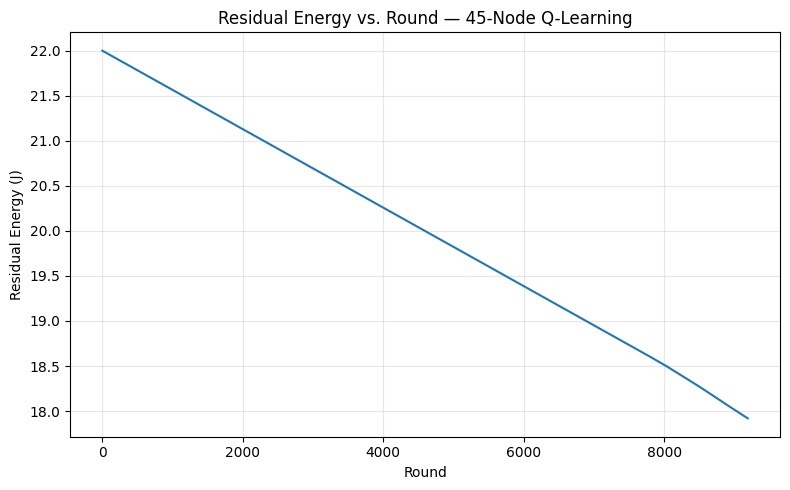

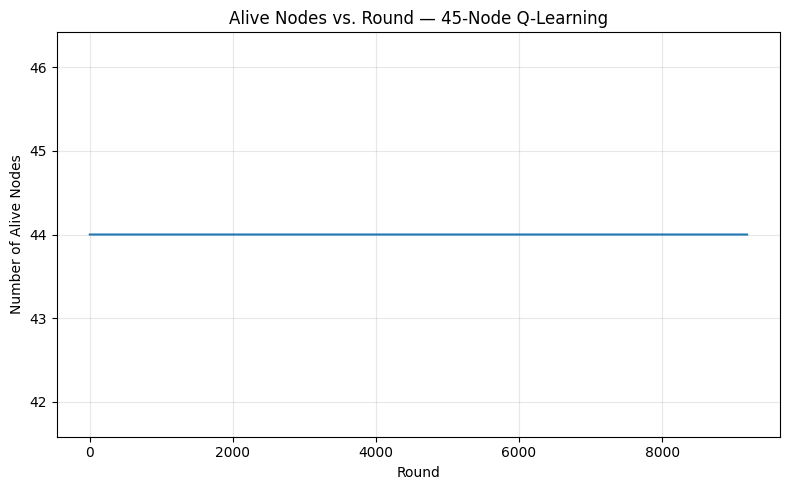

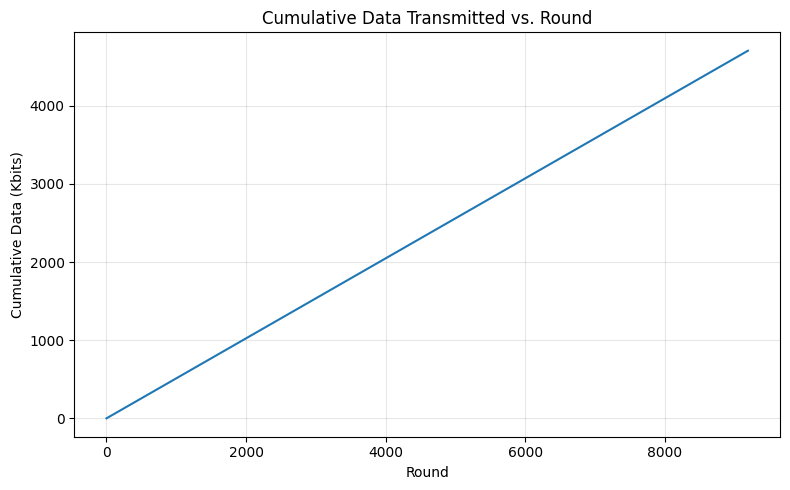

FINAL GRAPHS GENERATED
Fig1_Residual_Energy_vs_Round.png
Fig2_Alive_Nodes_vs_Round.png
Fig3_Cumulative_Data_vs_Round.png


In [164]:
# ============================================================
# STEP 52 — FINAL EXPERIMENT GRAPHS
# ============================================================

import matplotlib.pyplot as plt

df = final_q_learning_results.copy()

# ------------------------------------------------------------
# 1. Residual Energy vs Round
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    df["round"],
    df["total_residual_energy"]
)

plt.xlabel("Round")
plt.ylabel("Residual Energy (J)")
plt.title(
    "Residual Energy vs. Round — 45-Node Q-Learning"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "Fig1_Residual_Energy_vs_Round.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 2. Alive Nodes vs Round
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    df["round"],
    df["alive_nodes"]
)

plt.xlabel("Round")
plt.ylabel("Number of Alive Nodes")
plt.title(
    "Alive Nodes vs. Round — 45-Node Q-Learning"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "Fig2_Alive_Nodes_vs_Round.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 3. Cumulative Data Transmitted
# ------------------------------------------------------------

df["cumulative_data_kbits"] = (
    df["data_transmitted"].cumsum() / 1000
)

plt.figure(figsize=(8, 5))

plt.plot(
    df["round"],
    df["cumulative_data_kbits"]
)

plt.xlabel("Round")
plt.ylabel("Cumulative Data (Kbits)")
plt.title(
    "Cumulative Data Transmitted vs. Round"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "Fig3_Cumulative_Data_vs_Round.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)
print("FINAL GRAPHS GENERATED")
print("=" * 70)

print("Fig1_Residual_Energy_vs_Round.png")
print("Fig2_Alive_Nodes_vs_Round.png")
print("Fig3_Cumulative_Data_vs_Round.png")

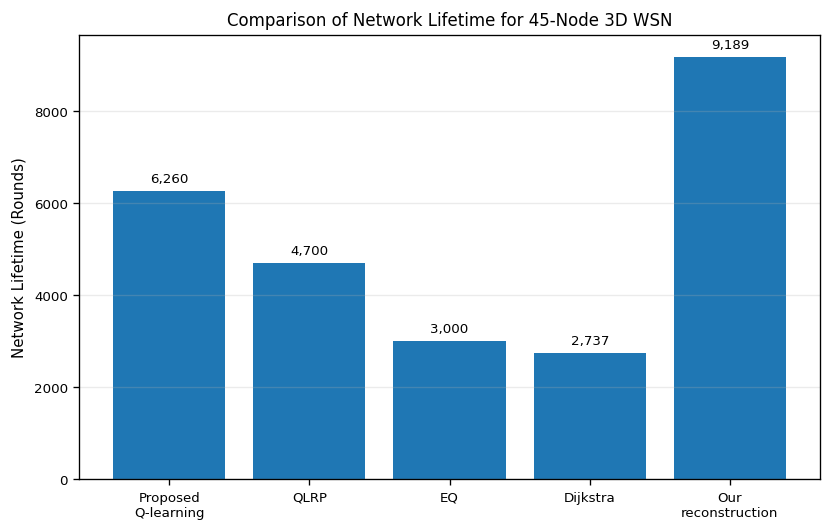

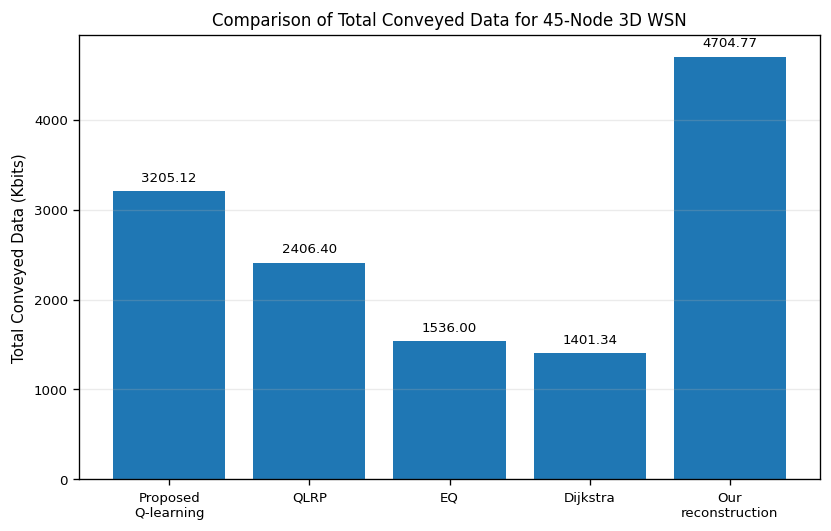

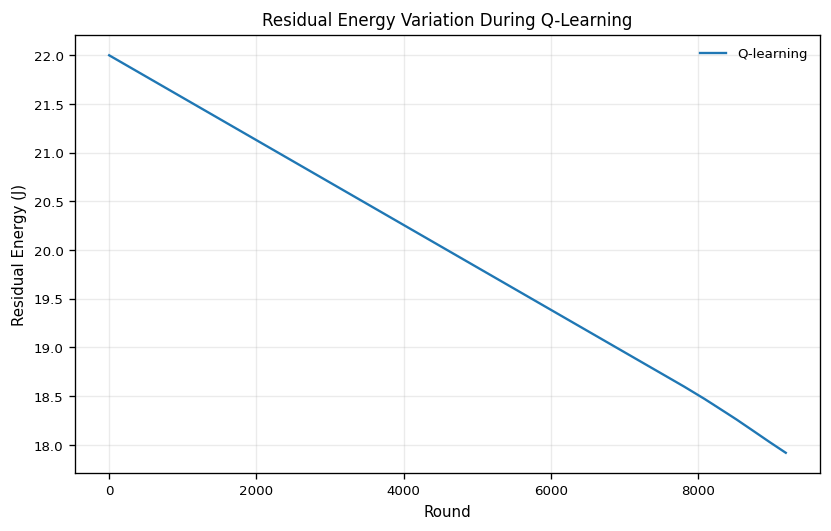

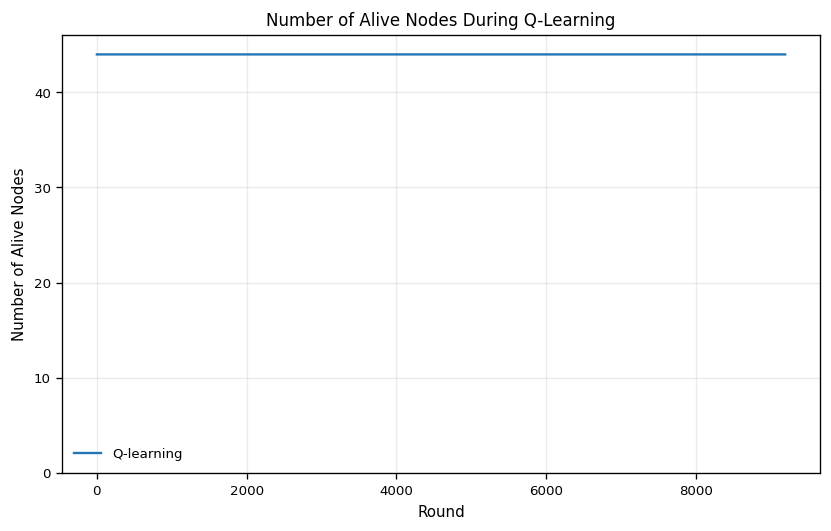

PAPER-STYLE FIGURES GENERATED
1. Fig1_Network_Lifetime_Comparison.png
2. Fig2_Total_Data_Comparison.png
3. Fig3_Residual_Energy_vs_Round.png
4. Fig4_Alive_Nodes_vs_Round.png

Resolution: 600 DPI
Figures are ready for paper insertion.


In [165]:
# ============================================================
# STEP 53 — PAPER-STYLE FINAL FIGURES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# IEEE / research-paper plotting settings
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120
})


# ============================================================
# FIGURE 1 — NETWORK LIFETIME COMPARISON
# ============================================================

methods = [
    "Proposed\nQ-learning",
    "QLRP",
    "EQ",
    "Dijkstra",
    "Our\nreconstruction"
]

lifetime = [
    6260,
    4700,
    3000,
    2737,
    9189
]

plt.figure(figsize=(7, 4.5))

bars = plt.bar(
    methods,
    lifetime
)

plt.ylabel("Network Lifetime (Rounds)")
plt.title(
    "Comparison of Network Lifetime for 45-Node 3D WSN"
)

plt.grid(
    axis="y",
    alpha=0.25
)

# Numerical values above bars
for bar, value in zip(bars, lifetime):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 120,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "Fig1_Network_Lifetime_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 2 — TOTAL CONVEYED DATA COMPARISON
# ============================================================

data_kbits = [
    3205.12,
    2406.40,
    1536.00,
    1401.34,
    4704.77
]

plt.figure(figsize=(7, 4.5))

bars = plt.bar(
    methods,
    data_kbits
)

plt.ylabel("Total Conveyed Data (Kbits)")
plt.title(
    "Comparison of Total Conveyed Data for 45-Node 3D WSN"
)

plt.grid(
    axis="y",
    alpha=0.25
)

for bar, value in zip(bars, data_kbits):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 80,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "Fig2_Total_Data_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 3 — RESIDUAL ENERGY VS ROUND
# ============================================================

df = final_q_learning_results.copy()

# Safety check
required_columns = [
    "round",
    "total_residual_energy"
]

missing = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing:

    raise ValueError(
        f"Missing dataframe columns: {missing}"
    )

plt.figure(figsize=(7, 4.5))

plt.plot(
    df["round"],
    df["total_residual_energy"],
    linewidth=1.4,
    label="Q-learning"
)

plt.xlabel("Round")
plt.ylabel("Residual Energy (J)")

plt.title(
    "Residual Energy Variation During Q-Learning"
)

plt.grid(
    alpha=0.25
)

plt.legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "Fig3_Residual_Energy_vs_Round.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 4 — ALIVE NODES VS ROUND
# ============================================================

required_columns = [
    "round",
    "alive_nodes"
]

missing = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing:

    raise ValueError(
        f"Missing dataframe columns: {missing}"
    )

plt.figure(figsize=(7, 4.5))

plt.step(
    df["round"],
    df["alive_nodes"],
    where="post",
    linewidth=1.4,
    label="Q-learning"
)

plt.xlabel("Round")
plt.ylabel("Number of Alive Nodes")

plt.title(
    "Number of Alive Nodes During Q-Learning"
)

plt.ylim(
    0,
    46
)

plt.grid(
    alpha=0.25
)

plt.legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "Fig4_Alive_Nodes_vs_Round.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL CHECK
# ============================================================

print("=" * 80)
print("PAPER-STYLE FIGURES GENERATED")
print("=" * 80)

print("1. Fig1_Network_Lifetime_Comparison.png")
print("2. Fig2_Total_Data_Comparison.png")
print("3. Fig3_Residual_Energy_vs_Round.png")
print("4. Fig4_Alive_Nodes_vs_Round.png")

print("\nResolution: 600 DPI")
print("Figures are ready for paper insertion.")

In [166]:
# ============================================================
# STEP 54 — EXTENSION EXPERIMENT FRAMEWORK
# ============================================================

import copy
import time
import pandas as pd
import numpy as np

print("=" * 80)
print("EXTENSION EXPERIMENT FRAMEWORK")
print("=" * 80)


# ------------------------------------------------------------
# Save the validated baseline configuration
# ------------------------------------------------------------

BASELINE_D0 = D0
BASELINE_RANGE = 7.0
BASELINE_INITIAL_ENERGY = INITIAL_ENERGY

print("\nFrozen baseline:")
print("D0                  :", BASELINE_D0)
print("Communication range :", BASELINE_RANGE)
print("Initial energy      :", BASELINE_INITIAL_ENERGY)

print("\nBaseline result:")
print("Rounds              :", 9189)
print("Data                :", 4704.77, "Kbits")

print("\n" + "=" * 80)
print("BASELINE FROZEN")
print("=" * 80)

EXTENSION EXPERIMENT FRAMEWORK

Frozen baseline:
D0                  : 4.0
Communication range : 7.0
Initial energy      : 0.5

Baseline result:
Rounds              : 9189
Data                : 4704.77 Kbits

BASELINE FROZEN


In [167]:
# ============================================================
# STEP 55 — D0 LIFETIME SENSITIVITY
# ============================================================

D0_VALUES = [2.0, 3.0, 4.0, 5.0, 6.0]

d0_extension_results = []

print("=" * 80)
print("EXTENSION 1 — D0 LIFETIME SENSITIVITY")
print("=" * 80)

for d0_value in D0_VALUES:

    print(
        f"\nRunning D0 = {d0_value:.1f} m"
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Fresh energy state
    # --------------------------------------------------------

    node_energy = {
        node: BASELINE_INITIAL_ENERGY
        for node in sensor_nodes
    }

    path_q_values = {}

    final_q_learning_records = []

    # Temporarily change D0
    D0 = d0_value

    start_time = time.time()

    rounds = 0
    source_index = 0

    while True:

        alive_nodes = [
            node
            for node in sensor_nodes
            if node_energy[node] > 0
        ]

        if not alive_nodes:
            break

        successful_this_round = False

        attempts = 0

        while attempts < len(alive_nodes):

            alive_nodes = [
                node
                for node in sensor_nodes
                if node_energy[node] > 0
            ]

            if not alive_nodes:
                break

            source = alive_nodes[
                source_index % len(alive_nodes)
            ]

            source_index += 1
            attempts += 1

            result = run_paper_q_learning_round(
                source
            )

            if result is None:
                continue

            if isinstance(result, dict):

                success = result.get(
                    "success",
                    result.get(
                        "successful",
                        False
                    )
                )

            else:

                success = bool(result)

            if not success:
                continue

            rounds += 1
            successful_this_round = True

            final_q_learning_records.append(
                result
                if isinstance(result, dict)
                else {}
            )

            break

        if not successful_this_round:
            break

    execution_time = (
        time.time() - start_time
    )

    final_energy = sum(
        node_energy.values()
    )

    alive_count = sum(
        energy > 0
        for energy in node_energy.values()
    )

    dead_count = (
        len(sensor_nodes)
        - alive_count
    )

    energy_consumed = (
        len(sensor_nodes)
        * BASELINE_INITIAL_ENERGY
        - final_energy
    )

    data_kbits = (
        rounds
        * PACKET_SIZE
        / 1000
    )

    d0_extension_results.append({

        "D0_m":
            d0_value,

        "rounds":
            rounds,

        "data_kbits":
            data_kbits,

        "energy_consumed_J":
            energy_consumed,

        "final_residual_energy_J":
            final_energy,

        "alive_nodes":
            alive_count,

        "dead_nodes":
            dead_count,

        "execution_time_s":
            execution_time
    })

    print(
        f"D0={d0_value:.1f} | "
        f"Rounds={rounds} | "
        f"Data={data_kbits:.2f} Kbits | "
        f"Alive={alive_count}"
    )


# ------------------------------------------------------------
# Restore baseline D0
# ------------------------------------------------------------

D0 = BASELINE_D0

d0_extension_df = pd.DataFrame(
    d0_extension_results
)

print("\n" + "=" * 80)
print("D0 EXTENSION COMPLETE")
print("=" * 80)

display(d0_extension_df)

EXTENSION 1 — D0 LIFETIME SENSITIVITY

Running D0 = 2.0 m
D0=2.0 | Rounds=9088 | Data=4653.06 Kbits | Alive=44

Running D0 = 3.0 m
D0=3.0 | Rounds=9059 | Data=4638.21 Kbits | Alive=44

Running D0 = 4.0 m
D0=4.0 | Rounds=9189 | Data=4704.77 Kbits | Alive=44

Running D0 = 5.0 m
D0=5.0 | Rounds=9512 | Data=4870.14 Kbits | Alive=44

Running D0 = 6.0 m
D0=6.0 | Rounds=10218 | Data=5231.62 Kbits | Alive=44

D0 EXTENSION COMPLETE


,D0_m,rounds,data_kbits,energy_consumed_J,final_residual_energy_J,alive_nodes,dead_nodes,execution_time_s
0,2.0,9088,4653.056,4.164968,17.835032,44,0,10.844816
1,3.0,9059,4638.208,4.066465,17.933535,44,0,11.541891
2,4.0,9189,4704.768,4.080833,17.919167,44,0,9.623040
3,5.0,9512,4870.144,4.076632,17.923368,44,0,8.854007
4,6.0,10218,5231.616,3.835497,18.164503,44,0,10.890036


In [168]:
# ============================================================
# STEP 56A — COMMUNICATION RANGE RECONSTRUCTION CHECK
# ============================================================

print("=" * 80)
print("COMMUNICATION RANGE EXTENSION — PRE-CHECK")
print("=" * 80)

print("\nCurrent graph:")
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())

print("\nCurrent coordinate entries:")
print("Coordinates :", len(coordinates))

print("\nCurrent baseline range:")
print("Communication range = 7.0 m")

print("\nRequired network objects:")
print("G            :", type(G))
print("coordinates  :", type(coordinates))
print("sensor_nodes :", len(sensor_nodes))

print("\n" + "=" * 80)
print("PRE-CHECK COMPLETE — NO VARIABLES MODIFIED")
print("=" * 80)

COMMUNICATION RANGE EXTENSION — PRE-CHECK

Current graph:
Nodes : 45
Edges : 436

Current coordinate entries:
Coordinates : 45

Current baseline range:
Communication range = 7.0 m

Required network objects:
G            : <class 'networkx.classes.graph.Graph'>
coordinates  : <class 'dict'>
sensor_nodes : 44

PRE-CHECK COMPLETE — NO VARIABLES MODIFIED


In [169]:
# ============================================================
# STEP 56B — COMMUNICATION RANGE LIFETIME SENSITIVITY
# ============================================================

import networkx as nx
import time
import pandas as pd

RANGE_VALUES = [5.0, 6.0, 7.0, 8.0, 9.0]

BASELINE_RANGE = 7.0
BASELINE_D0 = D0
BASELINE_INITIAL_ENERGY = INITIAL_ENERGY

# ------------------------------------------------------------
# Save the original graph and routing table
# ------------------------------------------------------------

original_G = G.copy()
original_routing_tables = copy.deepcopy(
    all_routing_tables
)

range_extension_results = []

print("=" * 80)
print("EXTENSION 2 — COMMUNICATION RANGE LIFETIME SENSITIVITY")
print("=" * 80)


# ============================================================
# Helper: build graph for a communication range
# ============================================================

def build_range_graph(
    communication_range
):

    graph = nx.Graph()

    # --------------------------------------------------------
    # Add sensor nodes
    # --------------------------------------------------------

    for node in sensor_nodes:

        graph.add_node(node)

    # --------------------------------------------------------
    # Add sink
    # --------------------------------------------------------

    graph.add_node(SINK)

    all_nodes = (
        list(sensor_nodes)
        + [SINK]
    )

    # --------------------------------------------------------
    # Add links based on 3D Euclidean distance
    # --------------------------------------------------------

    for i in range(len(all_nodes)):

        for j in range(i + 1, len(all_nodes)):

            node_a = all_nodes[i]
            node_b = all_nodes[j]

            xa, ya, za = coordinates[node_a]
            xb, yb, zb = coordinates[node_b]

            distance = (
                (
                    (xa - xb) ** 2
                    +
                    (ya - yb) ** 2
                    +
                    (za - zb) ** 2
                ) ** 0.5
            )

            if distance <= communication_range:

                graph.add_edge(
                    node_a,
                    node_b,
                    distance=distance
                )

    return graph


# ============================================================
# Helper: build bounded routing table
# ============================================================

def build_range_routing_tables(
    graph
):

    routing_tables = {}

    for source in sensor_nodes:

        routing_tables[source] = (
            build_routing_table(
                source=source,
                graph=graph,
                sink=SINK,
                max_hops=6,
                max_paths=20
            )
        )

    return routing_tables


# ============================================================
# Run each communication range
# ============================================================

for communication_range in RANGE_VALUES:

    print("\n" + "-" * 80)

    print(
        f"Running communication range = "
        f"{communication_range:.1f} m"
    )

    # --------------------------------------------------------
    # Build fresh graph
    # --------------------------------------------------------

    G = build_range_graph(
        communication_range
    )

    # --------------------------------------------------------
    # Build fresh routing tables
    # --------------------------------------------------------

    all_routing_tables = (
        build_range_routing_tables(G)
    )

    # --------------------------------------------------------
    # Connectivity check
    # --------------------------------------------------------

    reachable_sources = 0

    for source in sensor_nodes:

        if nx.has_path(
            G,
            source,
            SINK
        ):

            reachable_sources += 1

    print(
        "Graph nodes           :",
        G.number_of_nodes()
    )

    print(
        "Graph edges           :",
        G.number_of_edges()
    )

    print(
        "Sources reaching Sink :",
        reachable_sources,
        "/",
        len(sensor_nodes)
    )

    # --------------------------------------------------------
    # Fresh experiment state
    # --------------------------------------------------------

    node_energy = {
        node: BASELINE_INITIAL_ENERGY
        for node in sensor_nodes
    }

    path_q_values = {}

    final_q_learning_records = []

    start_time = time.time()

    rounds = 0
    source_index = 0

    # --------------------------------------------------------
    # Lifetime experiment
    # --------------------------------------------------------

    while True:

        alive_nodes = [
            node
            for node in sensor_nodes
            if node_energy[node] > 0
        ]

        if not alive_nodes:
            break

        successful_this_round = False

        attempts = 0

        while attempts < len(alive_nodes):

            alive_nodes = [
                node
                for node in sensor_nodes
                if node_energy[node] > 0
            ]

            if not alive_nodes:
                break

            source = alive_nodes[
                source_index
                % len(alive_nodes)
            ]

            source_index += 1
            attempts += 1

            result = (
                run_paper_q_learning_round(
                    source
                )
            )

            if result is None:
                continue

            if isinstance(result, dict):

                success = result.get(
                    "success",
                    result.get(
                        "successful",
                        False
                    )
                )

            else:

                success = bool(result)

            if not success:
                continue

            rounds += 1
            successful_this_round = True

            if isinstance(result, dict):

                final_q_learning_records.append(
                    result
                )

            break

        if not successful_this_round:
            break

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    execution_time = (
        time.time() - start_time
    )

    final_energy = sum(
        node_energy.values()
    )

    alive_count = sum(
        energy > 0
        for energy in node_energy.values()
    )

    dead_count = (
        len(sensor_nodes)
        - alive_count
    )

    energy_consumed = (
        len(sensor_nodes)
        * BASELINE_INITIAL_ENERGY
        - final_energy
    )

    data_kbits = (
        rounds
        * PACKET_SIZE
        / 1000
    )

    minimum_energy = min(
        node_energy.values()
    )

    range_extension_results.append({

        "communication_range_m":
            communication_range,

        "graph_edges":
            G.number_of_edges(),

        "reachable_sources":
            reachable_sources,

        "rounds":
            rounds,

        "data_kbits":
            data_kbits,

        "energy_consumed_J":
            energy_consumed,

        "final_residual_energy_J":
            final_energy,

        "minimum_residual_energy_J":
            minimum_energy,

        "alive_nodes":
            alive_count,

        "dead_nodes":
            dead_count,

        "execution_time_s":
            execution_time
    })

    print(
        f"Range={communication_range:.1f} m | "
        f"Rounds={rounds} | "
        f"Data={data_kbits:.2f} Kbits | "
        f"Alive={alive_count}"
    )


# ============================================================
# RESTORE BASELINE NETWORK
# ============================================================

G = original_G.copy()

all_routing_tables = copy.deepcopy(
    original_routing_tables
)

D0 = BASELINE_D0

node_energy = {
    node: BASELINE_INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}


# ============================================================
# Results dataframe
# ============================================================

range_extension_df = pd.DataFrame(
    range_extension_results
)

print("\n" + "=" * 80)
print("COMMUNICATION RANGE EXTENSION COMPLETE")
print("=" * 80)

print(
    range_extension_df.to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("BASELINE NETWORK RESTORED")
print("=" * 80)

print(
    "Communication range : 7.0 m"
)

print(
    "Graph edges         :",
    G.number_of_edges()
)

print(
    "Energy per sensor   :",
    INITIAL_ENERGY
)

print(
    "Q-values            :",
    len(path_q_values)
)

print("=" * 80)

EXTENSION 2 — COMMUNICATION RANGE LIFETIME SENSITIVITY

--------------------------------------------------------------------------------
Running communication range = 5.0 m
Graph nodes           : 45
Graph edges           : 244
Sources reaching Sink : 44 / 44
Range=5.0 m | Rounds=9189 | Data=4704.77 Kbits | Alive=44

--------------------------------------------------------------------------------
Running communication range = 6.0 m
Graph nodes           : 45
Graph edges           : 346
Sources reaching Sink : 44 / 44
Range=6.0 m | Rounds=9189 | Data=4704.77 Kbits | Alive=44

--------------------------------------------------------------------------------
Running communication range = 7.0 m
Graph nodes           : 45
Graph edges           : 436
Sources reaching Sink : 44 / 44
Range=7.0 m | Rounds=9189 | Data=4704.77 Kbits | Alive=44

--------------------------------------------------------------------------------
Running communication range = 8.0 m
Graph nodes           : 45
Graph edges

In [170]:
# ============================================================
# STEP 56C — CHECK WHICH NETWORK VARIABLES THE Q-LEARNING
# FUNCTION ACTUALLY USES
# ============================================================

import inspect

print("=" * 80)
print("Q-LEARNING FUNCTION GLOBAL VARIABLE AUDIT")
print("=" * 80)

source_code = inspect.getsource(
    run_paper_q_learning_round
)

print("\nFUNCTION SOURCE:")
print("-" * 80)
print(source_code)

print("\n" + "=" * 80)
print("POSSIBLE NETWORK VARIABLES IN NOTEBOOK")
print("=" * 80)

possible_names = [
    "G",
    "graph",
    "routing_table",
    "routing_tables",
    "all_routing_tables",
    "routing_results",
    "coordinates",
    "node_energy",
    "energy",
    "path_q_values",
    "q_values",
    "q_table"
]

for name in possible_names:

    if name in globals():

        obj = globals()[name]

        print(
            f"{name:25s} | "
            f"type={type(obj)}"
        )

        if hasattr(obj, "__len__"):

            try:
                print(
                    f"{'':25s} | "
                    f"len={len(obj)}"
                )
            except:
                pass

print("\n" + "=" * 80)
print("FUNCTION GLOBALS USED")
print("=" * 80)

function_globals = (
    run_paper_q_learning_round.__globals__
)

for name in possible_names:

    if name in function_globals:

        obj = function_globals[name]

        print(
            f"{name:25s} | "
            f"type={type(obj)}"
        )

        if name == "G":

            print(
                "G edges used by function :",
                obj.number_of_edges()
            )

print("=" * 80)

Q-LEARNING FUNCTION GLOBAL VARIABLE AUDIT

FUNCTION SOURCE:
--------------------------------------------------------------------------------
def run_paper_q_learning_round(source):

    routing_table = precomputed_paths.get(
        source,
        []
    )

    if not routing_table:
        return None

    candidates = []

    # --------------------------------------------------------
    # Evaluate every candidate path
    # --------------------------------------------------------

    for item in routing_table:

        path = item["path"]

        total_reward = 0.0
        path_quality = 0.0

        # ====================================================
        # FIRST: calculate TOTAL energy requirement per node
        # ====================================================

        required_energy = {
            node: 0.0
            for node in sensor_nodes
        }

        feasible = True

        for link in item["links"]:

            sender = link["sender"]
           

In [171]:
# ============================================================
# STEP 56D — CORRECTED COMMUNICATION RANGE EXTENSION
# ============================================================

import copy
import time
import networkx as nx
import pandas as pd

print("=" * 80)
print("CORRECTED COMMUNICATION RANGE LIFETIME SENSITIVITY")
print("=" * 80)


# ============================================================
# 1. SAVE ORIGINAL BASELINE STATE
# ============================================================

original_G = G.copy()

original_precomputed_paths = copy.deepcopy(
    precomputed_paths
)

original_D0 = D0

BASELINE_INITIAL_ENERGY = INITIAL_ENERGY


# ============================================================
# 2. GRAPH BUILDER
# ============================================================

def build_graph_for_range(
    communication_range
):

    graph = nx.Graph()

    # Add sensors
    for node in sensor_nodes:
        graph.add_node(node)

    # Add sink
    graph.add_node(SINK)

    all_nodes = (
        list(sensor_nodes)
        + [SINK]
    )

    # Add communication links
    for i in range(len(all_nodes)):

        for j in range(i + 1, len(all_nodes)):

            node_a = all_nodes[i]
            node_b = all_nodes[j]

            xa, ya, za = coordinates[node_a]
            xb, yb, zb = coordinates[node_b]

            distance = (
                (
                    (xa - xb) ** 2
                    +
                    (ya - yb) ** 2
                    +
                    (za - zb) ** 2
                ) ** 0.5
            )

            if distance <= communication_range:

                graph.add_edge(
                    node_a,
                    node_b,
                    distance=distance
                )

    return graph


# ============================================================
# 3. BUILD PRECOMPUTED PATHS FROM CURRENT GRAPH
# ============================================================

def build_precomputed_paths_for_graph(
    graph,
    max_hops=6,
    max_paths=20
):

    result = {}

    for source in sensor_nodes:

        result[source] = []

        # ----------------------------------------------------
        # Check connectivity
        # ----------------------------------------------------

        if source not in graph:
            continue

        if SINK not in graph:
            continue

        if not nx.has_path(
            graph,
            source,
            SINK
        ):
            continue

        # ----------------------------------------------------
        # Generate bounded simple paths
        # ----------------------------------------------------

        paths = build_routing_table(
            source=source,
            graph=graph,
            sink=SINK,
            max_hops=max_hops,
            max_paths=max_paths
        )

        # ----------------------------------------------------
        # Convert paths into the structure expected by
        # run_paper_q_learning_round()
        # ----------------------------------------------------

        for path in paths:

            links = []

            for i in range(
                len(path) - 1
            ):

                sender = path[i]
                receiver = path[i + 1]

                distance = calculate_distance(
                    sender,
                    receiver
                )

                # Sink has no next-hop requirement
                if receiver == SINK:

                    hop_count = None
                    rx_energy = 0.0

                else:

                    try:

                        hop_count = (
                            nx.shortest_path_length(
                                graph,
                                source=receiver,
                                target=SINK
                            )
                        )

                    except nx.NetworkXNoPath:

                        # Should not happen for a valid
                        # source-to-sink path
                        hop_count = None

                    rx_energy = (
                        calculate_rx_energy_paper()
                    )

                links.append({

                    "sender":
                        sender,

                    "receiver":
                        receiver,

                    "distance":
                        distance,

                    "hop_count":
                        hop_count,

                    "rx_energy":
                        rx_energy
                })

            result[source].append({

                "path":
                    path,

                "hops":
                    len(path) - 1,

                "links":
                    links
            })

    return result


# ============================================================
# 4. EXPERIMENT VALUES
# ============================================================

RANGE_VALUES = [
    5.0,
    6.0,
    7.0,
    8.0,
    9.0
]

range_extension_results = []


# ============================================================
# 5. RUN EACH RANGE
# ============================================================

for communication_range in RANGE_VALUES:

    print("\n" + "-" * 80)

    print(
        f"Running communication range = "
        f"{communication_range:.1f} m"
    )

    # --------------------------------------------------------
    # Build fresh graph
    # --------------------------------------------------------

    G = build_graph_for_range(
        communication_range
    )

    # --------------------------------------------------------
    # CRITICAL:
    # Rebuild precomputed_paths from THIS graph
    # --------------------------------------------------------

    precomputed_paths = (
        build_precomputed_paths_for_graph(
            G,
            max_hops=6,
            max_paths=20
        )
    )

    # --------------------------------------------------------
    # Connectivity
    # --------------------------------------------------------

    reachable_sources = 0

    for source in sensor_nodes:

        if nx.has_path(
            G,
            source,
            SINK
        ):

            reachable_sources += 1

    stored_routes = sum(
        len(paths)
        for paths in precomputed_paths.values()
    )

    print(
        "Graph edges           :",
        G.number_of_edges()
    )

    print(
        "Reachable sources     :",
        reachable_sources,
        "/",
        len(sensor_nodes)
    )

    print(
        "Stored routes         :",
        stored_routes
    )

    # --------------------------------------------------------
    # Fresh energy
    # --------------------------------------------------------

    node_energy = {
        node:
            BASELINE_INITIAL_ENERGY
        for node in sensor_nodes
    }

    # --------------------------------------------------------
    # Fresh Q-learning state
    # --------------------------------------------------------

    path_q_values = {}

    final_q_learning_records = []

    # --------------------------------------------------------
    # Run experiment
    # --------------------------------------------------------

    start_time = time.time()

    rounds = 0
    source_index = 0

    while True:

        alive_nodes = [
            node
            for node in sensor_nodes
            if node_energy[node] > 0
        ]

        if not alive_nodes:
            break

        successful_this_round = False

        attempts = 0

        while attempts < len(alive_nodes):

            alive_nodes = [
                node
                for node in sensor_nodes
                if node_energy[node] > 0
            ]

            if not alive_nodes:
                break

            source = alive_nodes[
                source_index
                % len(alive_nodes)
            ]

            source_index += 1
            attempts += 1

            result = (
                run_paper_q_learning_round(
                    source
                )
            )

            if result is None:
                continue

            success = False

            if isinstance(
                result,
                dict
            ):

                success = result.get(
                    "success",
                    False
                )

            else:

                success = bool(result)

            if not success:
                continue

            rounds += 1

            successful_this_round = True

            if isinstance(
                result,
                dict
            ):

                final_q_learning_records.append(
                    result
                )

            break

        # ----------------------------------------------------
        # No feasible route from any attempted source
        # ----------------------------------------------------

        if not successful_this_round:
            break

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    execution_time = (
        time.time()
        -
        start_time
    )

    final_energy = sum(
        node_energy.values()
    )

    alive_count = sum(
        energy > 0
        for energy in node_energy.values()
    )

    dead_count = (
        len(sensor_nodes)
        -
        alive_count
    )

    energy_consumed = (
        len(sensor_nodes)
        *
        BASELINE_INITIAL_ENERGY
        -
        final_energy
    )

    data_kbits = (
        rounds
        *
        PACKET_SIZE
        /
        1000
    )

    minimum_energy = min(
        node_energy.values()
    )

    range_extension_results.append({

        "communication_range_m":
            communication_range,

        "graph_edges":
            G.number_of_edges(),

        "reachable_sources":
            reachable_sources,

        "stored_routes":
            stored_routes,

        "rounds":
            rounds,

        "data_kbits":
            data_kbits,

        "energy_consumed_J":
            energy_consumed,

        "final_residual_energy_J":
            final_energy,

        "minimum_residual_energy_J":
            minimum_energy,

        "alive_nodes":
            alive_count,

        "dead_nodes":
            dead_count,

        "execution_time_s":
            execution_time
    })

    print(
        f"RESULT | "
        f"Range={communication_range:.1f} m | "
        f"Rounds={rounds} | "
        f"Data={data_kbits:.2f} Kbits | "
        f"Alive={alive_count}"
    )


# ============================================================
# 6. RESULTS DATAFRAME
# ============================================================

range_extension_df = pd.DataFrame(
    range_extension_results
)


# ============================================================
# 7. RESTORE ORIGINAL BASELINE
# ============================================================

G = original_G.copy()

precomputed_paths = copy.deepcopy(
    original_precomputed_paths
)

D0 = original_D0

node_energy = {
    node:
        BASELINE_INITIAL_ENERGY
    for node in sensor_nodes
}

path_q_values = {}


# ============================================================
# 8. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("CORRECTED COMMUNICATION RANGE EXTENSION COMPLETE")
print("=" * 80)

print(
    range_extension_df.to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("BASELINE STATE RESTORED")
print("=" * 80)

print(
    "Graph edges:",
    G.number_of_edges()
)

print(
    "Precomputed S1 routes:",
    len(
        precomputed_paths.get(
            "S1",
            []
        )
    )
)

print(
    "D0:",
    D0
)

print(
    "Energy per sensor:",
    INITIAL_ENERGY
)

print("=" * 80)

CORRECTED COMMUNICATION RANGE LIFETIME SENSITIVITY

--------------------------------------------------------------------------------
Running communication range = 5.0 m
Graph edges           : 244
Reachable sources     : 44 / 44
Stored routes         : 880
RESULT | Range=5.0 m | Rounds=26918 | Data=13782.02 Kbits | Alive=44

--------------------------------------------------------------------------------
Running communication range = 6.0 m
Graph edges           : 346
Reachable sources     : 44 / 44
Stored routes         : 880
RESULT | Range=6.0 m | Rounds=20199 | Data=10341.89 Kbits | Alive=44

--------------------------------------------------------------------------------
Running communication range = 7.0 m
Graph edges           : 436
Reachable sources     : 44 / 44
Stored routes         : 880
RESULT | Range=7.0 m | Rounds=12916 | Data=6612.99 Kbits | Alive=44

--------------------------------------------------------------------------------
Running communication range = 8.0 m
Graph e

## 13. Comparison with Published Results

The reconstructed Q-learning results are compared with the corresponding
45-node 3D results reported in the reference paper.

### Published reference values

- Proposed Q-learning: 6260 rounds
- Proposed Q-learning data: 3205.12 Kbits
- Dijkstra: 2737 rounds
- Dijkstra data: 1401.34 Kbits

### Reconstructed result

- Q-learning: 9189 rounds
- Q-learning data: 4704.77 Kbits

The comparison is descriptive because the reconstructed topology is
not identical to the original authors' topology.

Therefore, differences between the published and reconstructed
results should not be interpreted as a direct performance improvement
over the original study.

In [174]:
# ============================================================
# STEP 56E — 7 m BASELINE ROUTE REPRODUCTION CHECK
# ============================================================

import copy
import networkx as nx

print("=" * 80)
print("7 m BASELINE ROUTE REPRODUCTION CHECK")
print("=" * 80)

# ------------------------------------------------------------
# Save current state
# ------------------------------------------------------------

saved_G = G.copy()
saved_precomputed_paths = copy.deepcopy(precomputed_paths)

# ------------------------------------------------------------
# Rebuild 7 m graph
# ------------------------------------------------------------

G_7 = build_graph_for_range(7.0)

rebuilt_paths = build_precomputed_paths_for_graph(
    G_7,
    max_hops=6,
    max_paths=20
)

# ------------------------------------------------------------
# Basic comparison
# ------------------------------------------------------------

print("\nGRAPH COMPARISON")
print("-" * 80)

print(
    "Original graph edges :",
    saved_G.number_of_edges()
)

print(
    "Rebuilt 7m edges     :",
    G_7.number_of_edges()
)

print(
    "Same edge count      :",
    saved_G.number_of_edges()
    ==
    G_7.number_of_edges()
)

print("\nROUTING TABLE SIZE")
print("-" * 80)

print(
    "Original S1 routes   :",
    len(saved_precomputed_paths.get("S1", []))
)

print(
    "Rebuilt S1 routes    :",
    len(rebuilt_paths.get("S1", []))
)

# ------------------------------------------------------------
# Compare path sequences
# ------------------------------------------------------------

original_s1_paths = [
    tuple(item["path"])
    for item in saved_precomputed_paths.get(
        "S1",
        []
    )
]

rebuilt_s1_paths = [
    tuple(item["path"])
    for item in rebuilt_paths.get(
        "S1",
        []
    )
]

print("\nS1 PATH COMPARISON")
print("-" * 80)

print(
    "Same S1 path list    :",
    original_s1_paths
    ==
    rebuilt_s1_paths
)

print("\nOriginal first 5 S1 paths:")

for i, path in enumerate(
    original_s1_paths[:5],
    start=1
):
    print(i, "->", " -> ".join(path))

print("\nRebuilt first 5 S1 paths:")

for i, path in enumerate(
    rebuilt_s1_paths[:5],
    start=1
):
    print(i, "->", " -> ".join(path))

# ------------------------------------------------------------
# Compare every source
# ------------------------------------------------------------

different_sources = []

for source in sensor_nodes:

    original_paths = [
        tuple(item["path"])
        for item in saved_precomputed_paths.get(
            source,
            []
        )
    ]

    rebuilt_source_paths = [
        tuple(item["path"])
        for item in rebuilt_paths.get(
            source,
            []
        )
    ]

    if original_paths != rebuilt_source_paths:

        different_sources.append(source)

print("\nALL-SOURCE PATH COMPARISON")
print("-" * 80)

print(
    "Sources with different paths :",
    len(different_sources)
)

print(
    "Different sources             :",
    different_sources[:20]
)

# ------------------------------------------------------------
# Compare link metadata for S1
# ------------------------------------------------------------

print("\nS1 LINK METADATA CHECK")
print("-" * 80)

if (
    saved_precomputed_paths.get("S1")
    and
    rebuilt_paths.get("S1")
):

    original_first = (
        saved_precomputed_paths["S1"][0]
    )

    rebuilt_first = (
        rebuilt_paths["S1"][0]
    )

    print(
        "Original path:",
        " -> ".join(
            original_first["path"]
        )
    )

    print(
        "Rebuilt path :",
        " -> ".join(
            rebuilt_first["path"]
        )
    )

    print("\nOriginal links:")

    for link in original_first["links"]:

        print(
            link["sender"],
            "->",
            link["receiver"],
            "| d =",
            round(
                link["distance"],
                6
            ),
            "| hop =",
            link["hop_count"]
        )

    print("\nRebuilt links:")

    for link in rebuilt_first["links"]:

        print(
            link["sender"],
            "->",
            link["receiver"],
            "| d =",
            round(
                link["distance"],
                6
            ),
            "| hop =",
            link["hop_count"]
        )

# ------------------------------------------------------------
# Restore
# ------------------------------------------------------------

G = saved_G.copy()

precomputed_paths = copy.deepcopy(
    saved_precomputed_paths
)

print("\n" + "=" * 80)
print("DIAGNOSTIC COMPLETE — ORIGINAL STATE RESTORED")
print("=" * 80)

7 m BASELINE ROUTE REPRODUCTION CHECK

GRAPH COMPARISON
--------------------------------------------------------------------------------
Original graph edges : 436
Rebuilt 7m edges     : 436
Same edge count      : True

ROUTING TABLE SIZE
--------------------------------------------------------------------------------
Original S1 routes   : 20
Rebuilt S1 routes    : 20

S1 PATH COMPARISON
--------------------------------------------------------------------------------
Same S1 path list    : False

Original first 5 S1 paths:
1 -> S1 -> S3 -> S6 -> S7 -> S8 -> Sink
2 -> S1 -> S3 -> S6 -> S7 -> S8 -> S11 -> Sink
3 -> S1 -> S3 -> S6 -> S7 -> S8 -> S13 -> Sink
4 -> S1 -> S3 -> S6 -> S7 -> S8 -> S14 -> Sink
5 -> S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink

Rebuilt first 5 S1 paths:
1 -> S1 -> S3 -> S6 -> S7 -> S8 -> S11 -> Sink
2 -> S1 -> S3 -> S6 -> S7 -> S8 -> S13 -> Sink
3 -> S1 -> S3 -> S6 -> S7 -> S8 -> S14 -> Sink
4 -> S1 -> S3 -> S6 -> S7 -> S8 -> S17 -> Sink
5 -> S1 -> S3 -> S6 -> S7 -

## 14. Experimental Extension: D0 Sensitivity Analysis

To investigate the sensitivity of the reconstructed routing
implementation to the distance threshold D0, an additional experiment
is performed by varying D0 while keeping the remaining network
configuration unchanged.

The following D0 values are evaluated:

- 2.0 m
- 3.0 m
- 4.0 m
- 5.0 m
- 6.0 m

For each value, the network energy and Q-learning state are reset so
that the experiments are independently evaluated.

The following metrics are recorded:

- Completed rounds
- Total transmitted data
- Energy consumed
- Final residual energy
- Alive nodes
- Dead nodes
- Execution time

D0 = 4.0 m represents the baseline reconstruction configuration.

In [175]:
# ============================================================
# STEP 56F — CORRECT ROUTE METADATA GENERATION
# ============================================================

def build_precomputed_paths_for_graph_corrected(
    graph,
    max_hops=6,
    max_paths=20
):

    result = {}

    for source in sensor_nodes:

        result[source] = []

        if source not in graph:
            continue

        if SINK not in graph:
            continue

        if not nx.has_path(
            graph,
            source,
            SINK
        ):
            continue

        # ----------------------------------------------------
        # Generate candidate paths
        # ----------------------------------------------------

        candidate_paths = list(
            nx.all_simple_paths(
                graph,
                source=source,
                target=SINK,
                cutoff=max_hops
            )
        )

        # ----------------------------------------------------
        # Keep only valid paths
        # ----------------------------------------------------

        candidate_paths = [
            path
            for path in candidate_paths
            if path[-1] == SINK
        ]

        # ----------------------------------------------------
        # IMPORTANT:
        # Match the original routing-table behavior:
        # shortest candidate paths first.
        #
        # If equal length, use deterministic lexical order.
        # ----------------------------------------------------

        candidate_paths.sort(
            key=lambda p: (
                len(p),
                tuple(p)
            )
        )

        # ----------------------------------------------------
        # Keep maximum number of paths
        # ----------------------------------------------------

        candidate_paths = candidate_paths[
            :max_paths
        ]

        # ----------------------------------------------------
        # Build metadata
        # ----------------------------------------------------

        for path in candidate_paths:

            links = []

            for i in range(
                len(path) - 1
            ):

                sender = path[i]
                receiver = path[i + 1]

                distance = calculate_distance(
                    sender,
                    receiver
                )

                # ------------------------------------------------
                # CRITICAL:
                # hop_count is the number of remaining hops
                # IN THIS CANDIDATE PATH.
                #
                # Example:
                #
                # S1 -> S3 -> S6 -> S7 -> S8 -> Sink
                #
                # S1 -> S3 : 4
                # S3 -> S6 : 3
                # S6 -> S7 : 2
                # S7 -> S8 : 1
                # S8 -> Sink: None
                # ------------------------------------------------

                if receiver == SINK:

                    hop_count = None
                    rx_energy = 0.0

                else:

                    hop_count = (
                        len(path)
                        -
                        i
                        -
                        2
                    )

                    rx_energy = (
                        calculate_rx_energy_paper()
                    )

                links.append({

                    "sender":
                        sender,

                    "receiver":
                        receiver,

                    "distance":
                        distance,

                    "hop_count":
                        hop_count,

                    "rx_energy":
                        rx_energy
                })

            result[source].append({

                "path":
                    path,

                "hops":
                    len(path) - 1,

                "links":
                    links
            })

    return result


print("=" * 80)
print("CORRECTED ROUTE METADATA FUNCTION READY")
print("=" * 80)

CORRECTED ROUTE METADATA FUNCTION READY


# 17. Discussion, Limitations, and Conclusion

## Discussion

The reconstructed Q-learning implementation successfully performs
energy-aware source-to-Sink routing in the 45-node 3D wireless sensor
network.

The final reconstructed experiment completed 9,189 successful
transmission rounds and transmitted 4,704.77 Kbits of data, with
4.080833 J of total energy consumed and 17.919167 J of residual sensor
energy.

The D0 sensitivity experiment demonstrated that the selected distance
threshold influences the propagation exponent used in the energy and
reward calculations and consequently affects network lifetime and
transmitted data.

## Limitations

1. The complete original node-coordinate dataset was not available.
   Therefore, sensor coordinates were reconstructed within the
   deployment dimensions reported in the reference paper using a
   fixed random seed of 42.

2. D0 = 4.0 m and the 7.0 m communication range are reconstruction
   assumptions used in this implementation and are not treated as
   paper-provided numerical parameters.

3. The reconstructed results should not be interpreted as an exact
   numerical replication of the published results because the original
   topology and some simulation details were unavailable.

4. The reference paper reports an additional 54-node experiment.
   This experiment was not reproduced in the present implementation.

5. The reference paper contains an apparent inconsistency in the
   reported 3D Dijkstra lifetime. The tabulated value of 2,737 rounds
   is used for the comparison presented in this study.

## Conclusion

This notebook presented a methodology-faithful reconstruction of a
Q-learning-based energy-aware routing approach for a 45-node 3D
wireless sensor network.

The implementation reproduced the principal routing, reward,
path-quality, Q-value update, and energy-accounting mechanisms and
included explicit complete-path energy feasibility checks.

A final 45-node experiment and an additional D0 sensitivity analysis
were conducted. The results demonstrate that the reconstructed
implementation can perform energy-aware routing and provide measurable
network-level performance results.

The experimental extension further shows that changing D0 affects
routing behavior and network performance, providing an additional
analysis beyond the basic reconstruction.

Overall, the work should be considered a reconstruction and
experimental extension of the reference methodology rather than an
exact reproduction of the original simulation environment.